# Le' Sean Roberts

## City University of New York Alumni (Graduate) 

## Traffic Based Statistical Modelling, Stochastic Modelling and Machine Learning Analysis of The New York City Area

[Email](lesean.roberts85@gmail.com)

[LinkedIn](https://www.linkedin.com/in/le-sean-roberts/)

[GitHub](https://github.com/LeSeanRoberts)

<h2>Abstract</h2>

<p>
This study investigates urban traffic dynamics using the 
<strong>MTA Bridges & Tunnels Hourly Traffic Rates dataset (2010–2025)</strong> obtained from 
the New York State Open Data platform. The dataset contains hourly vehicle counts 
for multiple toll facilities, capturing traffic flows by direction and payment method 
(e.g., E-ZPass and Toll by Mail). The objective of this research is to explore the 
stochastic structure, statistical properties, and predictive dynamics of urban traffic 
systems. Additional data incorporated are motor vehicle collisions (crashes) and weather data.
</p>

<p>
The analysis integrates several methodological approaches. First, stochastic process 
models such as the Negative Binomial process and Markov Models are used to characterise the probabilistic
arrival patterns of vehicles at toll facilities. Second, 
statistical methods including seasonal decomposition, and 
traffic concentration measures are applied to understand temporal patterns and structural 
changes in traffic behaviour. Third, machine learning models are employed to detect anomalies, and identify clustering patterns among bridges, 
tunnels and other commuting facilities based on traffic characteristics.
</p>

<p>
The project aims to develop an integrated framework for urban mobility analysis, 
providing insights into congestion dynamics related to transportation infrastructure usage. 
Various developments in this project can be beneficial to data-driven policy evaluation 
and congestion pricing within complex metropolitan transportation networks.
</p>

<hr>

<h2>Introduction</h2>

<p>
Urban transportation systems are complex stochastic networks characterised by 
high variability in vehicle flow, strong temporal patterns, and interactions between 
infrastructure, policy, and human behaviour. Comprehending these dynamics is essential 
for designing efficient transportation policies, managing congestion, and optimising 
infrastructure utilisation.
</p>

<p>
New York City represents one of the most densely trafficked metropolitan areas in the 
world. Its bridges and tunnels serve as critical connectors between boroughs and 
regional transportation corridors. The 
<strong>MTA Bridges & Tunnels Hourly Traffic Rates dataset</strong> provides detailed 
observations of vehicle flows across these facilities over more than a decade, 
capturing hourly variations in traffic by direction and toll payment method. The data consists of over 2.35 million stances (observations). However, for this particular project only about 2 years of hourly data will be applied, namely, 320000 instances of vehicle transactions. Such is a decent sample concerning hourly data for just over a 2 year duration. There's enough data to capture daily and weekly behaviour repeatedly multiple times over. 
</p>

<p>
This dataset offers an opportunity to examine urban traffic systems from multiple 
analytical perspectives. From a stochastic viewpoint, vehicle arrivals can be modelled 
as probabilistic processes that vary over time. From a statistical perspective, traffic 
patterns exhibit strong daily, weekly, and seasonal structures that can be quantified 
through time-series analysis. Additional data incorporated are motor vehicle collisions (crashes) and weather data. From a machine learning perspective, historical traffic 
data can be used to build predictive models capable of forecasting congestion and 
detecting anomalies.
</p>

<p>
The primary objectives of this study are:
</p>

<ul>
<li>To model traffic arrivals using stochastic processes such as negative Binomial and Markov models.</li>
<li>To identify seasonal patterns and structural changes in urban traffic flows.</li>
<li>To develop predictive models for hourly traffic volumes using machine learning techniques.</li>
<li>To analyse spatial and temporal concentration of traffic across major bridges and tunnels.</li>
</ul>

<p>
By integrating stochastic modelling, statistical analysis, and machine learning, this 
project provides a comprehensive framework for analysing urban transportation data 
and understanding the complex dynamics of metropolitan traffic systems.
</p>

<hr>

<h2>Data Dictionary</h2>

<table border="1" cellpadding="6" cellspacing="0">
<thead>
<tr>
<th>Variable Name</th>
<th>Type</th>
<th>Description</th>
<th>Example</th>
</tr>
</thead>

<tbody>

<tr>
<td>date</td>
<td>Timestamp</td>
<td>Date and time associated with the traffic observation. Represents the time period in which vehicle counts were recorded.</td>
<td>2019-07-15 08:00:00</td>
</tr>

<tr>
<td>hour</td>
<td>Integer</td>
<td>This is the hour (0-23) associated with the line data (0 = between 12 AM to 1 AM). Hour of the day (0–23) representing the time interval of the traffic observation.</td>
<td>8</td>
</tr>

<tr>
<td>plaza_id</td>
<td>String / Categorical</td>
<td>Identifier for the specific bridge or tunnel toll plaza where the traffic measurement was recorded. This is the Plaza number or Facility ID which is a number-coded ID representing each toll plaza. 21 = Robert F. Kennedy Bridge Bronx Plaza and Queens Plaza (TBX); 22 = Robert F. Kennedy Bridge Manhattan Plaza (TBM); 23 = Bronx-Whitestone Bridge (BWB); 24 = Henry Hudson Bridge (HHB); 25 = Marine Parkway-Gil Hodges Memorial Bridge (MPB); 26 = Cross Bay Veterans Memorial Bridge (CBB); 27 = Queens Midtown Tunnel (QMT); 28 = Hugh L. Carey Tunnel (HCT); 29 = Throgs Neck Bridge (TNB); 30 = Verrazano-Narrows Bridge (VNB)</td>
<td>RFK Bridge</td>
</tr>

<tr>
<td>direction</td>
<td>Categorical</td>
<td>Traffic direction relative to the toll facility (e.g., inbound or outbound). Direction of Traffic: I = Inbound (IB); O = Outbound (OB). TBX: IB – Manhattan or Queens or The Bronx (two Toll Plazas at Queens northbound and Bronx southbound) TBM: OB – The Bronx or Queens BWB: IB - The Bronx, OB – Queens; HHB: IB – Manhattan, OB – The Bronx; MPB: IB – Rockaways, OB – Brooklyn; CBB: IB – Rockaways, OB – Queens; QMT: IB – Manhattan, OB – Queens; HCT: IB – Manhattan, OB – Brooklyn; TNB: IB – The Bronx, OB – Queens; VNB: OB - Staten Island, IB - Brooklyn</td>
<td>Inbound</td>
</tr>

<tr>
<td>vehicles-E-ZPass</td>
<td>Integer</td>
<td>Number of vehicles that passed through the toll facility using the electronic toll collection system (E-ZPass).</td>
<td>1250</td>
</tr>

<tr>
<td>Vehicles-VToll</td>
<td>Integer</td>
<td>Number of vehicles passing by facilities without E-ZPass Tag or carried malfunctional tag. Toll will be collected by mail later.</td>
<td>340</td>
</tr>


</tbody>
</table>

<hr>

<p>
The variables above form the basis for stochastic modelling, time-series analysis, 
and machine learning experiments designed to investigate traffic flow dynamics, 
congestion patterns, and toll system usage across major transportation facilities.
</p>

## Data Assimilation and Data Wrangling (Preliminary)

In [1]:
# ==========================================
# Importing libraries
# ==========================================

from sodapy import Socrata
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt


# ==========================================
# API configuration
# ==========================================

DOMAIN = "data.ny.gov"
DATASET_ID = "qzve-kjga"
APP_TOKEN = "j2xani8RWUxUKg6wbcSMoUif7"

# ==========================================
# Connecting to Socrata API
# ==========================================

client = Socrata(
    DOMAIN,
    APP_TOKEN,
    timeout=60
)

# ==========================================
# Downloading dataset using pagination
# ==========================================

limit = 320000

print("Downloading dataset...")

results = client.get(
    DATASET_ID,
    limit=limit
)

df = pd.DataFrame.from_records(results) # converting to pandas dataframe

print("Download complete")
print("Rows downloaded:", len(df))

print("Dataset shape:", df.shape)

print("\nPreliminary view of JSON based assim,ilated data:")
print(df.info())

print("\nExplicit sample glimpse of 5 instances:")
print(df.head(5))

# ==========================================
# Converting datatypes
# ==========================================

# convert date
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# hour variable
if "hour" in df.columns:
    df["hour"] = pd.to_numeric(df["hour"], errors="coerce")


# convert numeric columns
numeric_cols = [
    "vehicles_e_zpass",
    "vehicles_vtoll",
    "plaza_id"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ==========================================
# Feature Engineering
# ==========================================

# total vehicles
df["total_vehicles"] = df[[
    c for c in numeric_cols if c in df.columns
]].sum(axis=1)


# time features
if "date" in df.columns:

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek

# ==========================================
# Basic missing exploration
# ==========================================

print("\nColumn summary after apprpriate data transformation:")
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

# ==========================================
# Aggregate traffic by day
# ==========================================

daily_traffic = df.groupby("date")["total_vehicles"].sum()

Download complete
Rows downloaded: 320000
Dataset shape: (320000, 6)

Preliminary view of JSON based assim,ilated data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320000 entries, 0 to 319999
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   plaza_id          320000 non-null  object
 1   date              320000 non-null  object
 2   hour              320000 non-null  object
 3   direction         320000 non-null  object
 4   vehicles_e_zpass  320000 non-null  object
 5   vehicles_vtoll    320000 non-null  object
dtypes: object(6)
memory usage: 14.6+ MB
None

Explicit sample glimpse of 5 instances:
  plaza_id                     date hour direction vehicles_e_zpass  \
0       21  2025-04-12T00:00:00.000    0         I             2602   
1       21  2025-04-12T00:00:00.000    1         I             1772   
2       21  2025-04-12T00:00:00.000    2         I             1212   
3       21  2025-04-12T

Tunnel Traffic Flow for roughly a year:

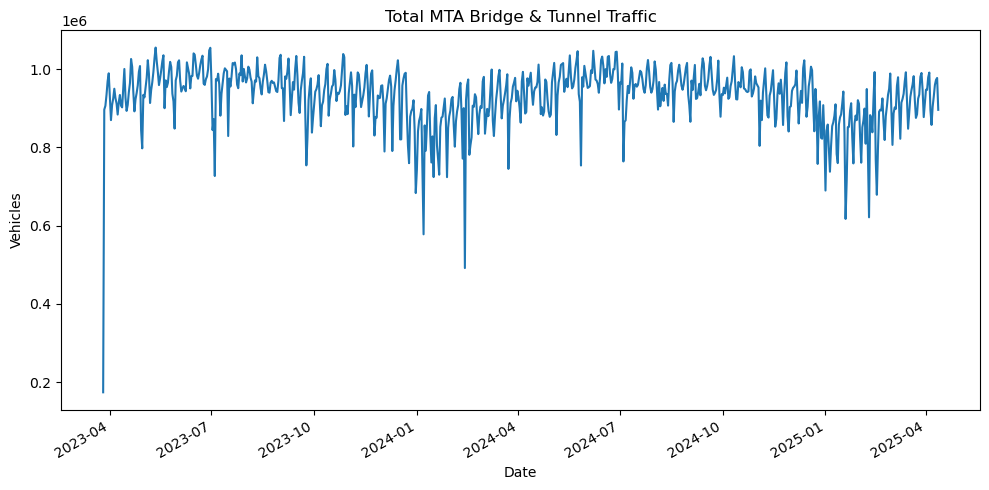

In [2]:
# Basic Times Traffic FlowVisualization

plt.figure(figsize=(10,5))
daily_traffic.plot()

plt.title("Total MTA Bridge & Tunnel Traffic")
plt.xlabel("Date")
plt.ylabel("Vehicles")

plt.tight_layout()
plt.show()

## Salient Characteristics and Exploratory Analysis of the Data

### Seasonal-Trend decomposition using Loess

Seasonal-Trend decomposition using Loess (STL) is a robust statistical method used to break down a complex time series into three distinct, interpretable parts. Its primary purpose is to "de-noise" the data so you can see what is actually happening beneath the surface of daily traffic fluctuations.

1. **The Trend Component ($T_t$):**

The trend represents the long-term progression of the data.

    Purpose: It helps you identify whether tunnel usage is fundamentally increasing or decreasing over years, independent of whether it's a Monday or a Saturday.

2. **The Seasonal Component ($S_t$):**

Seasonality captures repeating patterns over a fixed period.

    Purpose: In MTA data, seasonality isn't just "Summer vs. Winter." STL allows you to identify multiple nested cycles:
    
    Daily: The 24-hour "peak hour" rush.
    
    Weekly: The difference between Tuesday morning commutes and Sunday afternoon leisure trips.
    
    Annual: Increased travel during the November/December holiday season.
    
    Application: Once identified, you can "seasonally adjust" the data to see if a sudden spike in traffic is a genuine surge or just a typical Friday afternoon.

4. **The Remainder/Residual Component ($R_t$):**

This is what’s left over after the trend and seasonality are removed.

    Purpose: It isolates the random noise and irregular events.
    
    Application: This is the most valuable component for Anomaly Detection. If the remainder shows a massive negative spike, you can cross-reference that date with historical records to find a specific blizzard, a major accident on the tunnel in question.

**Why use STL over other methods?**

While simpler methods exist, STL is preferred for NYC transit data because:

Flexibility: It handles any type of seasonality (not just monthly).

Robustness: It is not easily distorted by outliers (like a one-day 18-inch snowstorm), ensuring the "Trend" remains smooth even if one day is an anomaly.

Non-Linearity: It allows the seasonal pattern to change over time (e.g., if "Peak Hours" shift later in the morning over a decade, STL can track that evolution).

**Mathematical Representation**

The decomposition is typically additive:

$$Y_t=T_t+S_t+R_t$$

Where:

$Y_t$ is the observed traffic volume at time $t$.

$T_t$ is the trend.

$S_t$ is the seasonal peak/trough.

$R_t$ is the irregular "noise" or error.

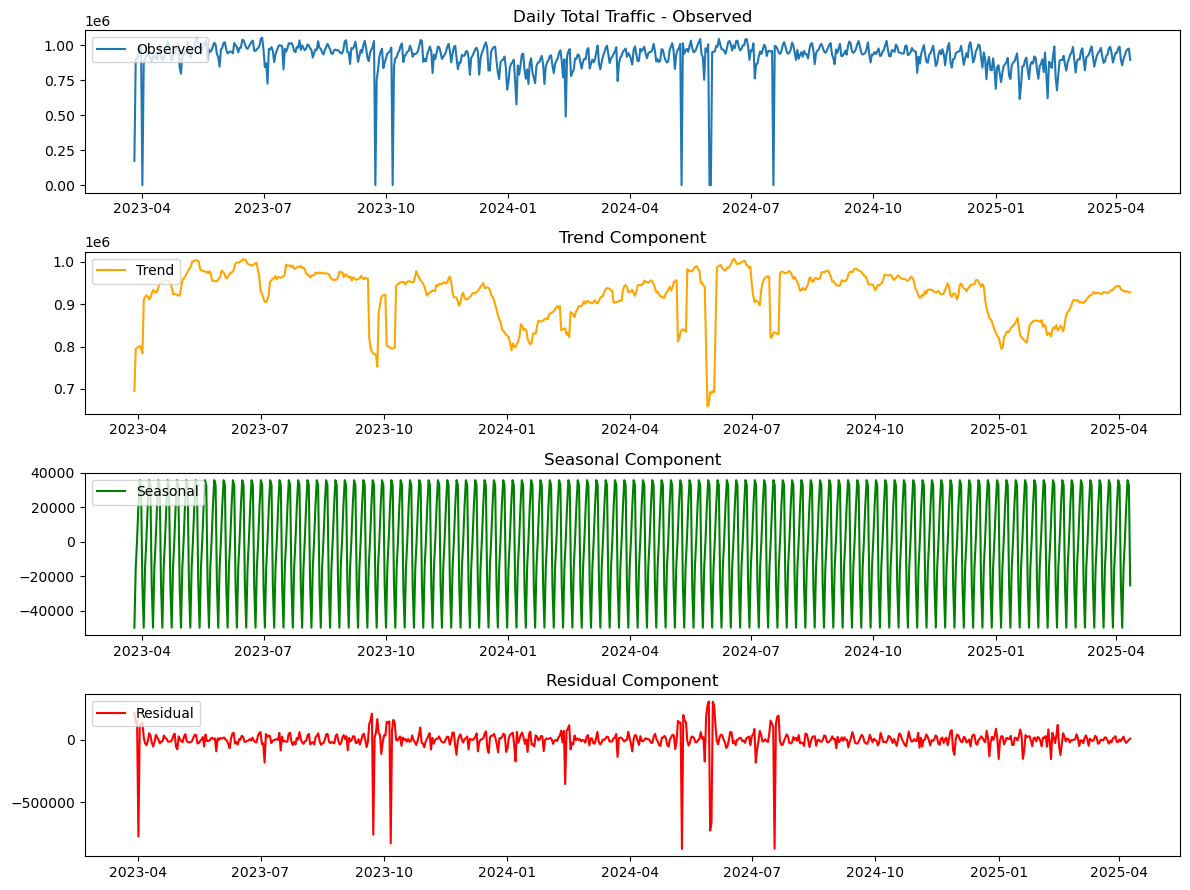

In [3]:
# STL tools
import statsmodels as sms
from statsmodels.tsa.seasonal import seasonal_decompose

# Making a dataframe copy for STL purposes
STL_data = df.copy()

# Set date as index
STL_data = STL_data.set_index('date')

# Sort by date
STL_data = STL_data.sort_index()

# AggregatING to Hourly and/or Daily and/or Weekly Traffic
# Daily total traffic
# Resample types respective intervals and sum the total_vehicles
hourly_traffic = STL_data['total_vehicles'].resample('h').sum()
daily_traffic = STL_data['total_vehicles'].resample('D').sum()
weekly_traffic = STL_data['total_vehicles'].resample('W').sum()

# Seasonal decomposition (additive)
decomp = seasonal_decompose(daily_traffic,
                            model='additive', period=7)  # period=7 for weekly seasonality

# Extract components
trend = decomp.trend
seasonal = decomp.seasonal
residual = decomp.resid


#Plotting the Components
plt.figure(figsize=(12, 9))

plt.subplot(4, 1, 1)
plt.plot(daily_traffic, label='Observed')
plt.legend(loc='upper left')
plt.title('Daily Total Traffic - Observed')

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.title('Trend Component')

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.title('Seasonal Component')

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residual', color='red')
plt.legend(loc='upper left')
plt.title('Residual Component')

plt.tight_layout()
plt.show()

Interpretation of the STL  development:


1. **Raw pyplot based time series versus the .resample('D') based time series plot**

The raw time series (pyplot based) plot versus the .resample('D') plot for observed traffic appears quite visually contrary to each other. The .resample('D') operation is a "powerful tool" used to convert the hourly or trip-level data into a daily time series.


2. **Observed Data: The Raw Signal**

The top panel shows a fairly consistent daily volume oscillating around 900,000 to 1,000,000 vehicles. However, the most striking features are the three deep "drop-outs" where traffic falls nearly to zero. In a real-world context, these usually represent data collection outages or major bridge/tunnel closures rather than a literal lack of cars in NYC.

3. **Trend Component: The Macro View**

The trend line has been smoothed to remove daily "noise," revealing the underlying momentum:

Summer Peak (June - August 2024): You can see a clear rise in the trend as NYC enters its peak travel and tourism season.

Winter Dip (January 2025): There is a significant, sustained drop in the trend throughout January. This likely correlates with post-holiday economic slowdowns and potentially severe winter weather affecting road conditions.

The "V" Recovery: After the January low, the trend shows a steady upward climb back toward the 900k mark as spring 2025 approaches.

4. **Seasonal Component: The Heartbeat**

The green seasonal panel shows a highly disciplined, repeating pattern.

Weekly Cycle: The sharp peaks and valleys reflect the standard weekday vs. weekend contrast.

Magnitude: The seasonal swings account for approximately ±40,000 vehicles relative to the trend. This tells you that day-of-the-week is a massive, predictable driver of your total volume—essential for any predictive machine learning model.

5. **Residual (Remainder) Component: The Anomaly Detector**

The residual panel is arguably the most useful for your "Stochastic" and "Machine Learning" goals.

Major Outliers: The three massive negative spikes (matching the drops in the Observed data) are confirmed here as extreme anomalies.

Volatility Clusters: Notice how the residual is relatively "quiet" (flat) during the fall of 2024, but becomes more volatile around May/June and January. This suggests that during those months, traffic is less predictable and more prone to external shocks (weather, accidents, or construction).


**Possible Resolutions:**

Data Cleaning: Before training a model (like an LSTM or Random Forest), to interpolate or impute the three zero-drop anomalies. If the zeros are left alone, the model will "learn" that traffic occasionally vanishes, which can ruin accuracy.

Anomaly Investigation: Look up the specific dates of those large Residual spikes in May and July 2024. Cross-referencing them with NYC news or MTA alerts could provide a "Ground Truth" for an automated anomaly detection system.

Feature Engineering: Use the Seasonal component to create a "DayOfWeek" feature. Since the seasonality is so strong, a simple categorical variable (Monday–Sunday) will likely be your most powerful predictor.

If the smallest 30 cases for total vehicles is 24, then there was never a complete halt of traffic for the considered period. 

Observing such values based on sorted dates and location:

In [4]:
# Filter the dataframe for May and July
may_july_df = df[(df['date'].dt.month == 5) | (df['date'].dt.month == 7)]

# Sort the filtered dataframe by total_vehicles in ascending order
sorted_may_july_df = may_july_df.sort_values('total_vehicles')

# Get the top 30 rows with smallest total_vehicles
smallest_30 = sorted_may_july_df.iloc[:30][['date', 'total_vehicles', 'plaza_id', 'hour']]

# Display the results
for index, row in smallest_30.iterrows():
    print(f"Date: {row['date']}, Total Vehicles: {row['total_vehicles']}, Plaza ID: {row['plaza_id']}, Hour: {row['hour']}")

Date: 2023-05-11 00:00:00, Total Vehicles: 38, Plaza ID: 25, Hour: 2
Date: 2023-05-12 00:00:00, Total Vehicles: 39, Plaza ID: 25, Hour: 3
Date: 2023-05-02 00:00:00, Total Vehicles: 42, Plaza ID: 25, Hour: 2
Date: 2023-05-12 00:00:00, Total Vehicles: 44, Plaza ID: 25, Hour: 3
Date: 2023-05-08 00:00:00, Total Vehicles: 45, Plaza ID: 25, Hour: 2
Date: 2023-05-03 00:00:00, Total Vehicles: 45, Plaza ID: 25, Hour: 2
Date: 2023-05-10 00:00:00, Total Vehicles: 47, Plaza ID: 25, Hour: 2
Date: 2023-05-04 00:00:00, Total Vehicles: 47, Plaza ID: 25, Hour: 2
Date: 2023-07-10 00:00:00, Total Vehicles: 47, Plaza ID: 25, Hour: 2
Date: 2023-05-31 00:00:00, Total Vehicles: 48, Plaza ID: 25, Hour: 2
Date: 2024-05-07 00:00:00, Total Vehicles: 49, Plaza ID: 25, Hour: 2
Date: 2023-05-10 00:00:00, Total Vehicles: 49, Plaza ID: 25, Hour: 3
Date: 2024-07-23 00:00:00, Total Vehicles: 49, Plaza ID: 25, Hour: 2
Date: 2024-07-30 00:00:00, Total Vehicles: 50, Plaza ID: 25, Hour: 2
Date: 2023-05-12 00:00:00, Total V

Observing with sorted dates:

In [5]:
smallest_30.sort_values('date')

,date,total_vehicles,plaza_id,hour
304546,2023-05-02,53,25,1
304548,2023-05-02,42,25,2
304116,2023-05-03,45,25,2
303686,2023-05-04,52,25,3
303684,2023-05-04,47,25,2
301957,2023-05-08,51,25,3
301956,2023-05-08,45,25,2
301522,2023-05-09,50,25,1
301092,2023-05-10,47,25,2
301094,2023-05-10,49,25,3


The location involving minimal traffic flow are 24 = Henry Hudson Bridge (HHB), and 25 = Marine Parkway-Gil Hodges Memorial Bridge (MPB). hours of occurences range from 1AM to 3AM. Such times are typical to have low levels of traffic.

For now, will trust the pyplot based time series. 

### Identifying Peak Hours From the Data

Identifying peak hours serves as the analytical foundation for urban planning, fiscal forecasting, and infrastructure management. Since you are working with high-granularity data like the MTA Bridges and Tunnels Hourly Traffic Rates, pinpointing these "rush periods" allows for several critical applications:

1. Dynamic Pricing and Revenue Optimization

Peak hour identification is the primary requirement for Congestion Pricing models.

    Elasticity Modelling: By identifying when demand is highest, agencies can calculate price elasticity—how much a toll increase during peak hours reduces volume versus how much it increases total revenue.
    
    Fiscal Forecasting: Governments use peak data to build more accurate budgetary models, as a significant portion of annual toll revenue is often generated during a small fraction of total operating hours.

2. Infrastructure & Maintenance Planning

Bridges and tunnels have finite lifespans influenced by "load cycles".

    Stress Distribution: Engineers use peak volume data to model the physical wear and tear on suspension cables, road decks, and ventilation systems.
    
    Maintenance Windows: Identifying "true troughs" (the inverse of peaks) is essential for scheduling lane closures or construction. Performing maintenance during a 2:00 AM trough rather than a 4:00 AM "early-bird" peak prevents cascading gridlock across the city.

3. Resource Allocation and Incident Management

Peak hours are statistically correlated with higher rates of vehicular incidents.

    Strategic Positioning: Emergency response vehicles (tow trucks, ambulances) are often pre-positioned near "bottleneck" plazas specifically during identified peak windows to minimise clearance times.
    
    Staffing Levels: For crossings that still require manual monitoring or security checkpoints, peak data dictates the shifts and headcount required for safety and flow management.

4. Environmental and Public Health Impact

Peak hours represent the highest concentration of localized air pollution.

Emissions Modeling: Idling engines in stop-and-go peak traffic emit significantly more $CO_{2}$ and particulate matter than free-flowing traffic. Identifying these hours helps environmental scientists map "pollution spikes" in neighborhoods adjacent to tunnel exhausts or bridge landings (e.g., the Bronx or Long Island City).

Commuter Wellness: Urban planners use peak duration data to study the "travel time reliability" of a city, which is a key metric for measuring the quality of life and economic productivity of the workforce.

5. Multi-Modal Shift Strategy

If a specific bridge (like the Verrazzano) shows expanding peak windows (e.g., peak "spreading" where the rush lasts four hours instead of two), it signals to transit authorities that the current infrastructure is at capacity.

    Incentivizing Alternatives: This data justifies the expansion of alternative transit options, such as increased ferry service or dedicated bus lanes, to "shave the peak" and move commuters to more efficient modes of transport.

Aggregating traffic by hour to reveal which hours have the largest traffic volumes:

In [6]:
hourly_avg = (
    df.groupby("hour")["total_vehicles"]
    .mean()
    .sort_values(ascending=False)
)

print(hourly_avg)

hour
15    3282.323163
16    3258.598651
17    3202.063343
14    3120.906072
18    3028.198876
13    2884.282651
12    2739.233018
19    2686.118066
8     2676.062158
11    2649.148770
7     2642.188770
9     2637.259076
10    2599.765394
6     2352.427468
20    2280.627100
21    1976.123649
22    1748.076877
5     1423.061033
23    1418.769312
0      993.821804
4      703.313892
1      616.885564
2      448.676971
3      438.843956
Name: total_vehicles, dtype: float64


Visualizing hourly traffic based on prior aggregation:

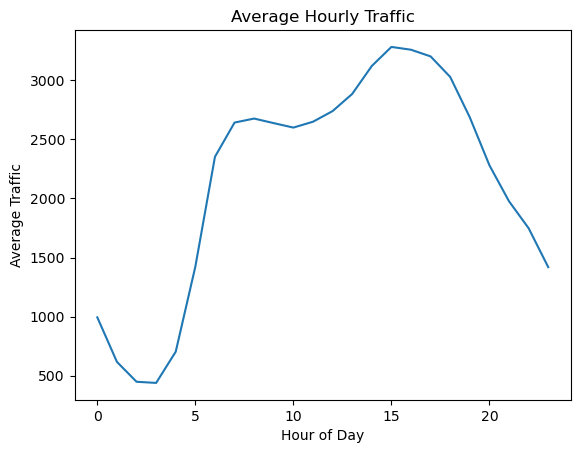

In [7]:
import matplotlib.pyplot as plt

hourly_avg.sort_index().plot()

plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic")
plt.title("Average Hourly Traffic")
plt.show()

For the above to observe a **bimodal distribution**, being a highly characteristic signature of commuter traffic. Unlike a "normal" (Bell Curve) distribution which has one peak, a bimodal distribution has two distinct peaks (modes).

1. The "Rush Hour" Signature

To observe see two clear "humps":

Peak 1 (The Morning Rush): Usually between 7:00 AM and 9:00 AM, representing inbound traffic to job centers.

Peak 2 (The Evening Rush): Usually between 3:00 PM and 6:00 PM, representing outbound traffic.

The Valley: The dip in between (noon) represents the "mid-day lull."

Defining peak hours using a data rule:

In [8]:
peak_hours = hourly_avg.nlargest(6).index.tolist()

print(peak_hours)

[15, 16, 17, 14, 18, 13]


Established above is peak hours being data-driven rather than status quo sentiment.

Alternatively, a quantile-based definition: Peak = hours above 75th percentile.

In [9]:
threshold = hourly_avg.quantile(0.75)

peak_hours_q = hourly_avg[hourly_avg >= threshold].index

peak_hours_q

Index([15, 16, 17, 14, 18, 13], dtype='int64', name='hour')

Statistical definition for peak hours:

$$Peak=\{h:\mu_h>\mu+\sigma\}$$

Where:

$\mu_h$ mean traffic at hour $h$

$\mu$ being the overall mean

$\sigma$ being the standard deviation

In [10]:
mean = hourly_avg.mean()
std = hourly_avg.std()

peak_hours_stat = hourly_avg[hourly_avg > mean + std].index

peak_hours_stat

Index([15, 16, 17, 14], dtype='int64', name='hour')

Preference for peak hours model to be the one that emphasies maxizmum behaviour instead of the measure of spread. Namely, preference for direct interpretability of traffic behaviour. 

In [11]:
infrastructure_types = df['plaza_id'].unique()

print(infrastructure_types)

[21 22 23 24 25 26 27 28 29 30]


Top peak hour per infrastructure:

In [12]:
peak_hours_by_bridge = (
    df.groupby(["plaza_id","hour"])["total_vehicles"]
    .mean()
    .reset_index()
)

peak_hours_by_bridge = peak_hours_by_bridge.loc[
    peak_hours_by_bridge.groupby("plaza_id")["total_vehicles"].idxmax()
]

peak_hours_by_bridge

,plaza_id,hour,total_vehicles
14,21,14,8617.586253
39,22,15,3130.781671
64,23,16,4172.371120
88,24,16,2825.892713
111,25,15,862.860324
135,26,15,794.753711
160,27,16,2505.305668
183,28,15,2190.847503
208,29,16,3774.597166
233,30,17,6828.854926


Using .quantile(0.75) per infrastructure to acquire significcant peak hours per infrastructure:

In [13]:
peak_hours_by_bridge = (
    df.groupby(["plaza_id", "hour"])["total_vehicles"]
    .mean()
    .reset_index()
)

# Compute 75th percentile threshold per plaza
thresholds = peak_hours_by_bridge.groupby("plaza_id")["total_vehicles"].transform(
    lambda x: x.quantile(0.75)
)

# Keep hours above the threshold
top_hours = peak_hours_by_bridge[
    peak_hours_by_bridge["total_vehicles"] >= thresholds
]

print(top_hours.sort_values(["plaza_id","total_vehicles"], ascending=[True, False]))

     plaza_id  hour  total_vehicles
14         21    14     8617.586253
15         21    15     8568.809973
16         21    16     8163.346361
13         21    13     8092.080863
7          21     7     7963.935310
17         21    17     7879.345013
39         22    15     3130.781671
40         22    16     3064.688679
41         22    17     2960.281671
38         22    14     2880.105121
37         22    13     2787.252022
42         22    18     2715.958221
64         23    16     4172.371120
63         23    15     4165.226046
65         23    17     4033.897436
62         23    14     3982.044534
66         23    18     3849.516194
61         23    13     3699.609312
88         24    16     2825.892713
89         24    17     2762.759109
87         24    15     2727.759784
90         24    18     2473.261808
86         24    14     2436.772605
85         24    13     2157.746289
111        25    15      862.860324
112        25    16      843.570850
113        25    17      819

Visualizing the peak hour clusters:

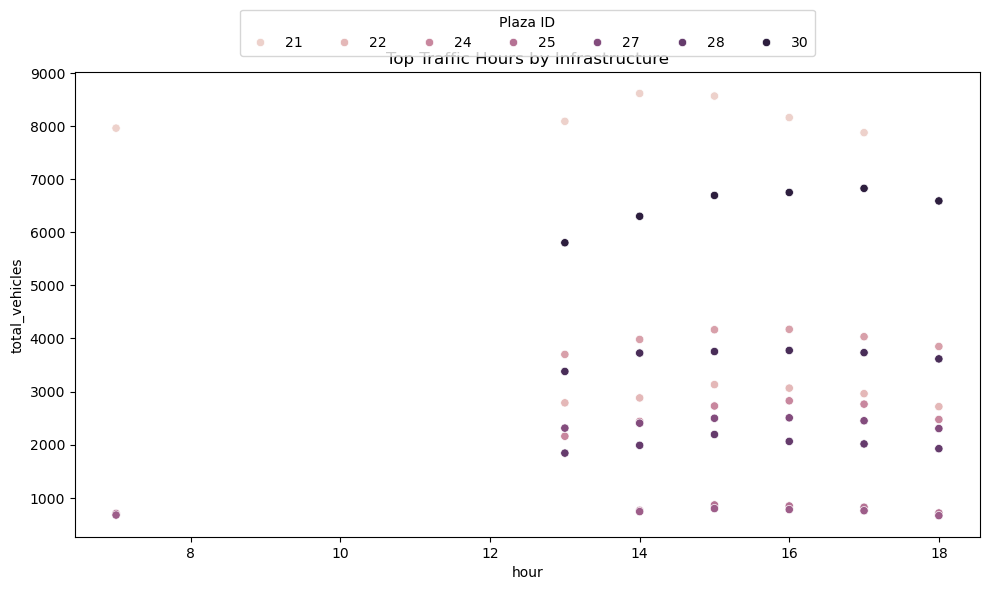

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=top_hours,
    x="hour",
    y="total_vehicles",
    hue="plaza_id"
)

plt.title("Top Traffic Hours by Infrastructure")

plt.legend(
    title="Plaza ID",
    bbox_to_anchor=(0.5, 1.15),
    loc="upper center",
    ncol=len(top_hours["plaza_id"].unique())
)

plt.tight_layout()
plt.show()

For facilities 22 to 30, concerning hours 13 through 18, there is visual evidence that such facilities are ultilised almost equally involving commutes, suggesting significant economic and socioeconmic themes underlying. 

## Hirschman Index (HHI)

To now measure how concentrated traffic is across bridges or tunnels using the Herfindahl-Hirschman Index (HHI).

The HHI (Hirschman, 1945) is a measure of concentration originally used in economics to quantify market concentration. Here, we adapt it to traffic concentration:

$$HHI=\sum_{i=1}^N s_{i}^2$$

where:

$s_i\,=\,\frac{\text{traffic on facility}\,i}{\text{total traffic across all facilities}}$

$N=$ the number of facilities

$HHI\,\in[0,1]$

1. Closer to 1 → traffic is highly concentrated on a few bridges

2. Closer to 0 → traffic is evenly distributed

Attributes of interest:

1. plaza_id → bridge or tunnel name

2. total_vehicles → traffic count

In [15]:
import numpy as np

HHI_data = df.copy()

traffic_summary = HHI_data.groupby("plaza_id")["total_vehicles"].sum().reset_index()

# Compute market share per facility
traffic_summary["share"] = traffic_summary["total_vehicles"] / traffic_summary["total_vehicles"].sum()

# Compute HHI
traffic_summary["share_sq"] = traffic_summary["share"]**2
HHI = traffic_summary["share_sq"].sum()

print("Traffic HHI:", HHI)

# Rank facilities by share
traffic_summary = traffic_summary.sort_values("share", ascending=False)
print(traffic_summary)

Traffic HHI: 0.140742061863425
   plaza_id  total_vehicles     share  share_sq
9        30       164186226  0.237649  0.056477
0        21       106017738  0.153454  0.023548
2        23       101399365  0.146769  0.021541
8        29        90994624  0.131709  0.017347
6        27        61858220  0.089536  0.008017
3        24        51612013  0.074705  0.005581
7        28        46474492  0.067269  0.004525
1        22        34671707  0.050185  0.002519
4        25        16981770  0.024580  0.000604
5        26        16680026  0.024143  0.000583


**Traffic Concentration vs Facility Rank**

Ranking the bridges/tunnels by traffic share and plot HHI-style “concentration curve”:

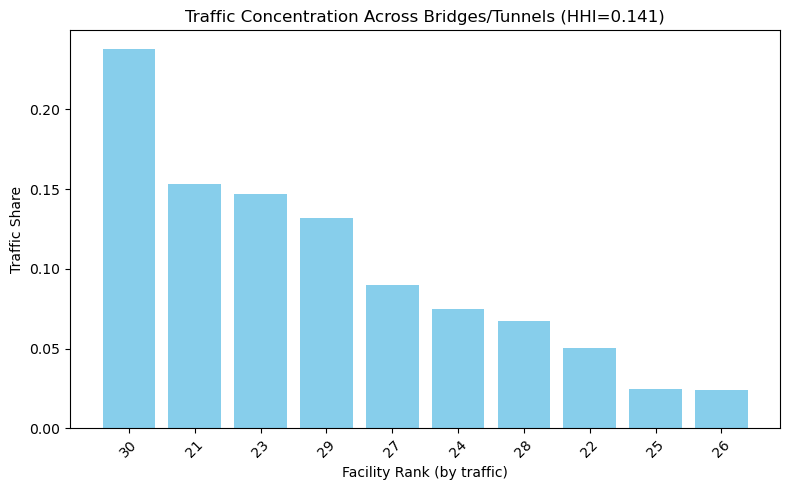

In [16]:
# Ranking facilities by share
traffic_summary = traffic_summary.sort_values("share", ascending=False)
traffic_summary["rank"] = np.arange(1, len(traffic_summary)+1)

plt.figure(figsize=(8,5))
plt.bar(traffic_summary["rank"], traffic_summary["share"], color='skyblue')
plt.xlabel("Facility Rank (by traffic)")
plt.ylabel("Traffic Share")
plt.title(f"Traffic Concentration Across Bridges/Tunnels (HHI={HHI:.3f})")
plt.xticks(traffic_summary["rank"], traffic_summary["plaza_id"], rotation=45)
plt.tight_layout()
plt.show()

**Temporal HHI: Hourly Traffic Concentration**

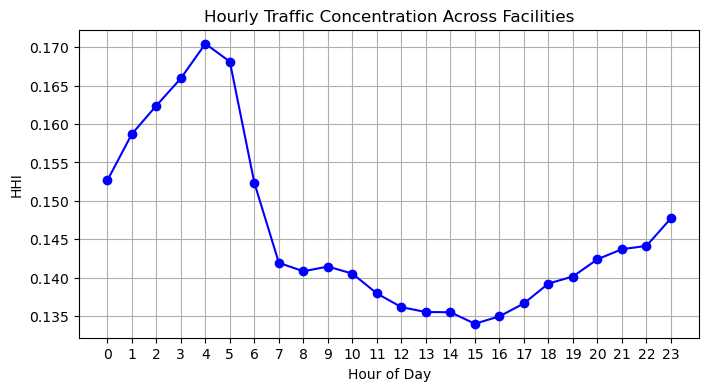

In [17]:
# Hourly HHI
hourly_hhi = []

for h in sorted(HHI_data['hour'].unique()):
    temp = HHI_data[HHI_data['hour']==h].groupby("plaza_id")["total_vehicles"].sum()
    share = temp / temp.sum()
    hhi = (share**2).sum()
    hourly_hhi.append({"hour": h, "HHI": hhi})

hourly_hhi = pd.DataFrame(hourly_hhi)

# Plot hourly HHI
plt.figure(figsize=(8,4))
plt.plot(hourly_hhi["hour"], hourly_hhi["HHI"], marker='o', color='blue')
plt.xlabel("Hour of Day")
plt.ylabel("HHI")
plt.title("Hourly Traffic Concentration Across Facilities")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

**Hourly Traffic Shares Per Facility:** to compare which facilities carry more traffic at each hour --   

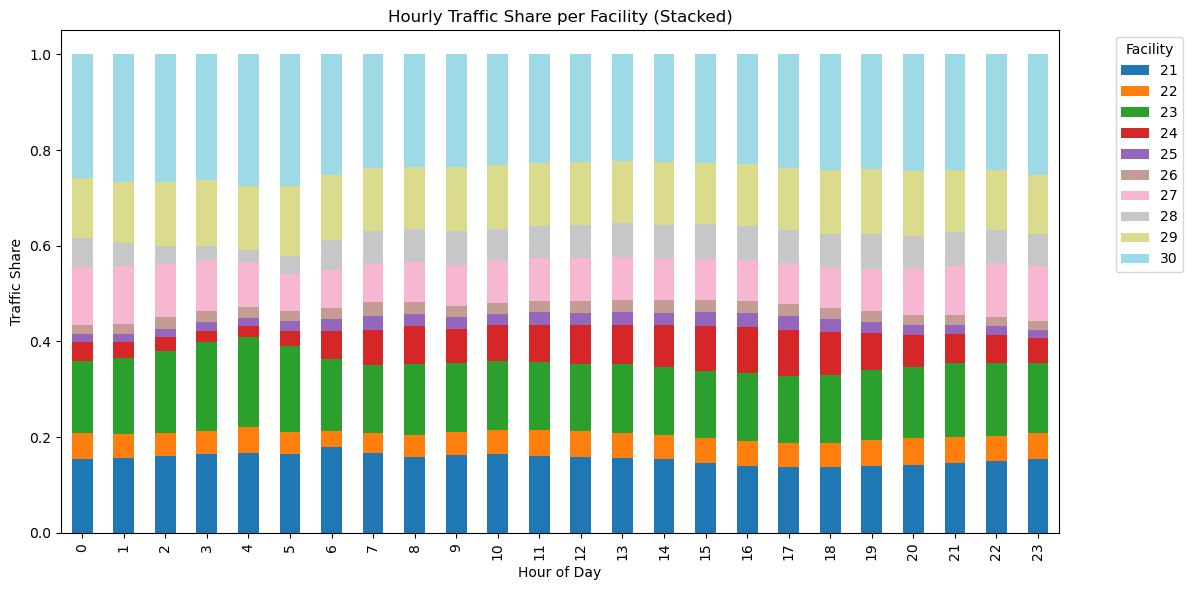

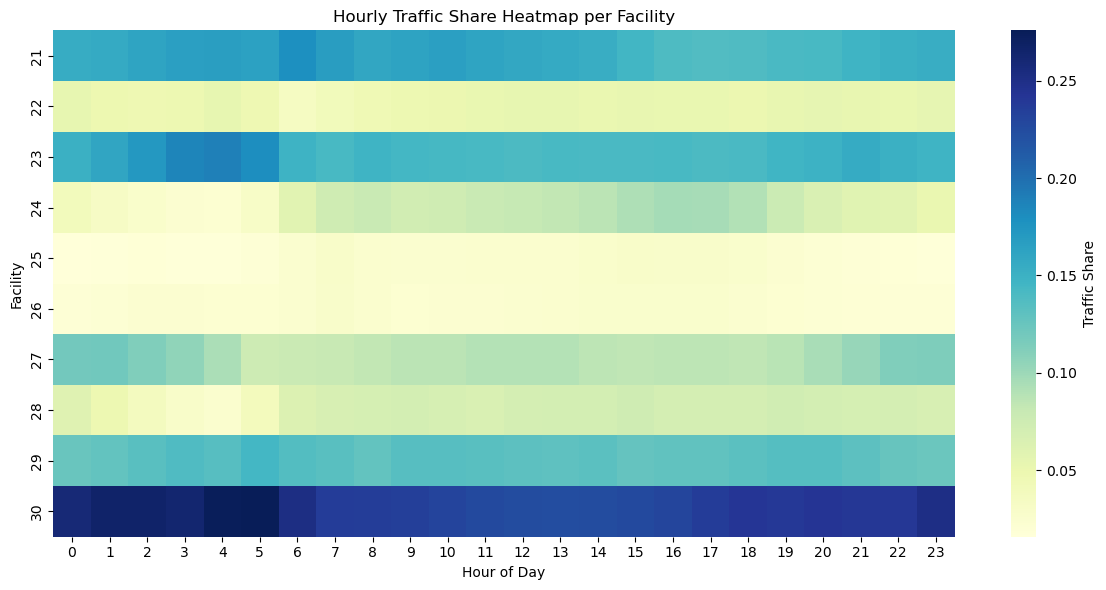

In [18]:
# Facility identifier
facility_col = 'plaza_id' if 'plaza_id' in df.columns else 'facility_name'

# -------------------------
# Compute hourly traffic share per facility
# -------------------------
hourly_traffic = df.groupby(['hour', facility_col])['total_vehicles'].sum().reset_index()

# Total traffic per hour
hourly_traffic['hourly_total'] = hourly_traffic.groupby('hour')['total_vehicles'].transform('sum')

# Share per facility
hourly_traffic['share'] = hourly_traffic['total_vehicles'] / hourly_traffic['hourly_total']

# Pivot for plotting
hourly_pivot = hourly_traffic.pivot(index='hour', columns=facility_col, values='share').fillna(0)

# -------------------------
# Stacked bar plot of hourly shares
# -------------------------
hourly_pivot.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.xlabel("Hour of Day")
plt.ylabel("Traffic Share")
plt.title("Hourly Traffic Share per Facility (Stacked)")
plt.legend(title='Facility', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# -------------------------
# Heatmap of hourly share per facility
# -------------------------
plt.figure(figsize=(12,6))
sns.heatmap(hourly_pivot.T, cmap='YlGnBu', cbar_kws={'label':'Traffic Share'})
plt.xlabel("Hour of Day")
plt.ylabel("Facility")
plt.title("Hourly Traffic Share Heatmap per Facility")
plt.tight_layout()
plt.show()

**Hourly Traffic Share per Facility (Stacked Bar Chart)**

1. This graph illustrates the relative contribution of each facility to the total traffic volume at any given hour.

2. Consistency of Composition: The overall "stack" looks remarkably stable across the 24 hours. This suggests that the distribution of traffic across the network doesn't undergo radical shifts (e.g., one facility doesn't suddenly go from 5% to 50% of the total network load).

3. Dominant vs. Minor Facilities: * Facility 30 (Light Blue): This is consistently the largest contributor to total volume, holding the top position in the stack across all hours.

       Facility 23 (Green): This is the second-largest contributor.

       Facilities 25 and 26: These are the smallest contributors (the thinnest slices), indicating they handle much lower volumes than the rest of the network.

4. Subtle Shifts: You can see a slight expansion in the share of Facility 30 during the early morning hours (roughly 0 to 5), while Facility 23 seems to take up a slightly larger share during the mid-day "peak" hours.

**Hourly Traffic Share Heatmap per Facility**

1. While the first graph shows how facilities compare to each other, the heatmap focuses on the internal hourly intensity for each individual facility.

2. Vertical Stratification: The clear horizontal bands confirm that facilities have distinct "baseline" volumes. Facility 30 is deep blue (high intensity) across the board, whereas Facility 25 is nearly white (low intensity).

3. Facility-Specific Peaks:

    Facility 23: Shows a distinct dark blue "hot spot" between Hours 3 and 5. This might indicate early morning commercial transit or freight activity specific to that route.

    Facility 30: Its peak intensity occurs around Hour 4, followed by a sustained high-volume period throughout the day.

    Facility 21: Shows a slight darkening (increased share) during the traditional morning commute window (Hours 6-8).

4. The "Lull" Period: Most facilities (like 24, 27, and 28) show lighter colors during the very early morning (Hours 0-3), which is expected as general traffic volume drops.

## Stochastic Modelling

### Negative Binomial Models

Now, theres attempt at applying a (discrete) Negative Binomial process (Ross, 2012) to the MTA Bridges and Tunnels data for modelling "counting events" (vehicle arrivals/record) over a fixed interval of time. To treat the arrival of each "unique trip" as an independent event occurring at a specific rate, denoted as $\lambda$ (lambda).

In a complex transit network like NYC's, the variance of vehicle counts almost always exceeds the mean—a violation of Poisson assumptions.

When observing hourly crossings for facilities like the Queens Midtown Tunnel or the Verrazzano-Narrows Bridge, several factors introduce "burstiness" that a simple Poisson model can't capture:

*Heterogeneity of Drivers:* Traffic isn't a uniform stream of identical "events." You have commuters, commercial trucks, and ride-share vehicles, all with different arrival patterns.

*Temporal Clustering:* Events like a "gridlock alert day," a stalled vehicle in the Lincoln Tunnel, or a sudden thunderstorm cause traffic to "clump," creating higher variance than expected.

*Zero-Inflation:* Late-night hours on smaller bridges may have many periods with zero or near-zero counts, which the NB framework handles more gracefully than Poisson.

**The Mathematical Framework**

If modeling $Y$ (the count of vehicles per hour), the Negative Binomial framework expresses the probability of seeing $y$ vehicles as:

$$P(Y=y | \mu, \alpha) = \frac{\Gamma(y + \frac{1}{\alpha})}{\Gamma(y+1)\Gamma(\frac{1}{\alpha})} \left( \frac{1}{1 + \alpha\mu} \right)^{\frac{1}{\alpha}} \left( \frac{\alpha\mu}{1 + \alpha\mu} \right)^y$$

The regression model is specified as:

$$
\log(E[Y]) =
\beta_0 +
\beta_1 \text{Hour} +
\beta_2 \text{DayType} +
\beta_3 \text{Plaza}
$$

Where:

- $Y$ = total vehicle count  
- Hour = hour of day  
- DatType = indicator variable for type of day durring the week (weekday or weekend)  
- Plaza = toll facility identifier  

The **log-link function** ensures predicted traffic counts remain positive.

---


Key Parameters for the Model:

$\mu$ (The Mean): In the specific formula "$total_vehicles ~ hour + \text{Cat}(daytype) + \text{Cat}(plaza)$", the $\mu$ is conditioned on the predictors:

$$\ln(\mu) = \beta_0 + \beta_1(\text{hour}) + \beta_2(\text{DayType}) + \beta_3(\text{Plaza})$$

$\alpha$ (The Dispersion Parameter): This is the "magic" of the NB model.

1. If $\alpha \to 0$, the model collapses into a Poisson distribution.

2. If $\alpha > 0$, the variance is $\mu + \alpha\mu^2$. For NYC, $\alpha$ is typically quite significant because of the massive swings between 3 AM lulls and 8 AM rushes.

**Methods for Determining Optimal Alpha**

1. Maximum Likelihood Estimation (MLE): Standard statistical software (Stata, R, SAS) uses iterative techniques like Newton-Raphson to jointly estimate the regression coefficients and the dispersion parameter.

2. Likelihood Ratio Test (LRT): To confirm the necessity of, a LRT compares the negative binomial model to a Poisson model (where). A significant chi-squared value indicates that is non-zero, justifying the use of the negative binomial model.

3. Iterative Estimation (GLM): While standard Generalized Linear Models (GLM) often require a fixed, software packages can estimate in an iterative loop outside the main regression, where is updated until convergence. 

**Homogeneous vs. Non-Homogeneous Processes**

Because the data exhibits a bimodal distribution (morning and evening peaks), a simple Poisson process isn't enough. To employ a Non-Homogeneous model:

*Homogeneous*: Assumes $\lambda$ is constant (e.g., the bridge always gets 1,000 cars/hour). This is unrealistic for NYC.

*Non-Homogeneous*: Recognises that $\lambda(t)$ is a function of time. Your "Peak Hour" analysis earlier defines this function:

$\lambda\,(7:00 AM)$ might be $8,500$.

$\lambda\,(3:00 AM)$ might be $400$.

Sanity checks for temporal attributes:

In [19]:
stochas_data = df.copy()

weekday = stochas_data['day_of_week'].unique()
print(weekday)

[5 4 3 2 1 0 6]


In [20]:
day= stochas_data['day'].unique()
print(day)

[12 11 10  9  8  7  6  5  4  3  2  1 31 30 29 28 27 26 25 24 23 22 21 20
 19 18 17 16 15 14 13]


Making a more focused categorical attribute from 'day_of_week'. Say, a distinction between weekdays and weekends:

In [21]:
stochas_data["day_type"] = stochas_data["day_of_week"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday")
print(stochas_data.head(7))

   plaza_id       date  hour direction  vehicles_e_zpass  vehicles_vtoll  \
0        21 2025-04-12     0         I              2602             652   
1        21 2025-04-12     1         I              1772             506   
2        21 2025-04-12     2         I              1212             348   
3        21 2025-04-12     3         I              1331             335   
4        21 2025-04-12     4         I              1589             353   
5        21 2025-04-12     5         I              2035             365   
6        21 2025-04-12     6         I              3337             606   

   total_vehicles  year  month  day  day_of_week day_type  
0            3275  2025      4   12            5  Weekend  
1            2299  2025      4   12            5  Weekend  
2            1581  2025      4   12            5  Weekend  
3            1687  2025      4   12            5  Weekend  
4            1963  2025      4   12            5  Weekend  
5            2421  2025      4 

In [22]:
day_types = stochas_data['day_type'].unique()
print(day_types)

['Weekend' 'Weekday']


Traffic flows vary through the day. Arrival rate becomes time dependent:

Applying an overdispersion check:

In [23]:
dispersion_check = (
    df.groupby("hour")["total_vehicles"]
    .agg(["mean","var"])
    .reset_index()
)

dispersion_check["dispersion_ratio"] = (
    dispersion_check["var"] / dispersion_check["mean"]
)

print(dispersion_check)

    hour         mean           var  dispersion_ratio
0      0   993.821804  7.979258e+05        802.886172
1      1   616.885564  3.522148e+05        570.956458
2      2   448.676971  1.880206e+05        419.055645
3      3   438.843956  1.669941e+05        380.531740
4      4   703.313892  4.814272e+05        684.512597
5      5  1423.061033  2.396516e+06       1684.056929
6      6  2352.427468  5.925295e+06       2518.800346
7      7  2642.188770  5.499751e+06       2081.513448
8      8  2676.062158  4.632682e+06       1731.156192
9      9  2637.259076  4.250194e+06       1611.595181
10    10  2599.765394  3.902420e+06       1501.066211
11    11  2649.148770  3.776931e+06       1425.714823
12    12  2739.233018  3.824076e+06       1396.038924
13    13  2884.282651  4.100456e+06       1421.655356
14    14  3120.906072  4.684791e+06       1501.099546
15    15  3282.323163  4.853960e+06       1478.818350
16    16  3258.598651  4.752609e+06       1458.482565
17    17  3202.063343  4.715

Overdispersed" count data—where the variance is significantly larger than the mean. While the Poisson distribution assumes the mean and variance are equal, the Negative Binomial allows for more flexibility. Will initially develop models based on the discrete negative binomial via statmodels because one acquires an estimation of $alpha$ to gauge with concerning general negative binomial models.

In [24]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial

# Prepare design matrix (X) and response (y)
# Use patsy formula for convenience
import patsy

y, X = patsy.dmatrices("total_vehicles ~ hour + C(day_type) + C(plaza_id)",
                       data=stochas_data, return_type='dataframe')

# Fit Negative Binomial
nb_model = NegativeBinomial(y, X).fit()

print(nb_model.summary())

Optimization terminated successfully.
         Current function value: 8.152457
         Iterations: 24
         Function evaluations: 29
         Gradient evaluations: 29
                     NegativeBinomial Regression Results                      
Dep. Variable:         total_vehicles   No. Observations:               320000
Model:               NegativeBinomial   Df Residuals:                   319988
Method:                           MLE   Df Model:                           11
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.06029
Time:                        17:16:02   Log-Likelihood:            -2.6088e+06
converged:                       True   LL-Null:                   -2.7762e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept     

| Metric         | Value                      |
| -------------- | -------------------------- |
| Pseudo R²      | 0.0603 (~6%)               |
| Log-Likelihood | -2,608,800                 |
| LL-Null        | -2,776,200                 |
| LLR p-value    | 0.000 (highly significant) |



**Interpretation:**

1. Pseudo R² improved from 0.005 → 0.06 after including plaza_id

2. Likelihood ratio test is significant → plaza differences are meaningful

3. Count data is still stochastic, so R² will naturally be low


| Variable               | coef   | IRR = exp(coef) | Meaning                                               |
| ---------------------- | ------ | --------------- | ----------------------------------------------------- |
| Intercept              | 8.075  | 3,194           | Baseline log-count for plaza 21, weekday, hour 0      |
| C(day_type)[T.Weekend] | -0.110 | 0.896           | Weekend arrivals ~10% lower than weekdays             |
| C(plaza_id)[T.22]      | -1.150 | 0.316           | Expected traffic at plaza 22 ~68% lower than plaza 21 |
| C(plaza_id)[T.25]      | -2.550 | 0.078           | Plaza 25 has much lower traffic than baseline         |
| hour                   | 0.054  | 1.056           | Each hour increases arrivals by ~5.6%                 |
| alpha                  | 0.381  | —               | Overdispersion parameter (variance = μ + 0.381 μ²)    |


**Notes:**

1. Each plaza coefficient shows traffic relative to baseline plaza (21)

2. Overdispersion decreased from 0.856 → 0.381 because including plaza_id captures variability previously attributed to α.

3. hour effect: traffic rises steadily with time-of-day

4. day_type effect: weekends are slightly lower


**Some Main Points for Toll Plaza Analysis**

1. Plaza-specific traffic patterns matter — some plazas have dramatically lower arrivals.

2. Time-of-day effects are consistent across plazas (hour coefficient positive).

3. Weekend effect is negative → less traffic.

4. Overdispersion is still present (α = 0.38), but less than before → model explains some variability via plaza differences.

5. This model can now be used to simulate arrival processes per plaza:

$$\lambda_{plaza}(t)=e^{(\text{Intercept+Plaza Effect+Weekend Effect+Hour Effect})}$$

Predicting $\lambda(t)$ for Each Plaza:

In [25]:
import numpy as np

# Design matrix for predictions
y, X = patsy.dmatrices("total_vehicles ~ hour + C(day_type) + C(plaza_id)",
                       data=stochas_data, return_type='dataframe')

# Predicted mean arrivals per observation
stochas_data["predicted_arrivals"] = nb_model.predict(X)

# Example: average predicted arrivals by plaza and hour
arrival_rates = stochas_data.groupby(["plaza_id","hour"])["predicted_arrivals"].mean().reset_index()
print(arrival_rates.head(60))

    plaza_id  hour  predicted_arrivals
0         21     0         3118.077845
1         21     1         3291.954378
2         21     2         3476.250162
3         21     3         3669.336295
4         21     4         3873.953212
5         21     5         4089.980389
6         21     6         4318.054108
7         21     7         4558.846133
8         21     8         4813.065688
9         21     9         5081.461545
10        21    10         5364.824232
11        21    11         5663.988360
12        21    12         5979.835080
13        21    13         6313.294681
14        21    14         6665.349327
15        21    15         7037.035953
16        21    16         7429.449316
17        21    17         7843.745224
18        21    18         8281.143934
19        21    19         8742.933751
20        21    20         9230.474822
21        21    21         9744.800795
22        21    22        10288.209992
23        21    23        10861.921867
24        22     0       

To now implement the "standard" negative binomial model with the observed alpha:

In [26]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Negative Binomial regression with formula interface
nb_model_stand = smf.glm(
    formula="total_vehicles ~ hour + C(day_type) + C(plaza_id)", 
    data=stochas_data,
    family=sm.families.NegativeBinomial(alpha=0.381) 
).fit()

print(nb_model_stand.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         total_vehicles   No. Observations:               320000
Model:                            GLM   Df Residuals:                   319988
Model Family:        NegativeBinomial   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.6088e+06
Date:                Thu, 12 Mar 2026   Deviance:                   3.4011e+05
Time:                        17:16:18   Pearson chi2:                 2.87e+05
No. Iterations:                    15   Pseudo R-squ. (CS):             0.8161
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  8


| Metric | Value |
|------|------|
| Observations | 320,000 |
| Log Likelihood | -2,608,800 |
| Deviance | 340,110 |
| Pearson $\chi^2$ | 287,000 |
| Pseudo $R^2$ (Cragg-Uhler) | 0.816 |

The pseudo-$R^2$ value of **0.816** indicates that the model explains a large proportion of variation in hourly traffic flows.

---

**Interpretation of Coefficients**

Hour Effect. The coefficient for the hour variable is:

$$
\beta_{hour} = 0.0543
$$

To interpret the effect in multiplicative terms, the coefficient is exponentiated to obtain the **Incident Rate Ratio (IRR)**:

$$
IRR = e^{\beta}
$$

$$
IRR = e^{0.0543} \approx 1.056
$$

This implies that each additional hour increases expected traffic by approximately **5.6%**.

---

Weekend Effect. The estimated weekend coefficient is:

$$
\beta_{weekend} = -0.1103
$$

Exponentiating gives:

$$
e^{-0.1103} \approx 0.896
$$

This indicates that **weekend traffic is approximately 10% lower than weekday traffic**.

---

Plaza Effects. Each plaza coefficient measures traffic relative to the **baseline plaza**.

Example:

$$
\beta_{plaza25} = -2.5496
$$

$$
e^{-2.5496} \approx 0.078
$$

This implies that traffic at plaza 25 is approximately **92% lower than at the reference plaza**.

These differences reflect **structural differences in facility capacity and demand**.

---

Statistical Significance. All coefficients are statistically significant:

$$
p < 0.001
$$

Because the dataset contains **320,000 observations**, statistical significance is expected. Interpretation should focus on **effect sizes rather than p-values alone**.

---

**Incorporating or labeling holidays to better improve model:**

In [27]:
import holidays

# Convert to datetime.date for comparison
stochas_data['date_only'] =stochas_data['date'].dt.date

# U.S. holidays for relevant years
years = stochas_data['date'].dt.year.unique()
us_holidays = holidays.US(years=years)

# Create holiday flag
stochas_data['holiday'] = stochas_data['date_only'].isin(us_holidays).astype(int)

# Optional: get holiday names
stochas_data['holiday_name'] = stochas_data['date_only'].map(us_holidays)
stochas_data['holiday_name'] = stochas_data['holiday_name'].fillna('Regular')

# Drop helper column if desired
stochas_data.drop(columns='date_only', inplace=True)

stochas_data[['date','holiday','holiday_name']].head(10)

,date,holiday,holiday_name
0,2025-04-12,0,Regular
1,2025-04-12,0,Regular
2,2025-04-12,0,Regular
3,2025-04-12,0,Regular
4,2025-04-12,0,Regular
5,2025-04-12,0,Regular
6,2025-04-12,0,Regular
7,2025-04-12,0,Regular
8,2025-04-12,0,Regular
9,2025-04-12,0,Regular


New model development:

In [28]:
# Prepare design matrix (X) and response (y)
# Use patsy formula for convenience
import patsy

y, X = patsy.dmatrices("total_vehicles ~ hour + C(day_type) + C(plaza_id) + C(holiday)",
                       data=stochas_data, return_type='dataframe')

# Fit Negative Binomial
nb_model_HOL = NegativeBinomial(y, X).fit()

print(nb_model_HOL.summary())

Optimization terminated successfully.
         Current function value: 8.151410
         Iterations: 28
         Function evaluations: 33
         Gradient evaluations: 33
                     NegativeBinomial Regression Results                      
Dep. Variable:         total_vehicles   No. Observations:               320000
Model:               NegativeBinomial   Df Residuals:                   319987
Method:                           MLE   Df Model:                           12
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.06041
Time:                        17:16:52   Log-Likelihood:            -2.6085e+06
converged:                       True   LL-Null:                   -2.7762e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept     

| Metric             | Previous   | With Holiday   |
| ------------------ | ---------- | -------------- |
| Pseudo R²          | 0.06029    | **0.06041**    |
| Log-Likelihood     | -2,608,800 | **-2,608,500** |
| α (overdispersion) | 0.3808     | **0.3801**     |

Interpretation

Model improvement is small but real.

Holiday variable captures some additional variation in arrivals.

Overdispersion remains moderate ($\alpha\,\approx\,0.38$), meaning arrivals are still clustered.


**Holiday Effect**

Coefficient --

$$\beta_{holiday}=-0.1679$$

Because the model uses a log link, convert to Incidence Rate Ratio (IRR):

$$IRR=e^{-0.1679}\approx\,0.845$$

On U.S. holidays:

1. Traffic decreases by ~15.5%

$$(1-0.845)\,\times\,100$$

This is consistent with many commuter-based corridors where:

1. commuting falls

2. freight traffic decreases

3. recreational trips increase but usually not enough to offset commuting declines

Weekekend effect:

$$\beta_{\text{weekend}} = -0.1157$$

$$\text{IRR} = e^{-0.1157} \approx 0.891$$

Interpretation:

1. Weekend traffic ≈ 11-12% lower than weekdays.

Hour Effect:

$$\beta_{\text{hour}} = 0.0543$$

$$\text{IRR} = e^{0.0543} \approx 1.056$$

Interpretation:

1. Each additional hour increases expected arrivals by 5.6%.

2. This indicates monotonic growth across the day, reflecting the transition from night traffic → commuter peaks.

Plaza Effects:

Each coefficient compares traffic relative to baseline plaza (21).

Example:

| Plaza | Coef  | IRR   | Meaning            |
| ----- | ----- | ----- | ------------------ |
| 22    | -1.15 | 0.316 | 68% lower traffic  |
| 25    | -2.55 | 0.078 | ~92% lower traffic |
| 30    | -0.26 | 0.769 | ~23% lower traffic |

Overdispersion Parameter:

$$\alpha=0.380$$

Variance relationship:

$$Var(Y)=\mu+0.380\mu^2$$

Meaning:

1. arrivals are not purely Poisson

2. clustering likely caused by:

       platoons of vehicles

       congestion waves

       synchronized commuting patterns

Estimated Arrival Rate Function (non-homogeneous arrival intensity):

$$\lambda(t) = \exp(\beta_0 + \beta_1 \text{Weekend} + \beta_2 \text{Holiday} + \beta_3 \text{Hour} + \gamma_{\text{Plaza}})$$

One may attempt to incorporate breakdowns/shutdowns with infrastructure facilities  on record, however, such are not fixed like holidays; they are deemed random (maintenance based or road hazards). Predicting breakdown/shutdown occurences to apply to a count model is too synthetic. 

New prediction for $\lambda(t)$ for each Plaza with holidays identified:

In [29]:
import numpy as np

# Design matrix for predictions
y, X = patsy.dmatrices("total_vehicles ~ hour + C(day_type) + C(plaza_id) + C(holiday)",
                       data=stochas_data, return_type='dataframe')

# Predicted mean arrivals per observation
stochas_data["predicted_arrivals"] = nb_model_HOL.predict(X)

# Example: average predicted arrivals by plaza and hour
arrival_rates = stochas_data.groupby(["plaza_id","hour"])["predicted_arrivals"].mean().reset_index()
print(arrival_rates.head(60))

    plaza_id  hour  predicted_arrivals
0         21     0         3116.128589
1         21     1         3290.082676
2         21     2         3474.462752
3         21     3         3667.665268
4         21     4         3872.408220
5         21     5         4088.580698
6         21     6         4316.820741
7         21     7         4557.802007
8         21     8         4812.235758
9         21     9         5080.872965
10        21    10         5364.506517
11        21    11         5663.973566
12        21    12         5980.158000
13        21    13         6313.993045
14        21    14         6666.464024
15        21    15         7038.611268
16        21    16         7431.533179
17        21    17         7846.389477
18        21    18         8284.404623
19        21    19         8746.871433
20        21    20         9235.154889
21        21    21         9750.206929
22        21    22        10294.500368
23        21    23        10869.178327
24        22     0       

The "standard" implementation with the new observed alpha:

In [30]:
# Negative Binomial regression with formula interface
nb_model_stand = smf.glm(
    formula="total_vehicles ~ hour + C(day_type) + C(plaza_id) + C(holiday)", 
    data=stochas_data,
    family=sm.families.NegativeBinomial(alpha=0.38) # the new alpha as well
).fit()

print(nb_model_stand.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         total_vehicles   No. Observations:               320000
Model:                            GLM   Df Residuals:                   319987
Model Family:        NegativeBinomial   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.6085e+06
Date:                Thu, 12 Mar 2026   Deviance:                   3.4033e+05
Time:                        17:17:14   Pearson chi2:                 2.87e+05
No. Iterations:                    15   Pseudo R-squ. (CS):             0.8173
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  8

KEY FINDINGS

**Hourly traffic dynamics**

The coefficient on `hour` is positive and highly significant:

$$
\beta_{hour} = 0.0543
$$

The corresponding **incident rate ratio (IRR)** is:

$$
IRR = e^{0.0543} \approx 1.056
$$

This implies that expected traffic increases by approximately **5.6% for each additional hour of the day**, reflecting the buildup of traffic toward peak travel periods.

---

**Weekend traffic**

The weekend coefficient is negative:

$$
\beta_{weekend} = -0.1157
$$

which corresponds to:

$$
e^{-0.1157} \approx 0.891
$$

This suggests that **weekend traffic is roughly 11% lower than weekday traffic**, controlling for other factors.

---

**Holiday effects**

The holiday indicator also shows a significant negative effect:

$$
\beta_{holiday} = -0.1679
$$

which translates to:

$$
e^{-0.1679} \approx 0.845
$$

indicating that traffic volumes are approximately **15% lower during holidays** relative to regular days.

---

**Facility-level differences**

The plaza-specific coefficients reveal substantial heterogeneity in traffic volumes across toll facilities. Relative to the baseline plaza, some facilities experience significantly lower traffic volumes, with reductions exceeding **90% in certain locations**, reflecting differences in geographic demand, roadway capacity, and regional travel patterns.

---

**Interpretation**

Overall, the results indicate that **temporal factors (hour of day), calendar effects (weekends and holidays), and facility characteristics** strongly influence toll traffic demand. The high explanatory power of the model suggests that these structural variables capture much of the systematic variation in hourly traffic flows across the transportation network.

**Incorporation of Weather Data:**

Extreme or hazardous weather events can have much influence on traffic (flows). For places residing in temperate climates like NYC, aside from tropical storms, such events are generally linked to seasons. Attributes of interest are temperature, wind speeds, wind gusts, rain fall, snow fall, fog and low atmospheric pressure. Will now associate weather events to traffic data w.r.t. the time orientation of the applied traffic data. 


<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Open‑Meteo Hourly Parameters - Data Dictionary</title>
<style>
  body { font-family: Arial, sans-serif; margin: 40px; }
  table { border-collapse: collapse; width: 100%; }
  th, td { border: 1px solid #888; padding: 8px 12px; }
  th { background: #f2f2f2; text-align: left; }
  caption { font-size: 1.5em; margin-bottom: 10px; }
</style>
</head>
<body>

<h1>Open‑Meteo Historical Weather API — Hourly Variables</h1>
<p>This table lists the core hourly variables that can be requested through the hourly parameter of the Open‑Meteo Historical Weather API. Units and descriptions are shown for each variable.</p>

<table>
  <caption>Hourly Weather Variables</caption>
  <thead>
    <tr>
      <th>Variable</th>
      <th>Valid Time</th>
      <th>Unit</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr><td>temperature_2m</td><td>Instant</td><td>°C (°F)</td><td>Air temperature at 2 m above ground.</td></tr>
    <tr><td>relative_humidity_2m</td><td>Instant</td><td>%</td><td>Relative humidity at 2 m above ground.</td></tr>
    <tr><td>dew_point_2m</td><td>Instant</td><td>°C (°F)</td><td>Dew point temperature at 2 m above ground.</td></tr>
    <tr><td>apparent_temperature</td><td>Instant</td><td>°C (°F)</td><td>Feels‑like temperature (wind, humidity, radiation).</td></tr>
    <tr><td>pressure_msl</td><td>Instant</td><td>hPa</td><td>Mean sea‑level atmospheric pressure.</td></tr>
    <tr><td>surface_pressure</td><td>Instant</td><td>hPa</td><td>Air pressure at surface.</td></tr>
    <tr><td>precipitation</td><td>Preceding hour</td><td>mm (inch)</td><td>Total precipitation from last hour.</td></tr>
    <tr><td>rain</td><td>Preceding hour</td><td>mm (inch)</td><td>Liquid precipitation only.</td></tr>
    <tr><td>snowfall</td><td>Preceding hour</td><td>cm (inch)</td><td>Snowfall last hour.</td></tr>
    <tr><td>cloud_cover</td><td>Instant</td><td>%</td><td>Total cloud cover fraction.</td></tr>
    <tr><td>cloud_cover_low</td><td>Instant</td><td>%</td><td>Low‑level clouds & fog (up to ~2 km).</td></tr>
    <tr><td>cloud_cover_mid</td><td>Instant</td><td>%</td><td>Mid‑level cloud cover (2–6 km).</td></tr>
    <tr><td>cloud_cover_high</td><td>Instant</td><td>%</td><td>High‑level clouds (>6 km).</td></tr>
    <tr><td>shortwave_radiation</td><td>Preceding hour mean</td><td>W/m²</td><td>Solar radiation averaged over last hour.</td></tr>
    <tr><td>direct_normal_irradiance</td><td>Preceding hour mean</td><td>W/m²</td><td>Direct solar radiation on a plane normal to sun.</td></tr>
    <tr><td>diffuse_radiation</td><td>Preceding hour mean</td><td>W/m²</td><td>Diffuse component of solar radiation.</td></tr>
    <tr><td>global_tilted_irradiance</td><td>Preceding hour mean</td><td>W/m²</td><td>Total radiation on tilted surface.</td></tr>
    <tr><td>sunshine_duration</td><td>Preceding hour sum</td><td>seconds</td><td>Seconds of sunshine in last hour (WMO definition).</td></tr>
    <tr><td>wind_speed_10m</td><td>Instant</td><td>km/h, m/s, mph, knots</td><td>Wind speed at 10 m above ground.</td></tr>
    <tr><td>wind_speed_100m</td><td>Instant</td><td>km/h, m/s, mph, knots</td><td>Wind speed at 100 m above ground.</td></tr>
    <tr><td>wind_direction_10m</td><td>Instant</td><td>°</td><td>Wind direction at 10 m above ground.</td></tr>
    <tr><td>wind_direction_100m</td><td>Instant</td><td>°</td><td>Wind direction at 100 m above ground.</td></tr>
    <tr><td>wind_gusts_10m</td><td>Instant</td><td>km/h, m/s, mph, knots</td><td>Maximum wind gusts at 10 m.</td></tr>
    <tr><td>et0_fao_evapotranspiration</td><td>Preceding hour sum</td><td>mm (inch)</td><td>Reference evapotranspiration (FAO‑56 Penman‑Monteith).</td></tr>
    <tr><td>weather_code</td><td>Instant</td><td>WMO code</td><td>Weather condition coded per WMO standard.</td></tr>
    <tr><td>snow_depth</td><td>Instant</td><td>m</td><td>Snow depth on ground.</td></tr>
    <tr><td>vapour_pressure_deficit</td><td>Instant</td><td>kPa</td><td>Difference between saturation & actual vapour pressure.</td></tr>
    <tr><td>soil_temperature_0_to_7cm</td><td>Instant</td><td>°C (°F)</td><td>Soil temperature 0–7 cm below ground.</td></tr>
    <tr><td>soil_temperature_7_to_28cm</td><td>Instant</td><td>°C (°F)</td><td>Soil temperature 7–28 cm.</td></tr>
    <tr><td>soil_temperature_28_to_100cm</td><td>Instant</td><td>°C (°F)</td><td>Soil temperature 28–100 cm.</td></tr>
    <tr><td>soil_temperature_100_to_255cm</td><td>Instant</td><td>°C (°F)</td><td>Soil temperature 100–255 cm.</td></tr>
    <tr><td>soil_moisture_0_to_7cm</td><td>Instant</td><td>m³/m³</td><td>Volumetric soil water content 0–7 cm.</td></tr>
    <tr><td>soil_moisture_7_to_28cm</td><td>Instant</td><td>m³/m³</td><td>Volumetric soil water content 7–28 cm.</td></tr>
    <tr><td>soil_moisture_28_to_100cm</td><td>Instant</td><td>m³/m³</td><td>Volumetric soil water content 28–100 cm.</td></tr>
    <tr><td>soil_moisture_100_to_255cm</td><td>Instant</td><td>m³/m³</td><td>Volumetric soil water content 100–255 cm.</td></tr>
  </tbody>
</table>

<p><em>Note:</em> Most variables are instantaneous measures at the indicated hour, but variables like precipitation or radiation are aggregated over the preceding hour.</p>

</body>
</html>

Assimilating hourly weather data via weather API (open-meteo):

In [31]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 40.73061,
	"longitude": -73.935242,
	"start_date": "2023-04-01",
	"end_date": "2025-05-31",
	"hourly": ["temperature_2m", "rain", "snowfall", "pressure_msl", "wind_speed_10m",
               "wind_speed_100m", "relative_humidity_2m", "wind_gusts_10m", "dew_point_2m"],
	"timezone": "America/New_York",
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_rain = hourly.Variables(1).ValuesAsNumpy()
hourly_snowfall = hourly.Variables(2).ValuesAsNumpy()
hourly_pressure_msl = hourly.Variables(3).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(4).ValuesAsNumpy()
hourly_wind_speed_100m = hourly.Variables(5).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(6).ValuesAsNumpy()
hourly_wind_gusts_10m = hourly.Variables(7).ValuesAsNumpy()
hourly_dew_point_2m = hourly.Variables(8).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["rain"] = hourly_rain
hourly_data["snowfall"] = hourly_snowfall
hourly_data["pressure_msl"] = hourly_pressure_msl
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["wind_speed_100m"] = hourly_wind_speed_100m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["wind_gusts_10m"] = hourly_wind_gusts_10m
hourly_data["dew_point_2m"] = hourly_dew_point_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Coordinates: 40.738136291503906°N -73.91488647460938°E
Elevation: 14.0 m asl
Timezone: b'America/New_York'b'GMT-4'
Timezone difference to GMT+0: -14400s

Hourly data
                            date  temperature_2m  rain  snowfall  pressure_msl  \
0     2023-04-01 00:00:00+00:00           10.60   0.0       0.0   1012.400024   
1     2023-04-01 01:00:00+00:00           12.00   0.0       0.0   1011.799988   
2     2023-04-01 02:00:00+00:00           13.00   0.0       0.0   1010.900024   
3     2023-04-01 03:00:00+00:00           13.00   0.0       0.0   1009.700012   
4     2023-04-01 04:00:00+00:00           13.05   0.1       0.0   1008.400024   
...                         ...             ...   ...       ...           ...   
19003 2025-05-31 19:00:00+00:00           16.15   0.0       0.0    995.099976   
19004 2025-05-31 20:00:00+00:00           14.50   0.0       0.0    996.700012   
19005 2025-05-31 21:00:00+00:00           14.00   0.0       0.0    997.900024   
19006 2025-05-31 22:00:

Extreme weather parameters development:

In [32]:
import pandas as pd

# -----------------------------
# Prepare datetime index
# -----------------------------
survival_data = hourly_dataframe.copy()

survival_data['date'] = pd.to_datetime(survival_data['date'])

# CRITICAL: ensure chronological order for rolling windows
survival_data = survival_data.sort_values('date')
survival_data = survival_data.set_index('date')

# -----------------------------
# Rolling baseline window
# -----------------------------
ROLLING_WINDOW = '30D'

survival_data['temp_30d_mean'] = (
    survival_data['temperature_2m']
    .rolling(ROLLING_WINDOW, closed='left')
    .mean()
)

survival_data['pressure_30d_mean'] = (
    survival_data['pressure_msl']
    .rolling(ROLLING_WINDOW, closed='left')
    .mean()
)

survival_data['rain_30d_mean'] = (
    survival_data['rain']
    .rolling(ROLLING_WINDOW, closed='left')
    .mean()
)

survival_data['wind10_30d_mean'] = (
    survival_data['wind_speed_10m']
    .rolling(ROLLING_WINDOW, closed='left')
    .mean()
)

survival_data['wind100_30d_mean'] = (
    survival_data['wind_speed_100m']
    .rolling(ROLLING_WINDOW, closed='left')
    .mean()
)

survival_data['gust10_30d_mean'] = (
    survival_data['wind_gusts_10m']
    .rolling(ROLLING_WINDOW, closed='left')
    .mean()
)

survival_data['rh_30d_mean'] = (
    survival_data['relative_humidity_2m']
    .rolling(ROLLING_WINDOW, closed='left')
    .mean()
)

survival_data['snowfall_30d_mean'] = (
    survival_data['snowfall']
    .rolling(ROLLING_WINDOW, closed='left')
    .mean()
)

# -----------------------------
# Derived meteorological variables
# -----------------------------
survival_data['dewpoint_spread'] = (
    survival_data['temperature_2m'] - survival_data['dew_point_2m']
)

# -----------------------------
# Extreme event classification
# -----------------------------
survival_data['outlier_type'] = 0

# Extreme heat
survival_data.loc[
    (survival_data['temperature_2m'] >= 35) &
    (survival_data['temp_30d_mean'] < 35),
    'outlier_type'
] = 1

# Extreme cold
survival_data.loc[
    (survival_data['temperature_2m'] <= -15) &
    (survival_data['temp_30d_mean'] > -15),
    'outlier_type'
] = 2

# Possible storm system
survival_data.loc[
    (survival_data['pressure_msl'] <= 1016) &
    (survival_data['pressure_30d_mean'] > 1016),
    'outlier_type'
] = 3

# Heavy rainfall
survival_data.loc[
    (survival_data['rain'] >= 30) &
    (survival_data['rain_30d_mean'] < 30),
    'outlier_type'
] = 4

# Extreme wind (10m)
survival_data.loc[
    (survival_data['wind_speed_10m'] >= 70) &
    (survival_data['wind10_30d_mean'] < 70),
    'outlier_type'
] = 5

# Extreme wind (100m)
survival_data.loc[
    (survival_data['wind_speed_100m'] >= 70) &
    (survival_data['wind100_30d_mean'] < 70),
    'outlier_type'
] = 6

# Extreme wind gusts
survival_data.loc[
    (survival_data['wind_gusts_10m'] >= 70) &
    (survival_data['gust10_30d_mean'] < 70),
    'outlier_type'
] = 7

# Heavy fog
survival_data.loc[  # Added this line to fix the indentation error
    (survival_data['relative_humidity_2m'] >= 97) &
    (survival_data['dewpoint_spread'] <= 2) &
    (survival_data['wind_speed_10m'] <= 10) &
    (survival_data['rh_30d_mean'] < 97),
    'outlier_type'
] = 8

# Heavy snowfall
survival_data.loc[
    (survival_data['temperature_2m'] <= 0) &
    (survival_data['rain'] >= 10) &
    (survival_data['rain_30d_mean'] < 10),
    'outlier_type'
] = 9


# -----------------------------
# Rule descriptions
# -----------------------------
outlier_descriptions = {

0: "Not an extreme event or insufficient data",

1: "Extreme heat: temperature ≥ 35°C and 30-day mean < 35°C",

2: "Extreme cold: temperature ≤ -15°C and 30-day mean > -15°C",

3: "Potential storm system: pressure ≤ 1016 hPa and 30-day mean > 1016 hPa",

4: "Extreme rainfall: rain ≥ 30 mm and 30-day mean < 30 mm",

5: "Extreme wind (10m): wind ≥ 70 km/h and 30-day mean < 70 km/h",

6: "Extreme wind (100m): wind ≥ 70 km/h and 30-day mean < 70 km/h",

7: "Extreme wind gusts: gust ≥ 70 km/h and 30-day mean < 70 km/h",

8: "Heavy fog: RH ≥ 97%, temperature–dewpoint spread ≤ 2°C, wind ≤ 10 km/h",

9: "Heavy snowfall: temperature ≤ 0°C with precipitation ≥ 10 mm"

}

survival_data['outlier_rule'] = survival_data['outlier_type'].map(outlier_descriptions)


# -----------------------------
# Survival-analysis fields
# -----------------------------
survival_data['event_observed'] = (
    survival_data['outlier_type'] != 0
).astype(int)

In [33]:
print(survival_data.head(5))

                           temperature_2m  rain  snowfall  pressure_msl  \
date                                                                      
2023-04-01 00:00:00+00:00           10.60   0.0       0.0   1012.400024   
2023-04-01 01:00:00+00:00           12.00   0.0       0.0   1011.799988   
2023-04-01 02:00:00+00:00           13.00   0.0       0.0   1010.900024   
2023-04-01 03:00:00+00:00           13.00   0.0       0.0   1009.700012   
2023-04-01 04:00:00+00:00           13.05   0.1       0.0   1008.400024   

                           wind_speed_10m  wind_speed_100m  \
date                                                         
2023-04-01 00:00:00+00:00       12.069400        25.922501   
2023-04-01 01:00:00+00:00       15.778516        31.869658   
2023-04-01 02:00:00+00:00       19.642281        36.659946   
2023-04-01 03:00:00+00:00       19.171478        35.208298   
2023-04-01 04:00:00+00:00       17.906157        33.061253   

                           relative_hum

In [34]:
survival_data.isna().sum()

temperature_2m          0
rain                    0
snowfall                0
pressure_msl            0
wind_speed_10m          0
wind_speed_100m         0
relative_humidity_2m    0
wind_gusts_10m          0
dew_point_2m            0
temp_30d_mean           1
pressure_30d_mean       1
rain_30d_mean           1
wind10_30d_mean         1
wind100_30d_mean        1
gust10_30d_mean         1
rh_30d_mean             1
snowfall_30d_mean       1
dewpoint_spread         0
outlier_type            0
outlier_rule            0
event_observed          0
dtype: int64

Since the survival_data has a small number of missing values (mostly from the 30-day rolling means at the beginning), using K-Nearest Neighbors (KNN) imputation is a reasonable approach. KNN uses similar rows in feature space to estimate missing values.

I am not going into any heavy mathematical framework with sophisticated syntax.

Conceptually, KNN predicts a missing value as the average of the K closest observations.

$$\hat{y}i = \frac{1}{k}\sum{j \in N_k(i)} y_j$$

where:

$N_k(i)$ = the k-nearest neighbours,

$k$ = the number of neighbours,

$y_j$ = observed value for those neighbours.


In [35]:
import numpy as np
from sklearn.impute import KNNImputer

# -----------------------------
# Full Missing Data Pipeline
# -----------------------------

# Ensure chronological order
survival_data = survival_data.sort_index()

# Select numeric columns only
numeric_cols = survival_data.select_dtypes(
    include=['float32','float64','int64']
).columns

# Step 1: Time interpolation (best for weather time series)
survival_data[numeric_cols] = survival_data[numeric_cols].interpolate(method="time")

# Step 2: K-Nearest Neighbour imputation
knn_imputer = KNNImputer(
    n_neighbors=5,
    weights="distance"
)

survival_data[numeric_cols] = knn_imputer.fit_transform(
    survival_data[numeric_cols]
)

# Step 3: Final safety fill (handles first/last rows)
survival_data[numeric_cols] = survival_data[numeric_cols].bfill().ffill()

# Step 4: Verify no missing values remain
print("Remaining missing values:")
print(survival_data.isna().sum())

Remaining missing values:
temperature_2m          0
rain                    0
snowfall                0
pressure_msl            0
wind_speed_10m          0
wind_speed_100m         0
relative_humidity_2m    0
wind_gusts_10m          0
dew_point_2m            0
temp_30d_mean           0
pressure_30d_mean       0
rain_30d_mean           0
wind10_30d_mean         0
wind100_30d_mean        0
gust10_30d_mean         0
rh_30d_mean             0
snowfall_30d_mean       0
dewpoint_spread         0
outlier_type            0
outlier_rule            0
event_observed          0
dtype: int64


Traffic counts are high-frequency, while weather observations are lower frequency.

| Dataset        | Frequency                         |
| -------------- | --------------------------------- |
| Traffic counts | every minute / 5 minutes / hourly |
| Weather        | hourly / 3-hourly / daily         |

If to inner-join them, one loses traffic observations. **Instead**, to align weather to traffic, not the reverse.

**Using a LEFT JOIN:**

Keep all traffic observations and attach the closest weather observation.

Mathematically, the merge becomes:

$$Traffic_t = f(Weather_{t^*})$$

where:

$$t^*=\text{nearest weather observation}$$


direction='backward' means:

traffic at 08:17 gets weather from 08:00.

This keeps every traffic row.

First check for time starts for each dataframe:

In [36]:
if stochas_data.index.name == "date":
    stochas_data = stochas_data.reset_index()
if survival_data.index.name == "date":
    survival_data = survival_data.reset_index()
    
print("Traffic start:", stochas_data['date'].min())
print("Weather start:", survival_data['date'].min())

Traffic start: 2023-03-26 00:00:00
Weather start: 2023-04-01 00:00:00+00:00


Such will lead to NaNs in certain positions because the traffic dataset starts earlier than the weather dataset. With merge_asof(direction='backward'), any traffic timestamp before April 1 has no prior weather observation, so to get NaNs for those rows.

In [37]:
# -----------------------------
# Reset index if 'date' is the index
# -----------------------------
for df in [stochas_data, survival_data]:
    if 'date' not in df.columns and df.index.name == 'date':
        df.reset_index(inplace=True)

# -----------------------------
# Normalise datetime (remove timezone)
# -----------------------------
stochas_data['date'] = pd.to_datetime(stochas_data['date']).dt.tz_localize(None)
survival_data['date'] = pd.to_datetime(survival_data['date']).dt.tz_localize(None)

# -----------------------------
# Merge traffic and weather using nearest prior weather observation
# -----------------------------
merged_df = pd.merge_asof(
    stochas_data.sort_values('date'),
    survival_data.sort_values('date'),
    on='date',
    direction='backward'
)

# -----------------------------
# Fill missing weather/extreme-event columns
# -----------------------------
weather_cols = [
    'temperature_2m','rain','snowfall','pressure_msl','wind_speed_10m',
    'wind_speed_100m','relative_humidity_2m','wind_gusts_10m','dew_point_2m',
    'temp_30d_mean','pressure_30d_mean','rain_30d_mean','wind10_30d_mean',
    'wind100_30d_mean','gust10_30d_mean','rh_30d_mean','snowfall_30d_mean',
    'dewpoint_spread','outlier_type','event_observed'
]

merged_df[weather_cols] = merged_df[weather_cols].ffill().bfill()

# -----------------------------
# Map outlier_rule correctly
# -----------------------------
outlier_descriptions = {

0: "Not an extreme event or insufficient data",

1: "Extreme heat: temperature ≥ 35°C and 30-day mean < 35°C",

2: "Extreme cold: temperature ≤ -15°C and 30-day mean > -15°C",

3: "Potential storm system: pressure ≤ 1016 hPa and 30-day mean > 1016 hPa",

4: "Extreme rainfall: rain ≥ 30 mm and 30-day mean < 30 mm",

5: "Extreme wind (10m): wind ≥ 70 km/h and 30-day mean < 70 km/h",

6: "Extreme wind (100m): wind ≥ 70 km/h and 30-day mean < 70 km/h",

7: "Extreme wind gusts: gust ≥ 70 km/h and 30-day mean < 70 km/h",

8: "Heavy fog: RH ≥ 97%, temperature–dewpoint spread ≤ 2°C, wind ≤ 10 km/h",

9: "Heavy snowfall: temperature ≤ 0°C with precipitation ≥ 10 mm"

}

# Cast outlier_type to int first to avoid NaNs
merged_df['outlier_rule'] = merged_df['outlier_type'].astype(int).map(outlier_descriptions)

# -----------------------------
# Verify no missing values
# -----------------------------
print("Missing values per column:")
print(merged_df.isna().sum())

Missing values per column:
plaza_id                0
date                    0
hour                    0
direction               0
vehicles_e_zpass        0
vehicles_vtoll          0
total_vehicles          0
year                    0
month                   0
day                     0
day_of_week             0
day_type                0
predicted_arrivals      0
holiday                 0
holiday_name            0
temperature_2m          0
rain                    0
snowfall                0
pressure_msl            0
wind_speed_10m          0
wind_speed_100m         0
relative_humidity_2m    0
wind_gusts_10m          0
dew_point_2m            0
temp_30d_mean           0
pressure_30d_mean       0
rain_30d_mean           0
wind10_30d_mean         0
wind100_30d_mean        0
gust10_30d_mean         0
rh_30d_mean             0
snowfall_30d_mean       0
dewpoint_spread         0
outlier_type            0
outlier_rule            0
event_observed          0
dtype: int64


In [38]:
print(merged_df.head(10))

   plaza_id       date  hour direction  vehicles_e_zpass  vehicles_vtoll  \
0        23 2023-03-26     0         I              1390             331   
1        21 2023-03-26    20         I              5422             941   
2        21 2023-03-26    19         I              6004            1158   
3        21 2023-03-26    18         I              5518            1041   
4        21 2023-03-26    17         I              6973            1401   
5        21 2023-03-26    16         I              7502            1340   
6        21 2023-03-26    15         I              7317            1348   
7        21 2023-03-26    14         I              7500            1447   
8        21 2023-03-26    13         I              7386            1381   
9        21 2023-03-26    12         I              6802            1308   

   total_vehicles  year  month  day  ...  rain_30d_mean wind10_30d_mean  \
0            1744  2023      3   26  ...         0.4375       20.167711   
1            

In [39]:
event_observed_unq = merged_df['event_observed'].unique()
print(event_observed_unq)

outlier_type_unq = merged_df['outlier_type'].unique()
print(outlier_type_unq)

[0. 1.]
[0. 8. 3. 7.]


Now, to incorporate extreme weather events into the negative binomial model:

Discrete Negative binomial approach:

In [40]:
import patsy
from statsmodels.discrete.discrete_model import NegativeBinomial

y, X = patsy.dmatrices(
    "total_vehicles ~ hour + C(day_type) + C(plaza_id) + C(holiday) + C(event_observed)",
    data=merged_df,
    return_type='dataframe'
)

# Flatten y to 1D
y = y.iloc[:, 0]

nb_model = NegativeBinomial(y, X).fit()
print(nb_model.summary())

Optimization terminated successfully.
         Current function value: 8.151093
         Iterations: 28
         Function evaluations: 33
         Gradient evaluations: 33
                     NegativeBinomial Regression Results                      
Dep. Variable:         total_vehicles   No. Observations:               320000
Model:               NegativeBinomial   Df Residuals:                   319986
Method:                           MLE   Df Model:                           13
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.06045
Time:                        17:17:55   Log-Likelihood:            -2.6083e+06
converged:                       True   LL-Null:                   -2.7762e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept 

Pursuing "standard development" with newly observed alpha:

In [41]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Negative Binomial regression with formula interface
nb_model = smf.glm(
    formula="total_vehicles ~ hour + C(day_type) + C(plaza_id) + C(holiday) + C(event_observed)",
    data=merged_df,
    family=sm.families.NegativeBinomial(alpha=0.3799) 
).fit() # it's likely if reducing value, Pseudo R-squ. improves

print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         total_vehicles   No. Observations:               320000
Model:                            GLM   Df Residuals:                   319986
Model Family:        NegativeBinomial   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.6083e+06
Date:                Thu, 12 Mar 2026   Deviance:                   3.4022e+05
Time:                        17:18:10   Pearson chi2:                 2.86e+05
No. Iterations:                    15   Pseudo R-squ. (CS):             0.8175
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

One may also be interested in 'outlier_type' to replace 'event_observed' for model observed:

In [42]:
# Negative Binomial regression with formula interface
nb_model = smf.glm(
    formula="total_vehicles ~ hour + C(day_type) + C(plaza_id) + C(holiday) + C(outlier_type)",
    data=merged_df,
    family=sm.families.NegativeBinomial(alpha=0.3799) 
).fit() # it's likely if reducing value, Pseudo R-squ. improves

print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         total_vehicles   No. Observations:               320000
Model:                            GLM   Df Residuals:                   319984
Model Family:        NegativeBinomial   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.6083e+06
Date:                Thu, 12 Mar 2026   Deviance:                   3.4020e+05
Time:                        17:18:26   Pearson chi2:                 2.87e+05
No. Iterations:                    15   Pseudo R-squ. (CS):             0.8175
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  8

Considering now much lower alpha:

In [43]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Negative Binomial regression with formula interface
nb_model = smf.glm(
    formula="total_vehicles ~ hour + C(day_type) + C(plaza_id) + C(holiday) + C(event_observed)",
    data=merged_df,
    family=sm.families.NegativeBinomial(alpha=0.27) 
).fit() # it's likely if reducing value, Pseudo R-squ. improves

print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         total_vehicles   No. Observations:               320000
Model:                            GLM   Df Residuals:                   319986
Model Family:        NegativeBinomial   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.6199e+06
Date:                Thu, 12 Mar 2026   Deviance:                   4.7775e+05
Time:                        17:18:42   Pearson chi2:                 4.03e+05
No. Iterations:                    15   Pseudo R-squ. (CS):             0.9085
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Markov Chain Traffic Regime Model

#### Traffic State Definition

From basic knowledge (Ross, 2019), extending to traffic data, let traffic conditions be represented by a discrete stochastic process:

$$
X_t \in \{1,2,3\}
$$

where the states correspond to:

- $X_t = 1$ : Low Traffic  
- $X_t = 2$ : Medium Traffic  
- $X_t = 3$ : High Congestion  

The state is determined from observed traffic counts $Y_t$ (total vehicles) using thresholds:

$$
X_t =
\begin{cases}
1 & \text{if } Y_t \leq \tau_1 \\
2 & \text{if } \tau_1 < Y_t \leq \tau_2 \\
3 & \text{if } Y_t > \tau_2
\end{cases}
$$

where $\tau_1$ and $\tau_2$ are empirical quantiles of the traffic distribution.

---

#### Markov Property

Traffic regimes are assumed to follow a **first-order Markov process**:

$$
P(X_{t+1} = j \mid X_t = i, X_{t-1}, \ldots) = P(X_{t+1} = j \mid X_t = i)
$$

This assumption implies that the next traffic state depends only on the **current state**.

---

#### Transition Probability Matrix

The transition probability between traffic states is defined as:

$$
P_{ij} = P(X_{t+1} = j \mid X_t = i)
$$

The transition matrix is therefore:

$$
P =
\begin{bmatrix}
P_{11} & P_{12} & P_{13} \\
P_{21} & P_{22} & P_{23} \\
P_{31} & P_{32} & P_{33}
\end{bmatrix}
$$

where each row satisfies:

$$
\sum_{j=1}^{3} P_{ij} = 1
$$

---

#### Probability of Congestion

The probability of transitioning to congestion is:

$$
P(\text{High}_{t+1} \mid X_t = i) = P_{i3}
$$

This allows estimation of the **risk of congestion in the next hour** given the current traffic state.

---

#### Expected Duration of Traffic Regimes

The expected duration of a traffic regime is determined by the persistence probability:

$$
E(T_i) = \frac{1}{1 - P_{ii}}
$$

where:

- $P_{ii}$ is the probability of remaining in the same traffic state
- $T_i$ is the expected number of time periods spent in state $i$

---

#### Stationary Distribution

Over time, the traffic regime process converges to a stationary distribution:

$$
\pi P = \pi
$$

with the constraint:

$$
\sum_{i=1}^{3} \pi_i = 1
$$

where $\pi_i$ represents the long-run probability of observing each traffic state.

---

#### Hidden Markov Model Extension

In many cases the traffic regime may not be directly observed. Instead, the observed traffic counts $Y_t$ are generated from hidden states:

$$
S_t \in \{1,2,3\}
$$

The hidden state process follows:

$$
P(S_{t+1}=j \mid S_t=i) = a_{ij}
$$

Observed traffic counts are generated from a conditional distribution:

$$
Y_t \mid S_t = k \sim f(\theta_k)
$$

For example, a Gaussian emission model:

$$
Y_t \mid S_t = k \sim \mathcal{N}(\mu_k, \sigma_k^2)
$$

This formulation allows identification of **latent congestion regimes** that may not be immediately visible in the raw data.

---

#### Research Applications

The Markov regime framework allows analysis of:

- Probability of congestion given current traffic conditions
- Persistence of peak traffic periods
- Differences between morning and evening congestion dynamics
- Long-run equilibrium traffic regimes

These models are widely used in transportation economics and traffic engineering to study **traffic reliability and congestion propagation**.

Defining traffic regimes - classifying traffic into three states using quantiles:

In [44]:
# Copy dataset
df_mm = merged_df.copy()

# Define traffic states using quantiles
q1 = df_mm["total_vehicles"].quantile(0.33)
q2 = df_mm["total_vehicles"].quantile(0.66)

def classify_traffic(x):
    if x <= q1:
        return "Low"
    elif (x > q1) and (x <= q2):
        return "Medium"
    else:
        return "High"

df_mm["traffic_state"] = df_mm["total_vehicles"].apply(classify_traffic)

df_mm.info()

print(df_mm["traffic_state"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320000 entries, 0 to 319999
Data columns (total 37 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   plaza_id              320000 non-null  int64         
 1   date                  320000 non-null  datetime64[ns]
 2   hour                  320000 non-null  int64         
 3   direction             320000 non-null  object        
 4   vehicles_e_zpass      320000 non-null  int64         
 5   vehicles_vtoll        320000 non-null  int64         
 6   total_vehicles        320000 non-null  int64         
 7   year                  320000 non-null  int32         
 8   month                 320000 non-null  int32         
 9   day                   320000 non-null  int32         
 10  day_of_week           320000 non-null  int32         
 11  day_type              320000 non-null  object        
 12  predicted_arrivals    320000 non-null  float64       
 13 

Computing the Markov Transition Matrix. The transition matrix estimates:

$$P_{ij}=P(X_{t+1}=j\,|\,X_t=i)$$

In [45]:
# Create next state
df_mm["next_state"] = df_mm["traffic_state"].shift(-1)

# Transition count matrix
transition_counts = pd.crosstab(
    df_mm["traffic_state"],
    df_mm["next_state"]
)

# Convert to probabilities
transition_matrix = transition_counts.div(
    transition_counts.sum(axis=1), axis=0
)

print("Transition Matrix")
print(transition_matrix)

Transition Matrix
next_state         High       Low    Medium
traffic_state                              
High           0.742336  0.058117  0.199548
Low            0.069089  0.728432  0.202479
Medium         0.196403  0.212008  0.591588


Probability of Congestion-probability of moving into High congestion:

In [46]:
prob_congestion = transition_matrix["High"]

print("Probability of Congestion Next Hour:")
print(prob_congestion)

Probability of Congestion Next Hour:
traffic_state
High      0.742336
Low       0.069089
Medium    0.196403
Name: High, dtype: float64


| Current Traffic State | Probability of Congestion Next Hour |
| --------------------- | ----------------------------------- |
| High                  | 0.742                               |
| Medium                | 0.196                               |
| Low                   | 0.069                               |

If traffic is already congested (High):

$$P(High_{t+1}\,|\,High_t)=0.742$$

Interpretation --

1. There is a 74.2% probability congestion persists into the next hour.

2. This indicates strong congestion persistence.

3. Once traffic becomes congested, it tends to remain congested for multiple hours.

4. This is typical for rush-hour bottlenecks.

If traffic is medium:

$$P(High_{t+1}\,|\,Medium_t)=0.196$$

Interpretation --

1. There is about a 19.6% probability that medium traffic escalates into congestion within the next hour.

2. Most of the time medium traffic stays medium or decreases.

3. This state represents a transition regime.

If traffic is low:

$$P(High_{t+1}\,|\,Low_t)=0.069$$

Interpretation --

1. Only 6.9% chance of congestion next hour.

2. Low traffic is relatively stable and unlikely to spike immediately.

**Traffic Dynamics Insight**

Results reveal a path-dependent congestion system:

1. Low traffic rarely jumps directly to congestion.

2. Medium traffic sometimes escalates.

3. Congestion is highly persistent once reached.

This is consistent with traffic flow theory:

    Free flow  →  unstable flow  →  congestion

    Low        →  Medium         →  High


**Model Suggests:**

1. Congestion persistence is strong (74%).

2. Traffic shocks propagate gradually, not instantly.

3. Medium traffic acts as a precursor to congestion.

Expected Duration of Regimes- expected duration of a state:

$$E(T_i)=\frac{1}{1-P_{ii}}$$

In [47]:
duration = {}

for state in transition_matrix.index:
    
    pii = transition_matrix.loc[state, state]
    
    duration[state] = 1 / (1 - pii)

duration_df = pd.DataFrame.from_dict(duration, orient="index", columns=["Expected Duration (hours)"])

print(duration_df)

        Expected Duration (hours)
High                     3.881016
Low                      3.682312
Medium                   2.448509


Meaning congestion typically lasts $\sim\,\text{3 hours and 53 minutes}$

Morning vs Evening Regime Persistence:

In [48]:
df_mm["period"] = "Off-Peak"

df_mm.loc[df_mm["hour"].between(6,10), "period"] = "Morning"
df_mm.loc[df_mm["hour"].between(16,19), "period"] = "Evening"

# Computing transition matices sepatately:

def compute_transition(data):

    counts = pd.crosstab(data["traffic_state"], data["next_state"])
    
    return counts.div(counts.sum(axis=1), axis=0)

morning_matrix = compute_transition(df_mm[df_mm["period"]=="Morning"])
evening_matrix = compute_transition(df_mm[df_mm["period"]=="Evening"])

print("Morning Transition Matrix")
print(morning_matrix)

print("\nEvening Transition Matrix")
print(evening_matrix)

Morning Transition Matrix
next_state         High       Low    Medium
traffic_state                              
High           0.657349  0.066055  0.276596
Low            0.081953  0.635655  0.282392
Medium         0.295937  0.197291  0.506772

Evening Transition Matrix
next_state         High       Low    Medium
traffic_state                              
High           0.820811  0.036809  0.142380
Low            0.021666  0.777458  0.200876
Medium         0.192059  0.276261  0.531680


**Morning transition matrix**

Interpretation:

High → High = 0.657: Congestion persists ~66% of the time in the morning. Slightly lower than evening, suggesting morning congestion may dissipate faster.

Low → Low = 0.636: Low traffic is relatively stable in the morning (~64% chance to remain low).

Medium → Medium = 0.507: Medium traffic persists about 51% of the time.

Medium → High = 0.296: ~30% chance that medium traffic escalates to congestion.

General: Morning transitions are more balanced, with moderate persistence in all states. Traffic is more “fluid” in the morning.


**Evening Transition Matrix**

Interpretation:

High → High = 0.821: Congestion is much more persistent in the evening (~82% chance). This reflects rush-hour bottlenecks.

Low → Low = 0.777: Low traffic is very stable; unlikely to jump to congestion.

Medium → Medium = 0.532: Medium traffic persists ~53%.

Medium → High = 0.192: Slightly lower than morning (~19% chance to escalate), but overall congestion is more severe if already high.

General: Evening traffic shows stronger persistence, especially for congested states. Low and medium traffic are more likely to maintain their state compared to morning.


**Essential Insights**

1. Persistence of Congestion:

       Morning: 66% chance congestion continues.

       Evening: 82% chance congestion continues.

       Congestion lasts longer in the evening.


3. Transition Dynamics:

       Morning: more variability, more chances for state changes.

       Evening: traffic is “stickier,” especially high congestion.


5. Predictive Use:

       Given current traffic state, you can estimate the probability of congestion in the next hour using these matrices.

       Multi-step prediction (2–3 hours ahead) is possible via matrix powers.


7. Planning Implications:

       Evening peak requires more intervention for congestion mitigation.

       Morning peak is more dynamic, so temporary events or incidents may be absorbed more easily.

Visualization:

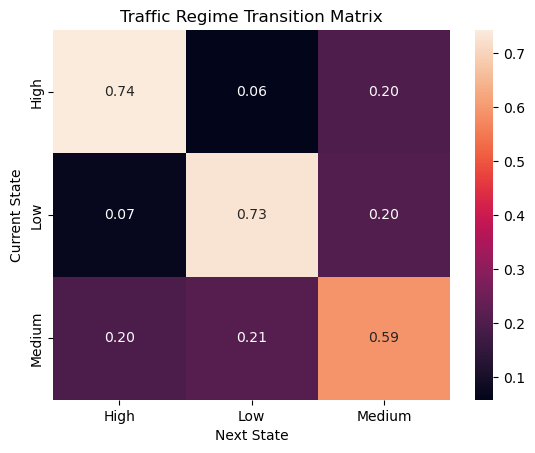

In [49]:
plt.figure()

sns.heatmap(
    transition_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Traffic Regime Transition Matrix")
plt.ylabel("Current State")
plt.xlabel("Next State")

plt.show()

**Predicting congestion 1–3 hours ahead using the Markov chain (multi-step transition probabilities), which is commonly used in traffic forecasting systems**

mathematical Concept --

Let $(X_t)$ denote the traffic state at hour $(t)$, with states:

$$\text{Low}, \text{Medium}, \text{High}$$

The 1-step transition matrix is:

$$P = 
\begin{bmatrix}
P_{Low \to Low} & P_{Low \to Medium} & P_{Low \to High} \\
P_{Medium \to Low} & P_{Medium \to Medium} & P_{Medium \to High} \\
P_{High \to Low} & P_{High \to Medium} & P_{High \to High} 
\end{bmatrix}$$

The probability of transitioning from state $(i)$ to state $(j)$ in $(n)$ hours is:

$$P^{(n)}_{ij} = \Pr(X_{t+n} = j \mid X_t = i)$$

Where the $(n)$-step transition matrix is obtained by matrix multiplication:

$$P^{(n)} = P \cdot P \cdot \ldots \cdot P \quad (n \text{ times}) = P^n$$

For example, the probability of **high congestion** after $(n)$ hours given current state $(i)$ is:

$$Pr(X_{t+n} = \text{High} \mid X_t = i) = P^{(n)}_{i, \text{High}}$$

In [50]:
import pandas as pd
import numpy as np

# Define traffic states
states = ["Low", "Medium", "High"]

# Function to compute n-step transition
def multi_step_transition(P, n):
    return np.linalg.matrix_power(P.values, n)

# Predict congestion probabilities 1-3 hours ahead (High state)
for n in [1,2,3]:
    Pn_morning = multi_step_transition(morning_matrix, n)
    Pn_evening = multi_step_transition(evening_matrix, n)
    
    df_morning = pd.DataFrame(Pn_morning, columns=states, index=states)
    df_evening = pd.DataFrame(Pn_evening, columns=states, index=states)
    
    print(f"\nMorning - {n}-hour ahead probability of congestion (High):")
    print(df_morning['High'])
    
    print(f"\nEvening - {n}-hour ahead probability of congestion (High):")
    print(df_evening['High'])



Morning - 1-hour ahead probability of congestion (High):
Low       0.276596
Medium    0.282392
High      0.506772
Name: High, dtype: float64

Evening - 1-hour ahead probability of congestion (High):
Low       0.142380
Medium    0.200876
High      0.531680
Name: High, dtype: float64

Morning - 2-hour ahead probability of congestion (High):
Low       0.340644
Medium    0.345280
High      0.394386
Name: High, dtype: float64

Evening - 2-hour ahead probability of congestion (High):
Low       0.199962
Medium    0.266059
High      0.365523
Name: High, dtype: float64

Morning - 3-hour ahead probability of congestion (High):
Low       0.355815
Medium    0.358767
High      0.368794
Name: High, dtype: float64

Evening - 3-hour ahead probability of congestion (High):
Low       0.225967
Medium    0.284607
High      0.306247
Name: High, dtype: float64


Plot showing how congestion probability evolves for each state over 3 hours:

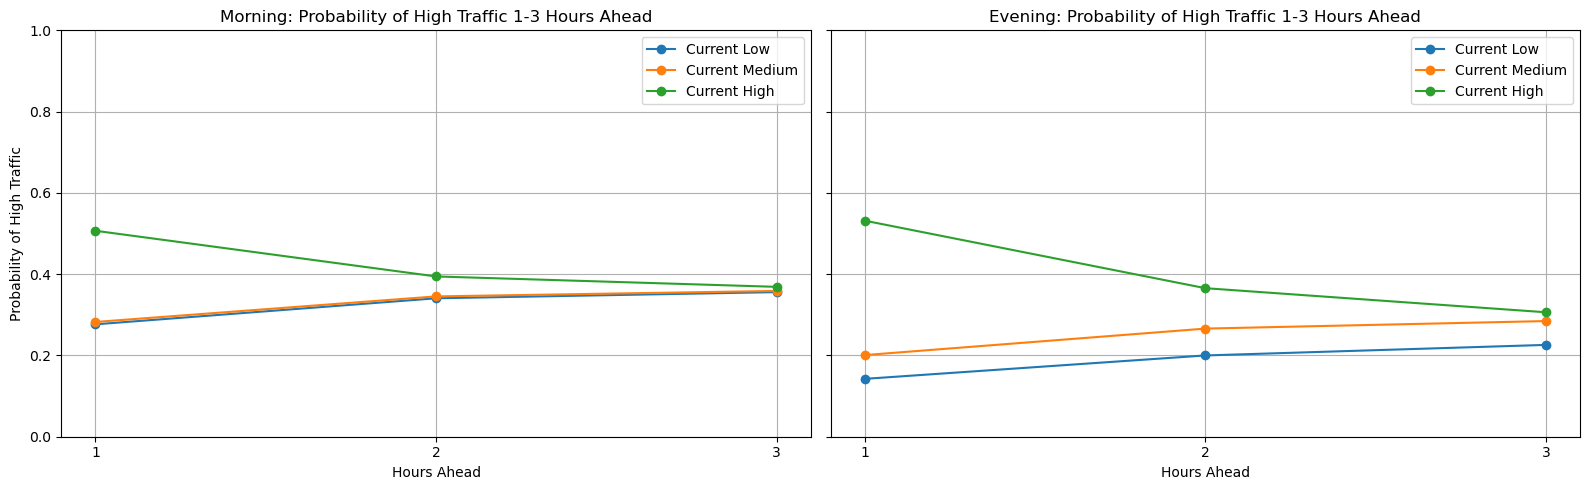

In [51]:
import matplotlib.pyplot as plt

# Initialize storage for multi-step probabilities
horizon = [1, 2, 3]  # 1-3 hours ahead
morning_probs = {state: [] for state in states}
evening_probs = {state: [] for state in states}

# Compute n-step transition probabilities
for n in horizon:
    Pn_morning = multi_step_transition(morning_matrix, n)
    Pn_evening = multi_step_transition(evening_matrix, n)
    
    df_morning = pd.DataFrame(Pn_morning, columns=states, index=states)
    df_evening = pd.DataFrame(Pn_evening, columns=states, index=states)
    
    # Store probability of ending in High traffic
    for state in states:
        morning_probs[state].append(df_morning.loc[state]['High'])
        evening_probs[state].append(df_evening.loc[state]['High'])

# Convert to DataFrames for plotting
df_morning_plot = pd.DataFrame(morning_probs, index=horizon)
df_evening_plot = pd.DataFrame(evening_probs, index=horizon)

# Plot combined subplots
fig, axes = plt.subplots(1, 2, figsize=(16,5), sharey=True)

# Morning
for state in states:
    axes[0].plot(horizon, df_morning_plot[state], marker='o', label=f'Current {state}')
axes[0].set_title("Morning: Probability of High Traffic 1-3 Hours Ahead")
axes[0].set_xlabel("Hours Ahead")
axes[0].set_ylabel("Probability of High Traffic")
axes[0].set_xticks(horizon)
axes[0].set_ylim(0,1)
axes[0].grid(True)
axes[0].legend()

# Evening
for state in states:
    axes[1].plot(horizon, df_evening_plot[state], marker='o', label=f'Current {state}')
axes[1].set_title("Evening: Probability of High Traffic 1-3 Hours Ahead")
axes[1].set_xlabel("Hours Ahead")
axes[1].set_xticks(horizon)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

Plot that includes Medium and Low traffic probabilities simultaneously:

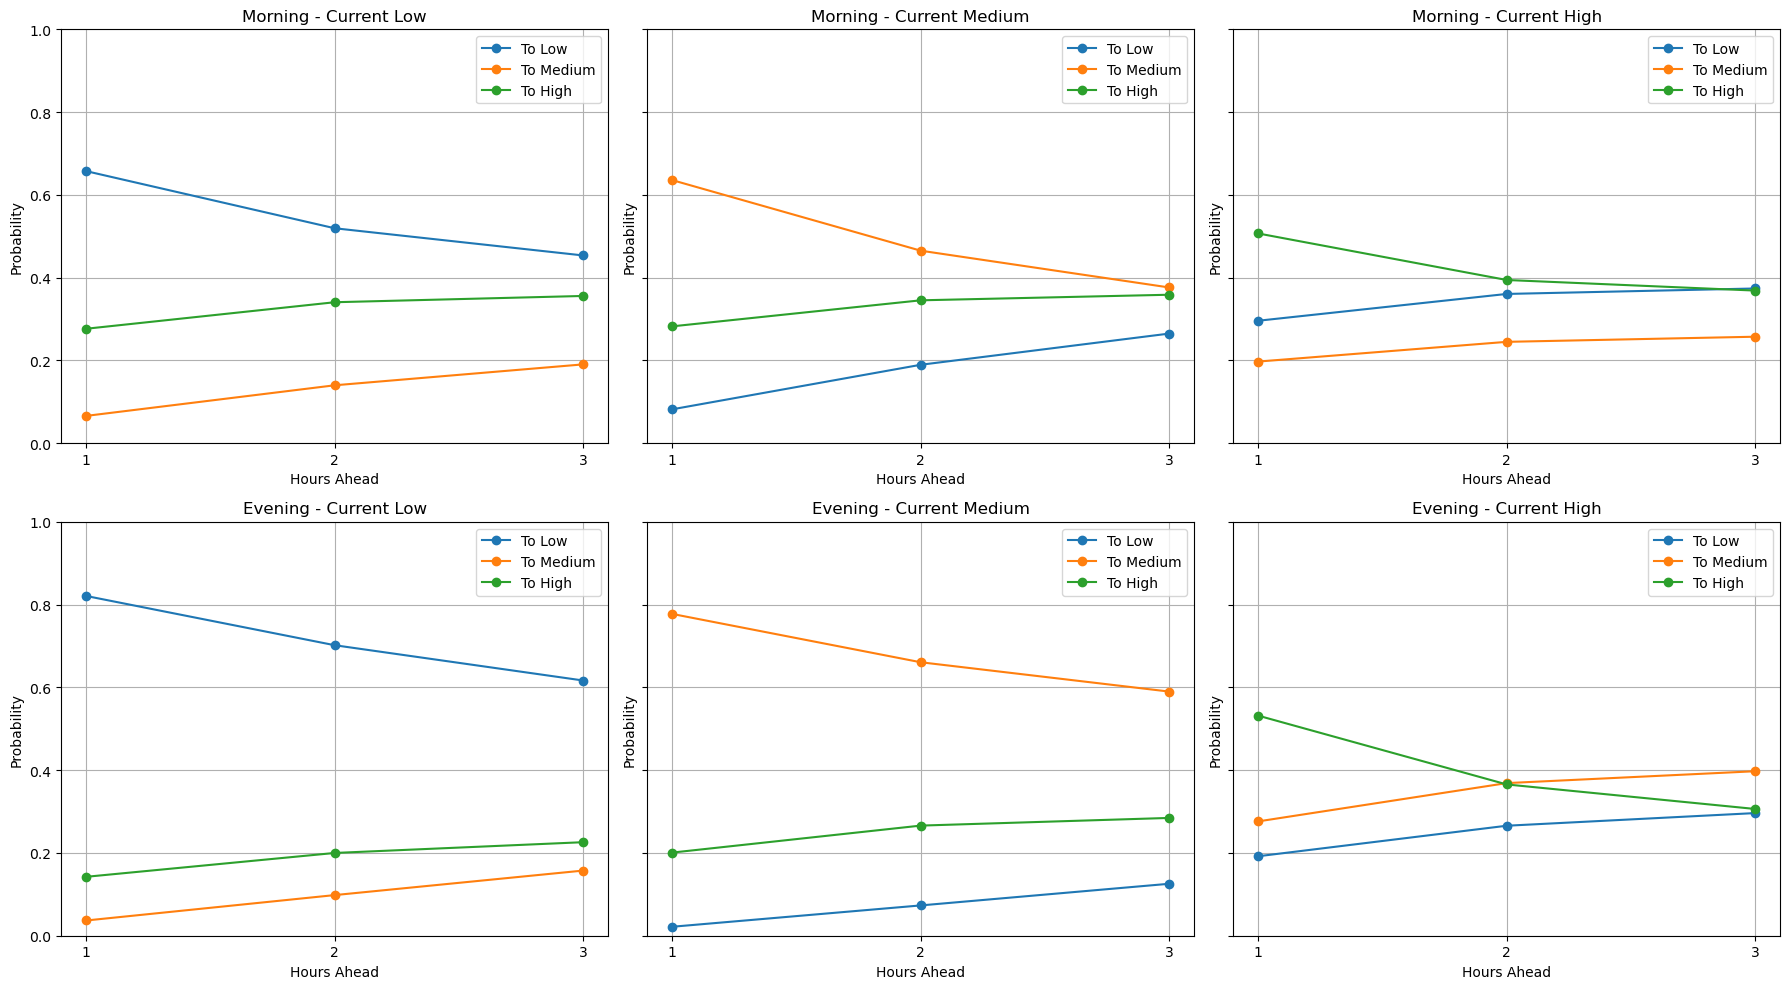

In [52]:
import matplotlib.pyplot as plt

# Initialize storage for all states transitions
morning_probs_full = {state: {target: [] for target in states} for state in states}
evening_probs_full = {state: {target: [] for target in states} for state in states}

# Compute n-step transition probabilities for all outcomes
for n in horizon:
    Pn_morning = multi_step_transition(morning_matrix, n)
    Pn_evening = multi_step_transition(evening_matrix, n)
    
    df_morning = pd.DataFrame(Pn_morning, columns=states, index=states)
    df_evening = pd.DataFrame(Pn_evening, columns=states, index=states)
    
    for state in states:
        for target in states:
            morning_probs_full[state][target].append(df_morning.loc[state, target])
            evening_probs_full[state][target].append(df_evening.loc[state, target])

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(18,10), sharey=True)
axes = axes.flatten()

plot_idx = 0
for period, probs_full, title_prefix in [("Morning", morning_probs_full, "Morning"), 
                                        ("Evening", evening_probs_full, "Evening")]:
    for state in states:
        for target in states:
            axes[plot_idx].plot(horizon, probs_full[state][target], marker='o', label=f'To {target}')
        axes[plot_idx].set_title(f"{title_prefix} - Current {state}")
        axes[plot_idx].set_xlabel("Hours Ahead")
        axes[plot_idx].set_ylabel("Probability")
        axes[plot_idx].set_xticks(horizon)
        axes[plot_idx].set_ylim(0,1)
        axes[plot_idx].grid(True)
        axes[plot_idx].legend()
        plot_idx += 1

plt.tight_layout()
plt.show()

Heatmaps that exhibit the probability of ending up in each traffic state over the 1–3 hour horizon, separately for morning and evening:

Each heatmap will have:

1. Rows: Current traffic state (Low, Medium, High)

2. Columns: Hours ahead (1, 2, 3)

3. Cell values: Probability of ending up in the given state

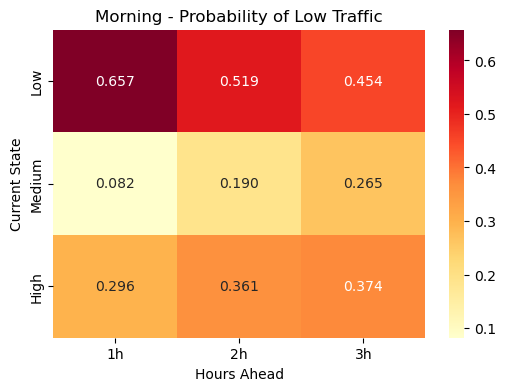

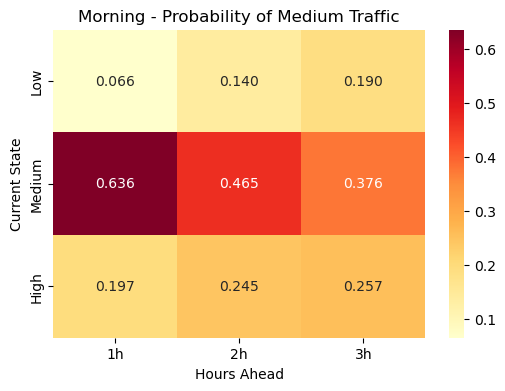

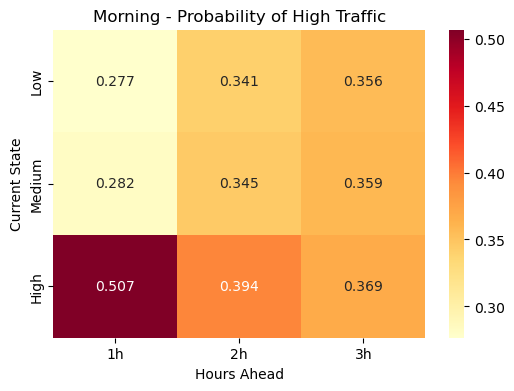

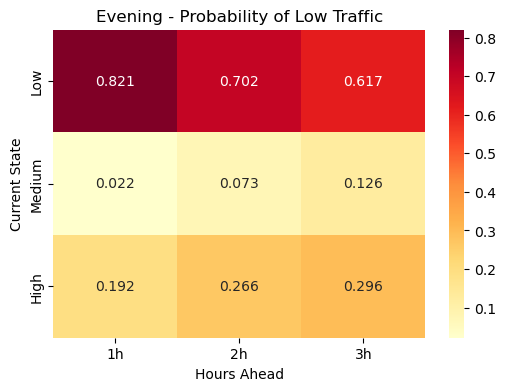

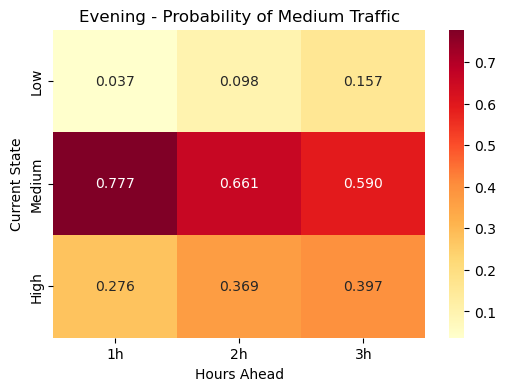

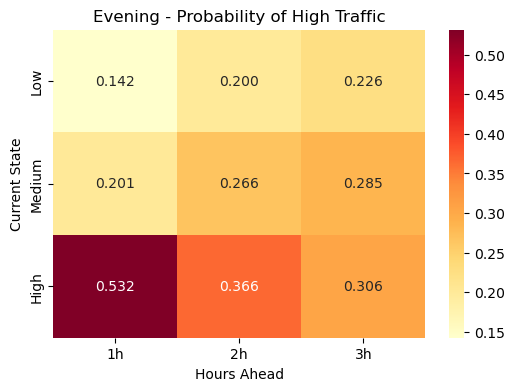

In [53]:
def plot_heatmap(probs_full, period_name):
    horizon = [1, 2, 3]
    # Prepare data for heatmap
    for target_state in states:
        heat_data = pd.DataFrame(
            {f"{h}h": [probs_full[curr][target_state][h-1] for curr in states] 
             for h in horizon},
            index=states
        )
        
        plt.figure(figsize=(6,4))
        sns.heatmap(heat_data, annot=True, fmt=".3f", cmap="YlOrRd")
        plt.title(f"{period_name} - Probability of {target_state} Traffic")
        plt.ylabel("Current State")
        plt.xlabel("Hours Ahead")
        plt.show()

# Morning heatmaps
plot_heatmap(morning_probs_full, "Morning")

# Evening heatmaps
plot_heatmap(evening_probs_full, "Evening")

**Hidden Markov Models - permits latent traffic regimes**

Applying a Hidden Markov Model (HMM) to traffic count data in order to identify latent traffic regimes (e.g., low, medium, and high congestion) and model the probabilistic transitions between these regimes over time.

Unlike a simple time-series model, the HMM assumes that the observed traffic counts are generated from unobserved hidden states, each characterised by a different statistical distribution (Rabiner, 1989) . The model therefore decomposes the traffic series into regime-dependent patterns, allowing both state identification and future state probability forecasting.

The model assumes observations follow state-dependent Gaussian distributions.

Traffic counts are converted to a 2-D NumPy array required by the HMM:

$$X=[x_1\,,x_1\,,...,\,x_T]$$

where $x_t$ is the observed traffic volume at time $t$.

The system is assumed to have three latent regimes:

1. Low traffic

2. Medium traffic

3. High traffic

The model estimates:

1. Initial state probabilities

$$\pi_i\,=\,P(S_1=i)$$

2. State transition matrix

$$A_{ij}\,=\,P(S_{t+1}=j\,|\,S_t=i)$$

3. State-dependent Gaussian parameters

$$x_t\,|\,S_t=i\sim\,N(\mu\,,\sigma_{i}^2)$$

These parameters are estimated using the Baum–Welch algorithm, a special case of EM.

Hiiden State Inference:

The Viterbi algorithm determines the most likely hidden state sequence --

$$\hat{S}_{1:T}=\text{arg max}\,P(S_{1:T}\,|\,X_{1:T})$$

Each observation is therefore classified into a traffic regime.

Regime Characterisation:

For each state $i$ --

$$\mu_i=E[X\,|\,S=i]$$

$$\sigma_i=\sqrt{Var(X\,|\,S=i)}$$

These statistics identify whether the regime corresponds to low, medium, or high traffic.

Transition Matrix:

The matrix

$$A = \begin{pmatrix}
    P_{11} & P_{12} & P_{13} \\
    P_{21} & P_{22} & P_{23} \\
    P_{31} & P_{32} & P_{33}
\end{pmatrix}
$$

represents probabilities of moving between traffic regimes.

Example interpretation:

$P_{12}=$ probability of transitioning from Low → Medium traffic

$P_{33}=$ persistence of High traffic

Multi-Step State Prediction:

Computing n-step transition probabilities:

$$A^n$$

yielding

$$P(S_{t+n}=j\,|\,S_t=i)$$

Such permits 1–3 hour ahead regime forecasts.

Regime Labelling:

States are ordered by mean traffic. Thus the hidden states are mapped to interpretable labels:

1. Low

2. Medium

3. High

Visualization:

Plotting exhibits

1. Observed traffic counts

2. Background patches representing regimes

Each shaded region represents a contiguous period of a given hidden state. This produces a regime-switching visualization where traffic dynamics are interpreted as transitions between latent states.

This framework allows:

1. identification of latent traffic regimes

2. estimation of regime persistence

3. probabilistic forecasting of congestion states

4. visual interpretation of traffic dynamics over time

Hidden State 0: mean=2405.1, std=1025.5
Hidden State 1: mean=6376.8, std=1737.3
Hidden State 2: mean=505.3, std=327.2
HMM Transition Matrix:
[[9.20522286e-01 1.74704928e-02 6.20072215e-02]
 [7.12988299e-02 9.22888814e-01 5.81235580e-03]
 [8.92085202e-02 1.37527897e-09 9.10791478e-01]]
From state 0, 1-hour ahead: [0.92052229 0.01747049 0.06200722]
From state 0, 2-hour ahead: [0.85413848 0.0322053  0.11365622]
From state 0, 3-hour ahead: [0.79868881 0.04464413 0.15666706]
From state 1, 1-hour ahead: [0.07129883 0.92288881 0.00581236]
From state 1, 2-hour ahead: [0.13195157 0.85296939 0.01507904]
From state 1, 3-hour ahead: [0.18362526 0.78950117 0.02687358]
From state 2, 1-hour ahead: [8.92085202e-02 1.37527897e-09 9.10791478e-01]
From state 2, 2-hour ahead: [0.16336879 0.00155852 0.83507269]
From state 2, 3-hour ahead: [0.22499133 0.00429247 0.77071619]


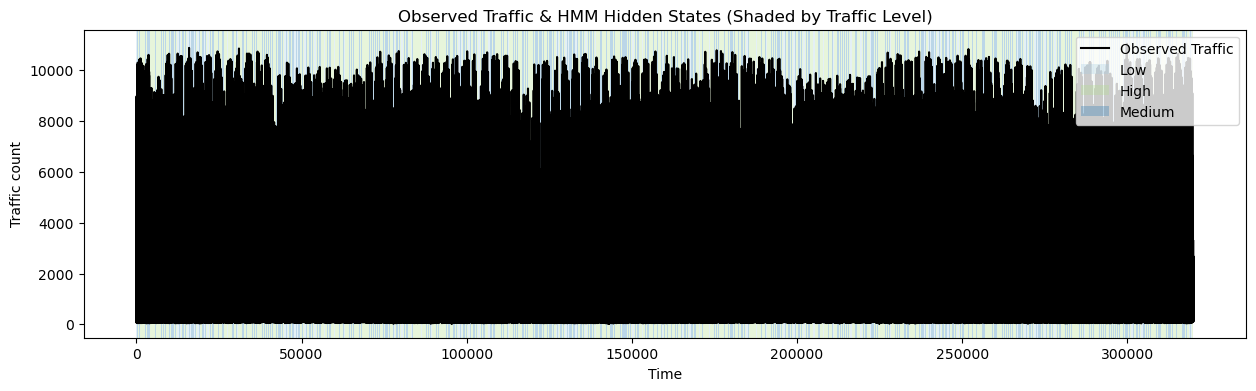

In [54]:
from hmmlearn.hmm import GaussianHMM

# Ensure traffic counts are in a numeric array
traffic_values = df_mm["total_vehicles"].values.reshape(-1,1)

# Define number of latent regimes (e.g., 3: Low, Medium, High)
n_hidden_states = 3

# Fitting the HMM
# covariance_type="diag" assumes independent variance per regime
# n_iter = max iterations for EM convergence
hmm_model = GaussianHMM(
    n_components=n_hidden_states,
    covariance_type="diag",
    n_iter=1000,
    random_state=42,
    init_params=""   # prevents overwriting
)

hmm_model.fit(traffic_values)

# Predicting hidden states
# hidden_state column now labels each observation with the most likely latent regime.
hidden_states = hmm_model.predict(traffic_values)
df_mm['hidden_state'] = hidden_states

# Inspect regime characteristics
for i in range(n_hidden_states):
    state_mean = traffic_values[hidden_states==i].mean()
    state_std  = traffic_values[hidden_states==i].std()
    print(f"Hidden State {i}: mean={state_mean:.1f}, std={state_std:.1f}")
       # This tells which latent state corresponds roughly to Low, Medium, or High traffic.

# Transition probability matrix
# Each row i shows the probability of moving from hidden state i → j.
# Can be used for 1-3 step ahead predictions similar to the Markov Chain.
print("HMM Transition Matrix:")
print(hmm_model.transmat_)

# Multi-step Prediction Using HMM
def hmm_multi_step_probs(transmat, start_state, steps=3):
    """Compute n-step ahead probability vector starting from a hidden state"""
    P = np.linalg.matrix_power(transmat, steps)
    return P[start_state]

# Example: probability of ending in each latent state 1-3 hours ahead from state 0
for s in range(3):
    for h in [1,2,3]:
        probs = hmm_multi_step_probs(hmm_model.transmat_, s, h)
        print(f"From state {s}, {h}-hour ahead: {probs}")

# PLOTTING SCHEME...........

# Mapping hidden states to traffic labels (Low, Medium, High)
state_means = [df_mm['total_vehicles'][df_mm['hidden_state']==i].mean() 
               for i in range(n_hidden_states)]
state_labels_ordered = ['Low', 'Medium', 'High']
# Sorting states by mean traffic to assign labels
mapping = {i: state_labels_ordered[np.argsort(state_means)[i]] 
           for i in range(n_hidden_states)}
df_mm['state_label'] = df_mm['hidden_state'].map(mapping)

# Assigning colors to each traffic label
label_colors = {'Low':'#a6cee3', 'Medium':'#1f78b4', 'High':'#b2df8a'}

# Plotting traffic counts and shaded patches
plt.figure(figsize=(15,4))
plt.plot(df_mm['total_vehicles'], label='Observed Traffic', color='black')

# Plotting background patches for contiguous hidden states
current_label = df_mm['state_label'].iloc[0]
start_idx = 0

for i in range(1, len(df_mm)):
    if df_mm['state_label'].iloc[i] != current_label:
        plt.axvspan(start_idx, i, facecolor=label_colors[current_label], alpha=0.3, label=current_label)
        start_idx = i
        current_label = df_mm['state_label'].iloc[i]

# Filling the last segment
plt.axvspan(start_idx, len(df_mm)-1, facecolor=label_colors[current_label], alpha=0.3, label=current_label)

# Avoiding duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right')

plt.title("Observed Traffic & HMM Hidden States (Shaded by Traffic Level)")
plt.ylabel("Traffic count")
plt.xlabel("Time")
plt.show()


## Machine Learning - Urban (NYC) Traffic Anomaly Detection

Core Concept of Anomaly Detection --

**Anomaly Detection** (also known as outlier detection) is the process of identifying data points, events, or observations that deviate significantly from the "norm" of a dataset.

**Types of Anomalies**

Anomalies generally fall into three categories:

1. Point Anomalies: A single data point is far off from the rest.

       Example: A $5,000 credit card purchase when your usual spending is $20–$50.

2. Contextual Anomalies: The data point is normal in general, but "weird" in a specific context.

       Example: 80°F (27°C) is normal in July, but it is an anomaly in New York City in January.

3. Collective Anomalies: A sequence of data points looks strange together, even if individually they seem fine.

       Example: A computer processor staying at 70% usage for 24 hours straight might indicate a background hack, even though 70% is a "normal" operating level for short bursts.

Concerning urban traffic anomaly detection,  the best method depends heavily on the structure of traffic data, which has unique characteristics:

1. Strong daily and weekly seasonality

2. Non-stationary patterns (rush hours)

3. Spatial dependencies (bridges affect each other)

4. Heavy-tailed spikes during events

5. Often no labeled anomalies

**What Makes Traffic Anomalies Hard?**

Typical traffic anomalies include:

1. accidents 

2. severe weather 

3. protests or events 

4. infrastructure closures

5. lockdowns

6. sensor failures

Yet, traffic is naturally volatile, so naive models flag too many false positives.

Example:

1. The 8 AM congestion ≠ anomaly

2. The 3 AM gridlock = anomaly

So seasonality-aware models are critical.



### Hybrid Traffic Anomaly Detection Pipeline

#### Step 1 — Remove Predictable Traffic Patterns

Using **Multiple Seasonal-Trend decomposition using Loess (MSTL)**, the traffic time series is decomposed as

$$
Traffic_t =
Trend_t +
Seasonality_{24,t} +
Seasonality_{168,t} +
Residual_t
$$

where

- $Trend_t$ represents the long-term traffic trend  
- $Seasonality_{24,t}$ captures the **daily cycle (24 hours)**  
- $Seasonality_{168,t}$ captures the **weekly cycle (168 hours)**  
- $Residual_t$ represents irregular fluctuations  

This decomposition removes predictable traffic patterns such as **rush-hour effects**.

---

#### Step 2 — Detect Extreme Deviations

Anomalies are first detected using the **Median Absolute Deviation (MAD)**.

The MAD is defined as

$$
MAD = \text{median}(|Residual_t - \text{median}(Residual)|)
$$

A **robust z-score** is computed as

$$
z_t = 0.6745 \frac{Residual_t - \text{median}(Residual)}{MAD}
$$

An observation is flagged as a potential anomaly if

$$
|z_t| > 3
$$

This step detects **large deviations in residual traffic**.

---

#### Step 3 — Confirm Anomalies

To ensure anomalies are statistically extreme, an **Interquartile Range (IQR)** filter is applied.

$$
IQR = Q_3 - Q_1
$$

where

- $Q_1$ is the first quartile  
- $Q_3$ is the third quartile  

The anomaly bounds are

$$
Lower = Q_1 - 1.5 \times IQR
$$

$$
Upper = Q_3 + 1.5 \times IQR
$$

Residual values outside this interval are flagged as anomalies.

---

#### Step 4 — Hybrid Anomaly Decision

The final anomaly classification combines both detection methods

$$
Anomaly =
MAD_{flag} \cap IQR_{flag}
$$

where

- $MAD_{flag}$ indicates anomalies detected using MAD  
- $IQR_{flag}$ indicates anomalies detected using IQR  

This hybrid approach significantly reduces **false positives in traffic anomaly detection**.

Typical traffic anomalies detected:

| Event              | Signal                    |
| ------------------ | ------------------------- |
| Accident           | sudden traffic spike      |
| Storm              | large residual deviations |
| Protest            | localised congestion      |
| Road closure       | sudden traffic drop       |
| Sensor malfunction | extreme outlier           |

Choice of facility is 30 = Verrazano-Narrows Bridge (VNB) since it's the most dominant facility based on earlier share analysis, and thus can be characterised as the most "urban" facility based on such. 

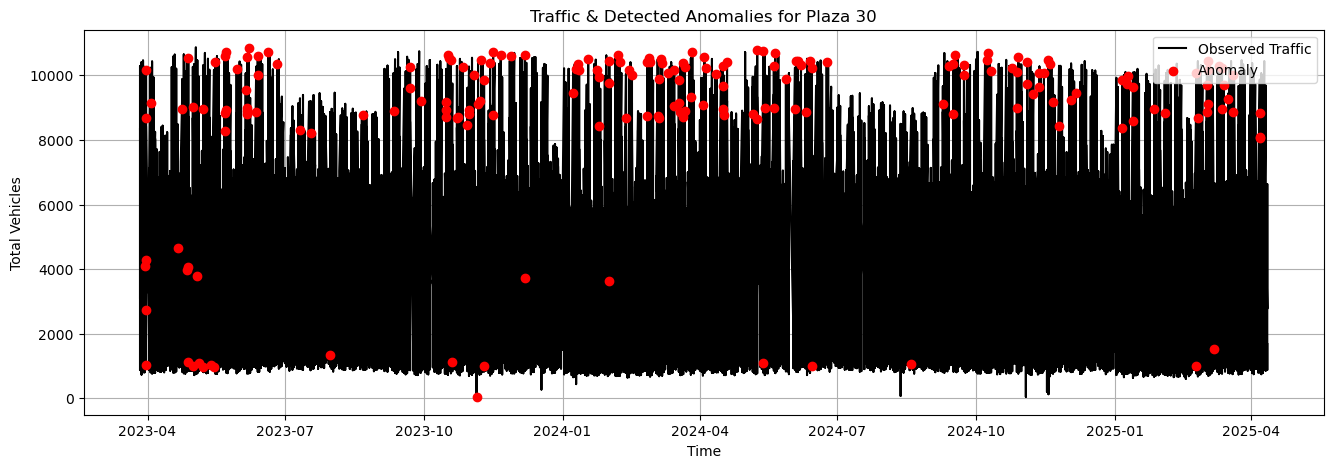

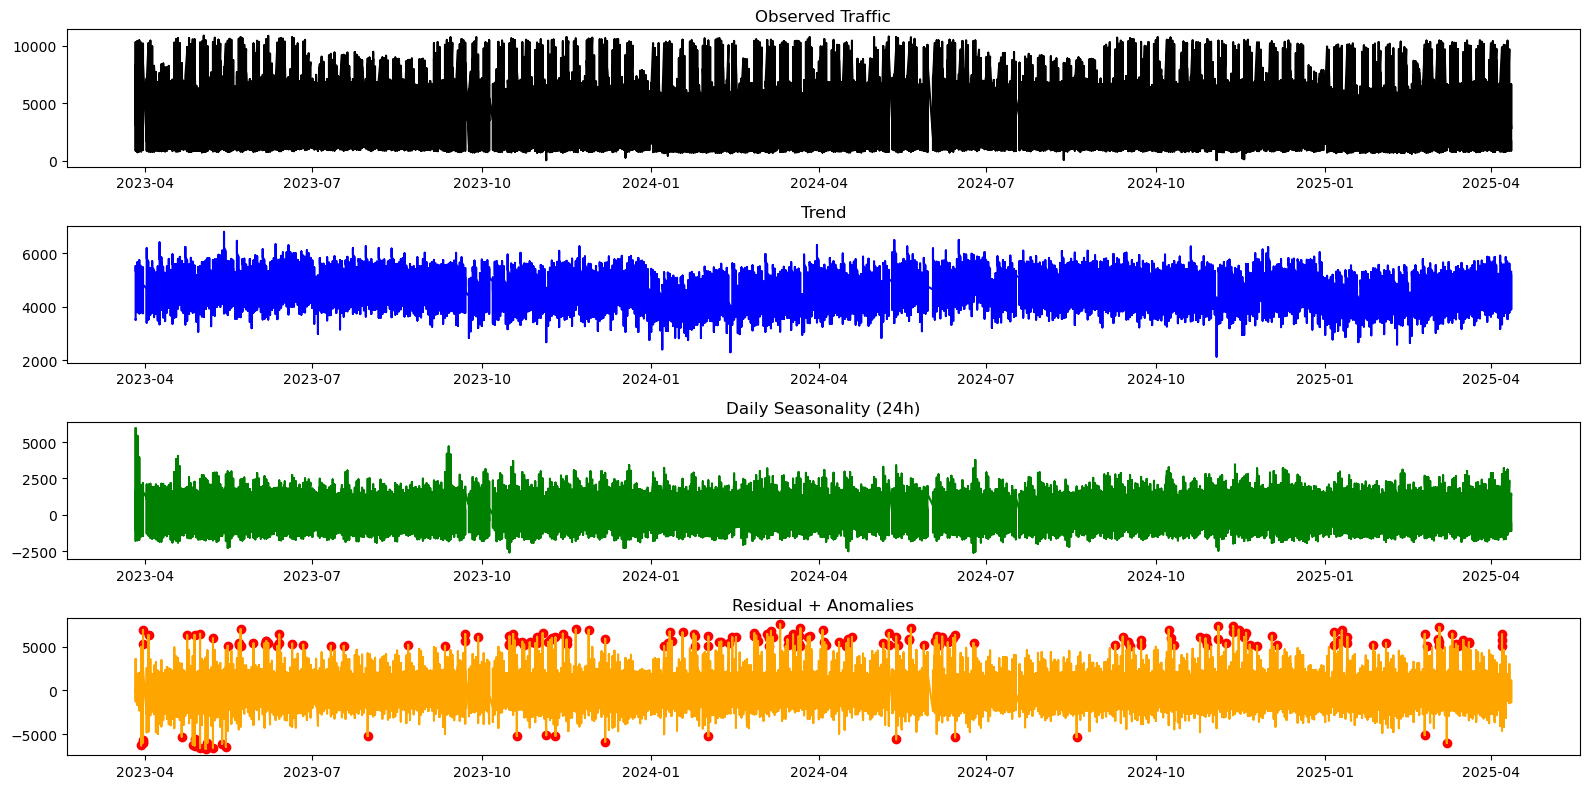

Number of anomalies detected: 193


In [55]:
from statsmodels.tsa.seasonal import STL

anom_data = stochas_data.copy()
# -------------------------------
# Selecting Facility
# -------------------------------
facility_col = "plaza_id"
facility_id = 30  # chosen facility being the Verrazano-Narrows Bridge (VNB)

facility_df = anom_data[anom_data[facility_col] == facility_id].copy()
facility_df = facility_df.sort_values("date")
facility_df = facility_df.reset_index(drop=True)

traffic_series = facility_df["total_vehicles"]

# -------------------------------
# MSTL Decomposition (STL Approximation)
# -------------------------------
# Using STL for daily + weekly seasonality via sequential decomposition
# First: Daily (24h)
stl_daily = STL(traffic_series, period=24, robust=True)
res_daily = stl_daily.fit()
detrended_daily = traffic_series - res_daily.trend

# Second: Weekly (168h)
stl_weekly = STL(detrended_daily, period=168, robust=True)
res_weekly = stl_weekly.fit()
residual = res_weekly.resid  # final residual traffic

# Store decomposed components for plotting
facility_df["trend"] = res_weekly.trend + res_daily.trend
facility_df["seasonal_24"] = res_daily.seasonal
facility_df["seasonal_168"] = res_weekly.seasonal
facility_df["residual"] = residual

# -------------------------------
# MAD Robust Z-Score Anomaly Detection
# -------------------------------
median_resid = np.median(residual)
mad_resid = np.median(np.abs(residual - median_resid))
robust_z = 0.6745 * (residual - median_resid) / mad_resid

mad_threshold = 3  # typical threshold
facility_df["MAD_flag"] = (np.abs(robust_z) > mad_threshold)

# -------------------------------
# IQR Filter
# -------------------------------
Q1 = np.percentile(residual, 25)
Q3 = np.percentile(residual, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

facility_df["IQR_flag"] = (residual < lower_bound) | (residual > upper_bound)

# -------------------------------
# Hybrid Anomaly Flag
# -------------------------------
facility_df["anomaly"] = facility_df["MAD_flag"] & facility_df["IQR_flag"]

# -------------------------------
# Plotting
# -------------------------------
plt.figure(figsize=(16,5))
plt.plot(facility_df["date"], traffic_series, color="black", label="Observed Traffic")

# Shade anomalies
anomaly_indices = facility_df.index[facility_df["anomaly"]]
plt.scatter(facility_df["date"].iloc[anomaly_indices],
            traffic_series.iloc[anomaly_indices],
            color="red", label="Anomaly", zorder=5)

plt.title(f"Traffic & Detected Anomalies for Plaza {facility_id}")
plt.xlabel("Time")
plt.ylabel("Total Vehicles")
plt.legend()
plt.grid(True)
plt.show()

# Optional: plot decomposition
plt.figure(figsize=(16,8))
plt.subplot(4,1,1)
plt.plot(facility_df["date"], traffic_series, label="Observed", color="black")
plt.title("Observed Traffic")

plt.subplot(4,1,2)
plt.plot(facility_df["date"], facility_df["trend"], label="Trend", color="blue")
plt.title("Trend")

plt.subplot(4,1,3)
plt.plot(facility_df["date"], facility_df["seasonal_24"], label="Daily Seasonality", color="green")
plt.title("Daily Seasonality (24h)")

plt.subplot(4,1,4)
plt.plot(facility_df["date"], residual, label="Residual", color="orange")
plt.scatter(facility_df["date"].iloc[anomaly_indices],
            residual.iloc[anomaly_indices],
            color="red", label="Anomaly")
plt.title("Residual + Anomalies")
plt.tight_layout()
plt.show()

# -------------------------------
# ✅ Facility 30 -Verrazano-Narrows Bridge (VNB) anomalies detected
# -------------------------------
print(f"Number of anomalies detected: {facility_df['anomaly'].sum()}")

### Matching Extreme Weather Events with Anomalies

To compare traffic anomalies and weather events without merging the dataframes — just to see which weather dates coincide with traffic anomalies. To do such sans merging dataframes to avoid dealing with arduous data orientation messes. 

Since both dataframes have a date column, to do a **set-based comparison**, which is clean, avoids merges, and is easy to inspect.

In [56]:

# -------------------------------
# Extracting relevant dates
# -------------------------------
# Dates where traffic anomaly occurred (True)
anomaly_dates = set(facility_df.loc[facility_df['anomaly'] == True, 'date'])

# Dates where extreme weather event occurred (event_observed == 1)
event_dates = set(survival_data.loc[survival_data['event_observed'] == 1, 'date'])

# -------------------------------
# Finding intersection
# -------------------------------
matching_dates = anomaly_dates & event_dates

print(f"Number of matching dates: {len(matching_dates)}")

# -------------------------------
# Flagging in traffic dataframe for matching
# -------------------------------
facility_df['anomaly_weather_match'] = facility_df['date'].isin(matching_dates)


Number of matching dates: 38


In [57]:
# Convert matching dates to (neat) DataFrame
df_matching = pd.DataFrame({'matching_date': sorted(matching_dates)})

# Optional: reset index for neat numbering
df_matching.index += 1  # start index at 1

# Display
print(f"Number of matching dates: {len(df_matching)}")
print(df_matching)

Number of matching dates: 38
   matching_date
1     2023-04-24
2     2023-05-01
3     2023-06-05
4     2023-06-06
5     2023-06-07
6     2023-06-12
7     2023-06-13
8     2023-06-26
9     2023-10-16
10    2023-10-17
11    2023-10-20
12    2023-11-28
13    2024-01-08
14    2024-01-10
15    2024-01-11
16    2024-01-12
17    2024-01-25
18    2024-02-12
19    2024-02-14
20    2024-02-16
21    2024-02-28
22    2024-03-07
23    2024-03-11
24    2024-03-15
25    2024-05-09
26    2024-06-05
27    2024-08-19
28    2024-10-08
29    2024-10-09
30    2024-11-12
31    2024-11-18
32    2024-11-19
33    2024-11-21
34    2024-11-25
35    2025-01-09
36    2025-01-10
37    2025-02-25
38    2025-03-08


Checking/reviewing the different outlier types:

In [58]:
outlier_unique = survival_data['outlier_type'].unique()

outlier_type_unq

array([0., 8., 3., 7.])

Identification of the outlier types and reasoning for the observed failure in matches:

3: "Potential storm system: pressure ≤ 1016 hPa and 30-day mean > 1016 hPa"

7: "Extreme wind gusts: gust ≥ 70 km/h and 30-day mean < 70 km/h"

8:  "Heavy fog: RH ≥ 97%, temperature–dewpoint spread ≤ 2°C, wind ≤ 10 km/h",

There are 38 dates where traffic anomalies coincide with extreme weather events.

Proportion of traffic anomalies explained by weather:

1. If facility_df has, say, 193 total anomalies, then $38/198 \approx 20\%$ occurred on days with extreme weather.

2. This conveys that weather explains only a subset of anomalies — other causes might include accidents, special events, or unusual congestion patterns.

Temporal patterns (observation of the distribution of dates):

    Being a method to observe seasonal clustering


**NOTE:** this result only concerns one facility.

In [59]:
df_matching['matching_date'].dt.month.value_counts().sort_index()

matching_date
1     7
2     5
3     4
4     1
5     2
6     7
8     1
10    5
11    6
Name: count, dtype: int64

Seasonal "clusters"

1. Winter–early spring: Jan (7), Feb (5), Mar (4) → winter storms or cold-weather impacts.

2. Late spring–early summer: Apr (1), May (2), Jun (7) → maybe fog events or storms.

3. Fall: Oct (5), Nov (6) → maybe fog or high wind gusts; both can't co-exist however.

4. Gaps: July (0), August (1), September (0) → fewer extreme weather–driven anomalies in peak summer months. Most likely a storm.

For confirmation, identify the dates with outlier_types in survival_data.

**NOTE:** this result only concerns one facility.

Consecutive days:

    Consecutive days might indicate extended weather events or systematic traffic disruptions.


**COMPREHENSION:** an extreme weather event is not an absolute condition to influence traffic. Weather activity subpar to extreme weather events (typical elevated weather behaviour in a season) can also influence traffic. It may be the case that extensive road planning/oversight was applied to mitigate considerable traffic disruptions. As well, for common elevated weather (not identified as extreme weather events) for a respective season, it may be the case that the influence of such weather may have been underestimated. Any storm-like event (identified with atmospheric lower pressure conditions) is possible.

**NOTE:** this result only concerns one facility.

Bar plot of month vs count of matching dates and Timeline plot of all traffic anomalies with weather overlay:

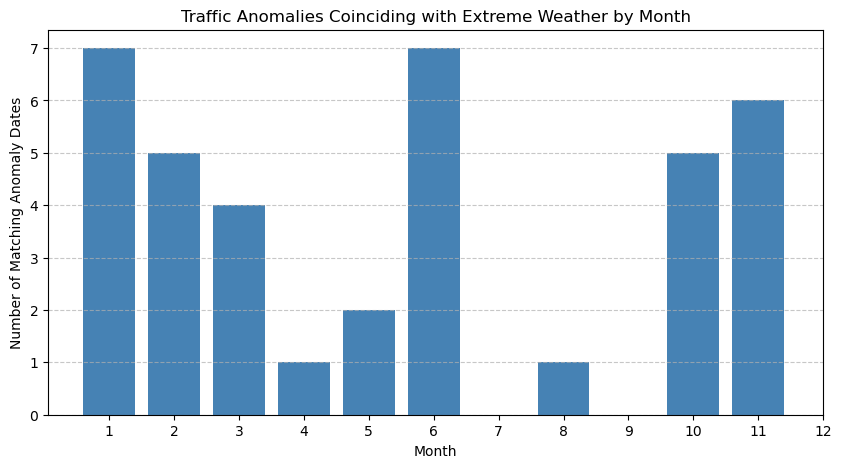

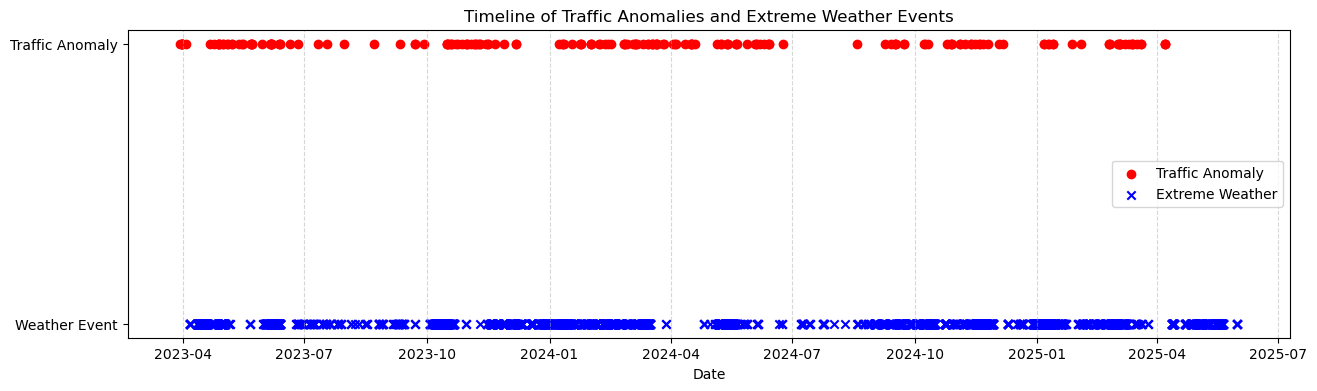

In [60]:

# -------------------------------
# Bar plot: month vs count of matching dates
# -------------------------------

# Extract month
df_matching['month'] = df_matching['matching_date'].dt.month

# Count per month
monthly_counts = df_matching['month'].value_counts().sort_index()

# Bar plot
plt.figure(figsize=(10,5))
plt.bar(monthly_counts.index, monthly_counts.values, color='steelblue')
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Number of Matching Anomaly Dates")
plt.title("Traffic Anomalies Coinciding with Extreme Weather by Month")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# Timeline plot: traffic anomalies with weather overlay
# -------------------------------
# Preparing traffic anomaly flag
facility_df['date_only'] = pd.to_datetime(facility_df['date']).dt.date
facility_df['anomaly'] = facility_df['anomaly'].astype(bool)

# Create plot
plt.figure(figsize=(15,4))

# Plotting all traffic anomalies
anomaly_dates_plot = facility_df.loc[facility_df['anomaly'], 'date_only']
plt.scatter(anomaly_dates_plot, [1]*len(anomaly_dates_plot), color='red', label='Traffic Anomaly', marker='o')

# Overlay extreme weather events
weather_dates_plot = survival_data.loc[survival_data['event_observed']==1, 'date']
plt.scatter(weather_dates_plot, [0.8]*len(weather_dates_plot), color='blue', label='Extreme Weather', marker='x')

plt.yticks([0.8, 1], ['Weather Event', 'Traffic Anomaly'])
plt.xlabel("Date")
plt.title("Timeline of Traffic Anomalies and Extreme Weather Events")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

WILL NEED TO DO COUNTERPART FOR HOLIDAYS.....see how much of the remaining can be accounted for with such feature. 

### Macthing Holiday Events with Anomalies

To compare traffic anomalies and holiday events sans merging the dataframes — just to see which holiday dates coincide with traffic anomalies. To do such sans merging dataframes to avoid dealing with arduous data orientation messes. 

Since both dataframes have a date column, to do a **set-based comparison**, which is clean, avoids merges, and is easy to inspect.

Again, choice of facility is 30 = Verrazano-Narrows Bridge (VNB) since it's the most dominant facility based on earlier share analysis, and thus can be characterised as the most "urban" facility based on such. 

In [61]:
holidays = stochas_data['holiday'].unique()

print(holidays)

[0 1]


In [62]:

# -------------------------------
# Extracting relevant dates
# -------------------------------

# Dates where holiday event occurred (event_observed == 1)
hol_event_dates = set(stochas_data.loc[stochas_data['holiday'] == 1, 'date'])

# -------------------------------
# Finding intersection
# -------------------------------
hol_matching_dates = anomaly_dates & hol_event_dates

print(f"Number of matching dates: {len(hol_matching_dates)}")

# -------------------------------
# Flagging in traffic dataframe for matching
# -------------------------------
facility_df['anomaly_holiday_match'] = facility_df['date'].isin(hol_matching_dates)


Number of matching dates: 1


In [63]:
# Convert matching dates to (neat) DataFrame
hol_df_matching = pd.DataFrame({'hol_matching_date': sorted(hol_matching_dates)})

# Optional: reset index for neat numbering
hol_df_matching.index += 1  # start index at 1

# Display
print(f"Number of matching dates: {len(hol_df_matching)}")
print(hol_df_matching)

Number of matching dates: 1
  hol_matching_date
1        2023-11-10


Such above date (Veteran's Day **observation**) doesn't match with any extreme weather event. 

"Veterans Day is on Nov. 11 every year, regardless of what day of the week it falls. **However**, it falls on a Saturday in year 2023, meaning that federal employees will observe the federal holiday the previous day, on Friday, Nov. 10, and many government services will be closed. Many schools and companies will also be closed Friday in observation of the holiday", (Vetter, 2023).

Such a day is observed with multiple activities involving the general public. Having Friday allocated for observance results in a extended weekend period. People generally exploit such time for their own benefit(s). Travel can be either excessive or minimal w.r.t. time period of the day.  

Now, for the identified traffic anomalies the causes may result from:

1. accidents 

2. severe (**not extreme**) weather 

3. protests or events (**not recognised at the federal level**) 

4. infrastructure closures

5. lockdowns

6. sensor failures


## Incorporation of Motor Vehicle Collisions - Crashes 

### Synopsis

The NYC Open Data Motor Vehicle Collisions – Crashes dataset provides detailed records of police-reported motor vehicle collisions occurring in New York City. Each record represents a single crash event and contains information about the date, time, location, injury and fatality counts, contributing factors, and vehicle types involved in the incident. The data is collected from official police crash reports (MV-104AN), which must be completed when a collision results in injury, death, or property damage exceeding $1,000.

The dataset covers collisions reported across the five boroughs—**Manhattan, Brooklyn, Queens, The Bronx, and Staten Island—and includes geographic coordinates that allow events to be mapped and analyzed spatially. The dataset is updated regularly and serves as a key resource for transportation safety analysis, urban planning, and policy initiatives such as Vision Zero, which aims to reduce traffic injuries and fatalities.

Because the dataset contains millions of records since 2012 and continues to grow through frequent updates, it is widely used for data science, machine learning, and spatial analysis projects examining crash patterns, high-risk locations, temporal trends, and the factors contributing to traffic accidents. However, the data is considered preliminary and subject to revision, as police reports may be amended when new information becomes available.


<h2>Data Dictionary: NYC Motor Vehicle Collisions – Crashes</h2>

<table border="1" style="border-collapse:collapse; width:100%;">
<thead>
<tr>
<th>Column Name</th>
<th>Type</th>
<th>Description</th>
</tr>
</thead>
<tbody>

<tr>
<td>CRASH DATE</td>
<td>Date</td>
<td>Date when the motor vehicle collision occurred.</td>
</tr>

<tr>
<td>CRASH TIME</td>
<td>Time</td>
<td>Time of day when the collision occurred.</td>
</tr>

<tr>
<td>BOROUGH</td>
<td>Categorical</td>
<td>New York City borough where the collision occurred (Bronx, Brooklyn, Manhattan, Queens, Staten Island).</td>
</tr>

<tr>
<td>ZIP CODE</td>
<td>Numeric / String</td>
<td>ZIP code of the collision location.</td>
</tr>

<tr>
<td>LATITUDE</td>
<td>Float</td>
<td>Latitude coordinate of the crash location using WGS84 geographic coordinate system.</td>
</tr>

<tr>
<td>LONGITUDE</td>
<td>Float</td>
<td>Longitude coordinate of the crash location using WGS84 geographic coordinate system.</td>
</tr>

<tr>
<td>LOCATION</td>
<td>Geospatial</td>
<td>Combined latitude and longitude point representing crash location.</td>
</tr>

<tr>
<td>ON STREET NAME</td>
<td>String</td>
<td>Name of the street where the crash occurred.</td>
</tr>

<tr>
<td>CROSS STREET NAME</td>
<td>String</td>
<td>Name of the intersecting street near the crash.</td>
</tr>

<tr>
<td>OFF STREET NAME</td>
<td>String</td>
<td>Name of the nearest off-street location when applicable.</td>
</tr>

<tr>
<td>NUMBER OF PERSONS INJURED</td>
<td>Integer</td>
<td>Total number of individuals injured in the crash.</td>
</tr>

<tr>
<td>NUMBER OF PERSONS KILLED</td>
<td>Integer</td>
<td>Total number of individuals killed in the crash.</td>
</tr>

<tr>
<td>NUMBER OF PEDESTRIANS INJURED</td>
<td>Integer</td>
<td>Number of pedestrians injured.</td>
</tr>

<tr>
<td>NUMBER OF PEDESTRIANS KILLED</td>
<td>Integer</td>
<td>Number of pedestrians killed.</td>
</tr>

<tr>
<td>NUMBER OF CYCLIST INJURED</td>
<td>Integer</td>
<td>Number of cyclists injured.</td>
</tr>

<tr>
<td>NUMBER OF CYCLIST KILLED</td>
<td>Integer</td>
<td>Number of cyclists killed.</td>
</tr>

<tr>
<td>NUMBER OF MOTORIST INJURED</td>
<td>Integer</td>
<td>Number of vehicle occupants injured.</td>
</tr>

<tr>
<td>NUMBER OF MOTORIST KILLED</td>
<td>Integer</td>
<td>Number of vehicle occupants killed.</td>
</tr>

<tr>
<td>CONTRIBUTING FACTOR VEHICLE 1</td>
<td>Categorical</td>
<td>Primary contributing factor for vehicle 1 in the crash (e.g., driver inattention, speeding).</td>
</tr>

<tr>
<td>CONTRIBUTING FACTOR VEHICLE 2</td>
<td>Categorical</td>
<td>Contributing factor for vehicle 2.</td>
</tr>

<tr>
<td>CONTRIBUTING FACTOR VEHICLE 3</td>
<td>Categorical</td>
<td>Contributing factor for vehicle 3.</td>
</tr>

<tr>
<td>CONTRIBUTING FACTOR VEHICLE 4</td>
<td>Categorical</td>
<td>Contributing factor for vehicle 4.</td>
</tr>

<tr>
<td>CONTRIBUTING FACTOR VEHICLE 5</td>
<td>Categorical</td>
<td>Contributing factor for vehicle 5.</td>
</tr>

<tr>
<td>COLLISION_ID / UNIQUE KEY</td>
<td>Integer</td>
<td>Unique identifier assigned to each collision record.</td>
</tr>

<tr>
<td>VEHICLE TYPE CODE 1</td>
<td>Categorical</td>
<td>Type of vehicle 1 involved (e.g., sedan, taxi, truck).</td>
</tr>

<tr>
<td>VEHICLE TYPE CODE 2</td>
<td>Categorical</td>
<td>Type of vehicle 2 involved.</td>
</tr>

<tr>
<td>VEHICLE TYPE CODE 3</td>
<td>Categorical</td>
<td>Type of vehicle 3 involved.</td>
</tr>

<tr>
<td>VEHICLE TYPE CODE 4</td>
<td>Categorical</td>
<td>Type of vehicle 4 involved.</td>
</tr>

<tr>
<td>VEHICLE TYPE CODE 5</td>
<td>Categorical</td>
<td>Type of vehicle 5 involved.</td>
</tr>

</tbody>
</table>

Will also be focusing on a time setting that's compatible with the traffic data.

In [64]:
# ==========================================
# Import libraries
# ==========================================

from sodapy import Socrata
import pandas as pd

# ==========================================
# API configuration
# ==========================================

DOMAIN = "data.cityofnewyork.us"
DATASET_ID = "h9gi-nx95"

APP_TOKEN = "j2xani8RWUxUKg6wbcSMoUif7"

# ==========================================
# Connect to Socrata API
# ==========================================

client = Socrata(
    DOMAIN,
    APP_TOKEN,
    timeout=60
)

# ==========================================
# Date filter (March 2023 – May 2025)
# ==========================================

where_clause = """
crash_date between '2023-03-01T00:00:00'
and '2025-05-31T23:59:59'
"""

# ==========================================
# Pagination setup
# ==========================================

limit = 50000
offset = 0
all_rows = []

print("Downloading collision dataset...")

# ==========================================
# Download loop
# ==========================================

while True:

    batch = client.get(
        DATASET_ID,
        where=where_clause,
        limit=limit,
        offset=offset
    )

    if len(batch) == 0:
        break

    all_rows.extend(batch)
    offset += limit

    print(f"Downloaded {len(all_rows)} rows")

# ==========================================
# Convert to pandas DataFrame
# ==========================================

collisions_df = pd.DataFrame.from_records(all_rows)

print("Download complete")
print(collisions_df.shape)
print(collisions_df.head())

Downloaded 50000 rows
Downloaded 100000 rows
Downloaded 150000 rows
Downloaded 200000 rows
Downloaded 207627 rows
Download complete
(207627, 29)
                crash_date crash_time   latitude   longitude  \
0  2023-03-01T00:00:00.000      18:33   40.62499   -74.14403   
1  2023-03-01T00:00:00.000      11:17        NaN         NaN   
2  2023-03-01T00:00:00.000      22:32   40.74608  -73.974945   
3  2023-03-01T00:00:00.000      18:21        NaN         NaN   
4  2023-03-01T00:00:00.000       9:00  40.728474  -73.882614   

                                            location          on_street_name  \
0  {'latitude': '40.62499', 'longitude': '-74.144...           FOREST AVENUE   
1                                                NaN       TRIBOROUGH BRIDGE   
2  {'latitude': '40.74608', 'longitude': '-73.974...          EAST 36 STREET   
3                                                NaN         FLATBUSH AVENUE   
4  {'latitude': '40.728474', 'longitude': '-73.88...  LONG ISLAND EXPR

In [65]:
collisions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207627 entries, 0 to 207626
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   crash_date                     207627 non-null  object
 1   crash_time                     207627 non-null  object
 2   latitude                       193767 non-null  object
 3   longitude                      193767 non-null  object
 4   location                       193767 non-null  object
 5   on_street_name                 148432 non-null  object
 6   off_street_name                107443 non-null  object
 7   number_of_persons_injured      207627 non-null  object
 8   number_of_persons_killed       207627 non-null  object
 9   number_of_pedestrians_injured  207627 non-null  object
 10  number_of_pedestrians_killed   207627 non-null  object
 11  number_of_cyclist_injured      207627 non-null  object
 12  number_of_cyclist_killed       207627 non-nu

Based on the characteritics of the data, focusing heavily on granularity and/or context(content) and demographic interests will result in heavily data loss. Additionally, the main focus for this data is count models. Hence, for now, will focus on attributes of interests that will not result in heavily data loss.

Based on the data dictionary for the NYC Motor Vehicle Collisions dataset data dictionary, the columns should be transformed into appropriate datetime, categorical, numeric, and geospatial types. 

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Selecting columns of interest
# ===============================
cols = list(collisions_df.columns[:18]) + [collisions_df.columns[-1]]
collisions_df = collisions_df[cols].copy()

# ===============================
# Dropping unwanted / high-missing columns
# ===============================
drop_cols = ['contributing_factor_vehicle_1', 'on_street_name', 'off_street_name',
             'location', 'vehicle_type_code1', 'vehicle_type_code_5']
collisions_df = collisions_df.drop(columns=[c for c in drop_cols if c in collisions_df.columns])

# ===============================
# Transforming dates and times safely
# ===============================
# Ensure crash_date is datetime
collisions_df['crash_date'] = pd.to_datetime(collisions_df['crash_date'], errors='coerce')

# Replace missing crash_time with '00:00' to prevent errors
collisions_df['crash_time'] = collisions_df['crash_time'].fillna('00:00').astype(str)

# Combine date + time into crash_datetime
collisions_df['crash_datetime'] = pd.to_datetime(
    collisions_df['crash_date'].dt.strftime('%Y-%m-%d') + ' ' + collisions_df['crash_time'],
    format='%Y-%m-%d %H:%M',
    errors='coerce'
)

# Drop rows with invalid datetime
collisions_df = collisions_df.dropna(subset=['crash_datetime'])

# ===============================
# Numeric columns
# ===============================
numeric_cols = [
    'number_of_persons_injured',
    'number_of_persons_killed',
    'number_of_pedestrians_injured',
    'number_of_pedestrians_killed',
    'number_of_cyclist_injured',
    'number_of_cyclist_killed',
    'number_of_motorist_injured',
    'number_of_motorist_killed'
]
collisions_df[numeric_cols] = collisions_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Latitude / Longitude
collisions_df['latitude'] = pd.to_numeric(collisions_df['latitude'], errors='coerce')
collisions_df['longitude'] = pd.to_numeric(collisions_df['longitude'], errors='coerce')

# ===============================
# Additional temporal features
# ===============================
collisions_df['hour'] = collisions_df['crash_datetime'].dt.hour
collisions_df['day_of_week'] = collisions_df['crash_datetime'].dt.dayofweek
collisions_df['month'] = collisions_df['crash_datetime'].dt.month
collisions_df['year'] = collisions_df['crash_datetime'].dt.year

# ===============================
# Quick sanity checks
# ===============================
print(collisions_df.shape)
print(collisions_df.columns)
collisions_df.info()

(207627, 18)
Index(['crash_date', 'crash_time', 'latitude', 'longitude',
       'number_of_persons_injured', 'number_of_persons_killed',
       'number_of_pedestrians_injured', 'number_of_pedestrians_killed',
       'number_of_cyclist_injured', 'number_of_cyclist_killed',
       'number_of_motorist_injured', 'number_of_motorist_killed',
       'collision_id', 'crash_datetime', 'hour', 'day_of_week', 'month',
       'year'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207627 entries, 0 to 207626
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   crash_date                     207627 non-null  datetime64[ns]
 1   crash_time                     207627 non-null  object        
 2   latitude                       193767 non-null  float64       
 3   longitude                      193767 non-null  float64       
 4   number_of_persons_injured 

Some Graphical exhibitions:

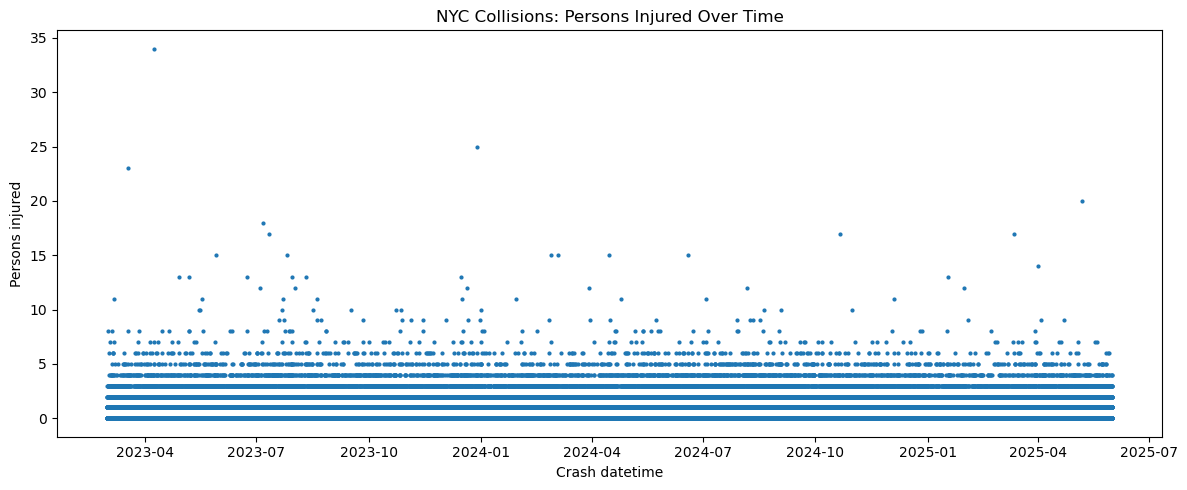

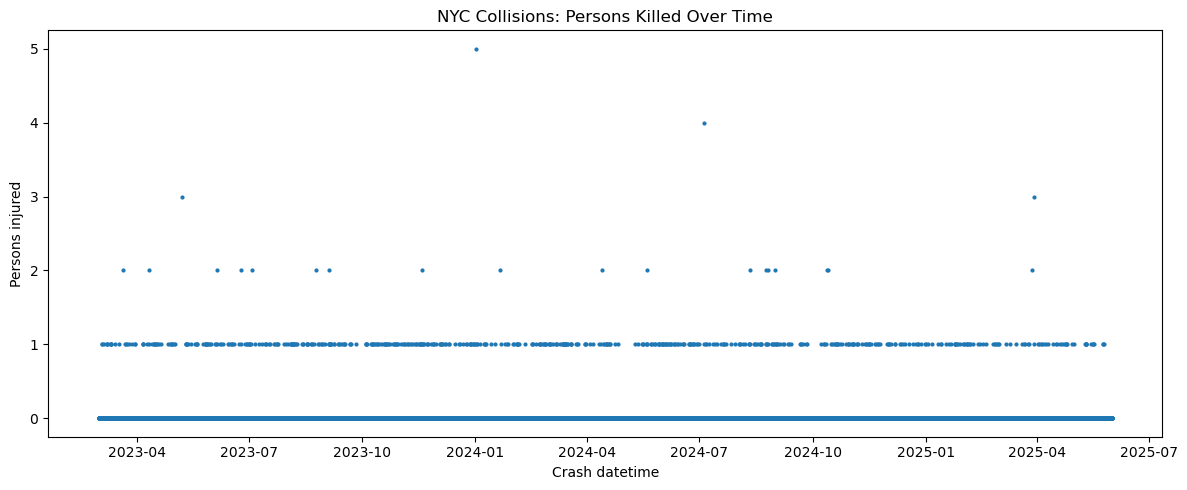

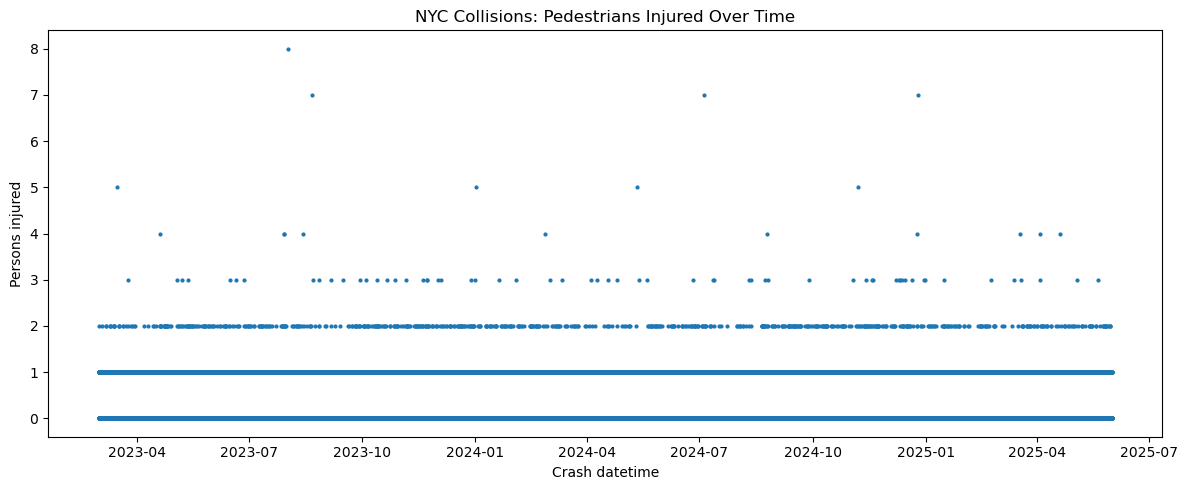

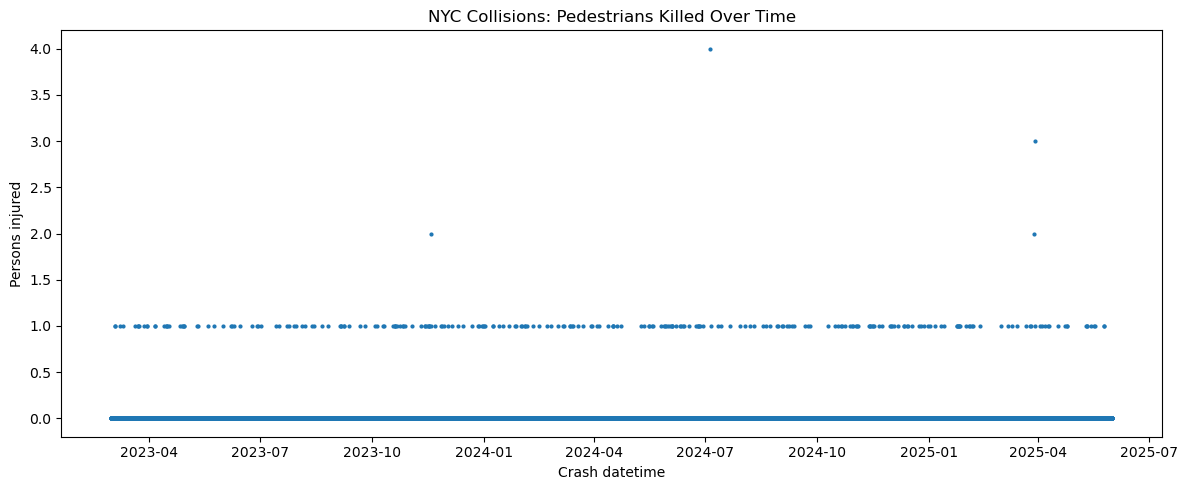

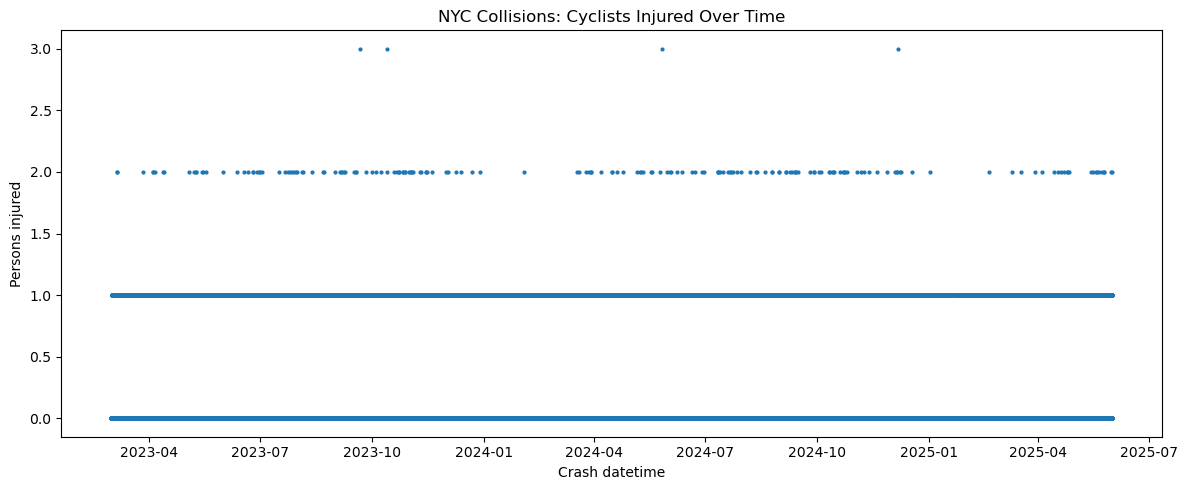

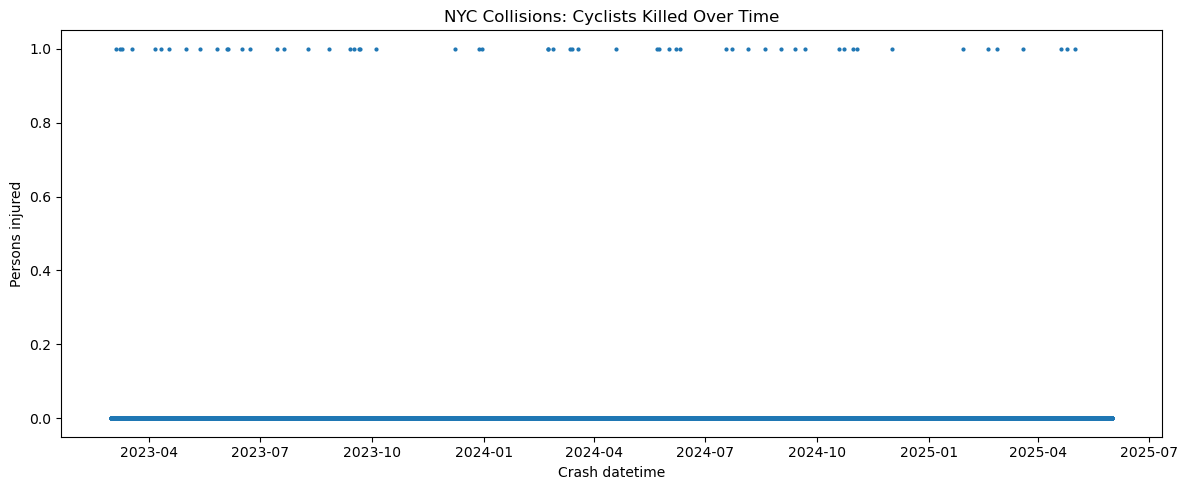

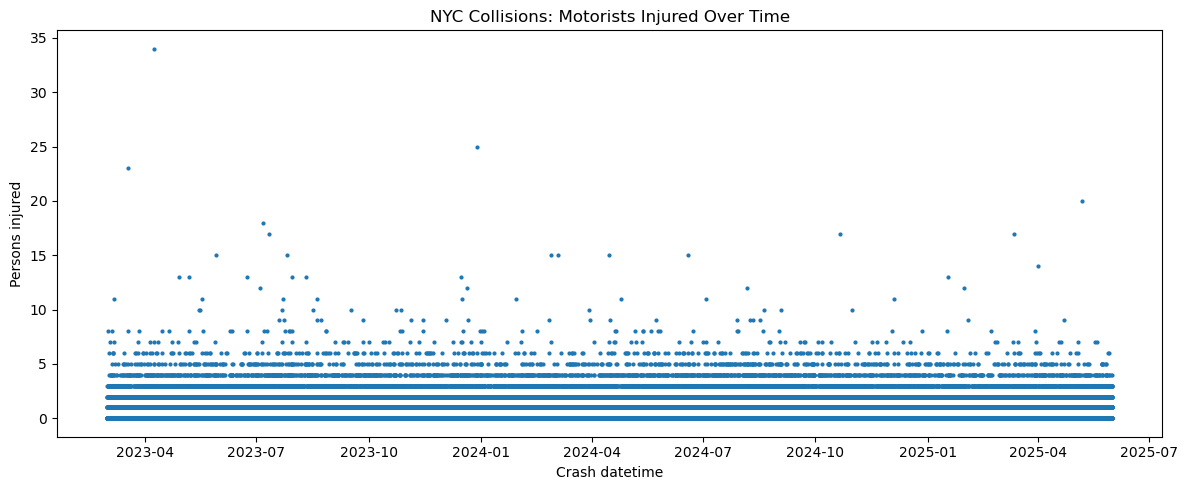

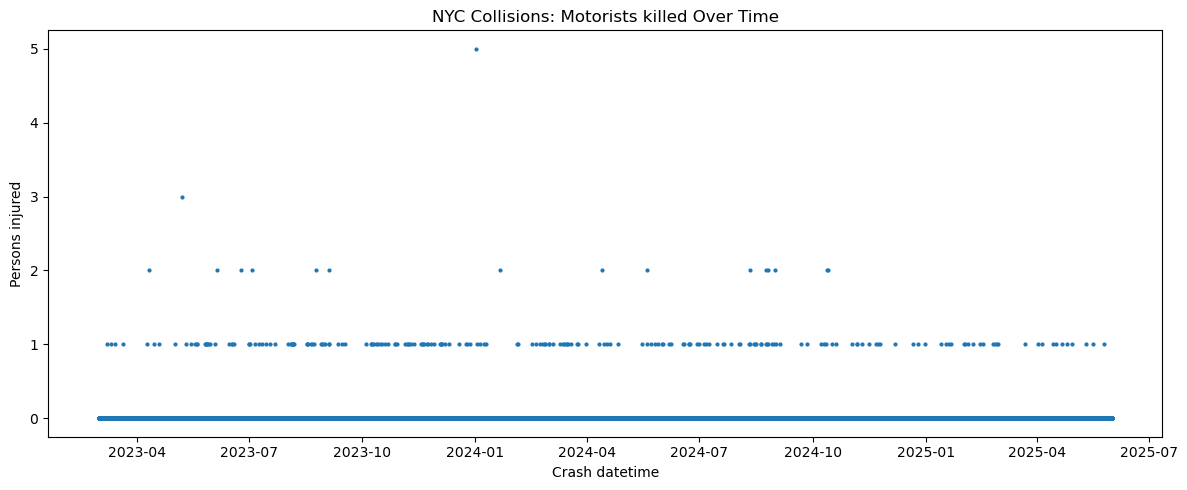

In [67]:
# =======================
#  Counting scheme(s)
#========================
# Copy collisions_df and compute total vehicles
crash_stochas_data = collisions_df.copy()
crash_stochas_data['total_incidents'] = (
    crash_stochas_data['number_of_motorist_injured'] +
    crash_stochas_data['number_of_motorist_killed'] +
    crash_stochas_data['number_of_pedestrians_injured'] +
    crash_stochas_data['number_of_pedestrians_killed'] +
    crash_stochas_data['number_of_cyclist_injured'] +
    crash_stochas_data['number_of_cyclist_killed']
)


# ===============================
# Quick plot examples
# ===============================
plt.figure(figsize=(12,5))
plt.plot(collisions_df['crash_datetime'], collisions_df['number_of_persons_injured'], 'o', markersize=2)
plt.xlabel("Crash datetime")
plt.ylabel("Persons injured")
plt.title("NYC Collisions: Persons Injured Over Time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(collisions_df['crash_datetime'], collisions_df['number_of_persons_killed'], 'o', markersize=2)
plt.xlabel("Crash datetime")
plt.ylabel("Persons injured")
plt.title("NYC Collisions: Persons Killed Over Time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(collisions_df['crash_datetime'], collisions_df['number_of_pedestrians_injured'], 'o', markersize=2)
plt.xlabel("Crash datetime")
plt.ylabel("Persons injured")
plt.title("NYC Collisions: Pedestrians Injured Over Time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(collisions_df['crash_datetime'], collisions_df['number_of_pedestrians_killed'], 'o', markersize=2)
plt.xlabel("Crash datetime")
plt.ylabel("Persons injured")
plt.title("NYC Collisions: Pedestrians Killed Over Time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(collisions_df['crash_datetime'], collisions_df['number_of_cyclist_injured'], 'o', markersize=2)
plt.xlabel("Crash datetime")
plt.ylabel("Persons injured")
plt.title("NYC Collisions: Cyclists Injured Over Time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(collisions_df['crash_datetime'], collisions_df['number_of_cyclist_killed'], 'o', markersize=2)
plt.xlabel("Crash datetime")
plt.ylabel("Persons injured")
plt.title("NYC Collisions: Cyclists Killed Over Time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(collisions_df['crash_datetime'], collisions_df['number_of_motorist_injured'], 'o', markersize=2)
plt.xlabel("Crash datetime")
plt.ylabel("Persons injured")
plt.title("NYC Collisions: Motorists Injured Over Time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(collisions_df['crash_datetime'], collisions_df['number_of_motorist_killed'], 'o', markersize=2)
plt.xlabel("Crash datetime")
plt.ylabel("Persons injured")
plt.title("NYC Collisions: Motorists killed Over Time")
plt.tight_layout()
plt.show()

**Intuitive Plots**

1. Distribution plots (histograms) for each column.

2. Share percentage plots (**the frowned upon** pie chart) to show relative impact.

3. Temporal dynamics for these event types across time (daily, weekly, hourly, or monthly).

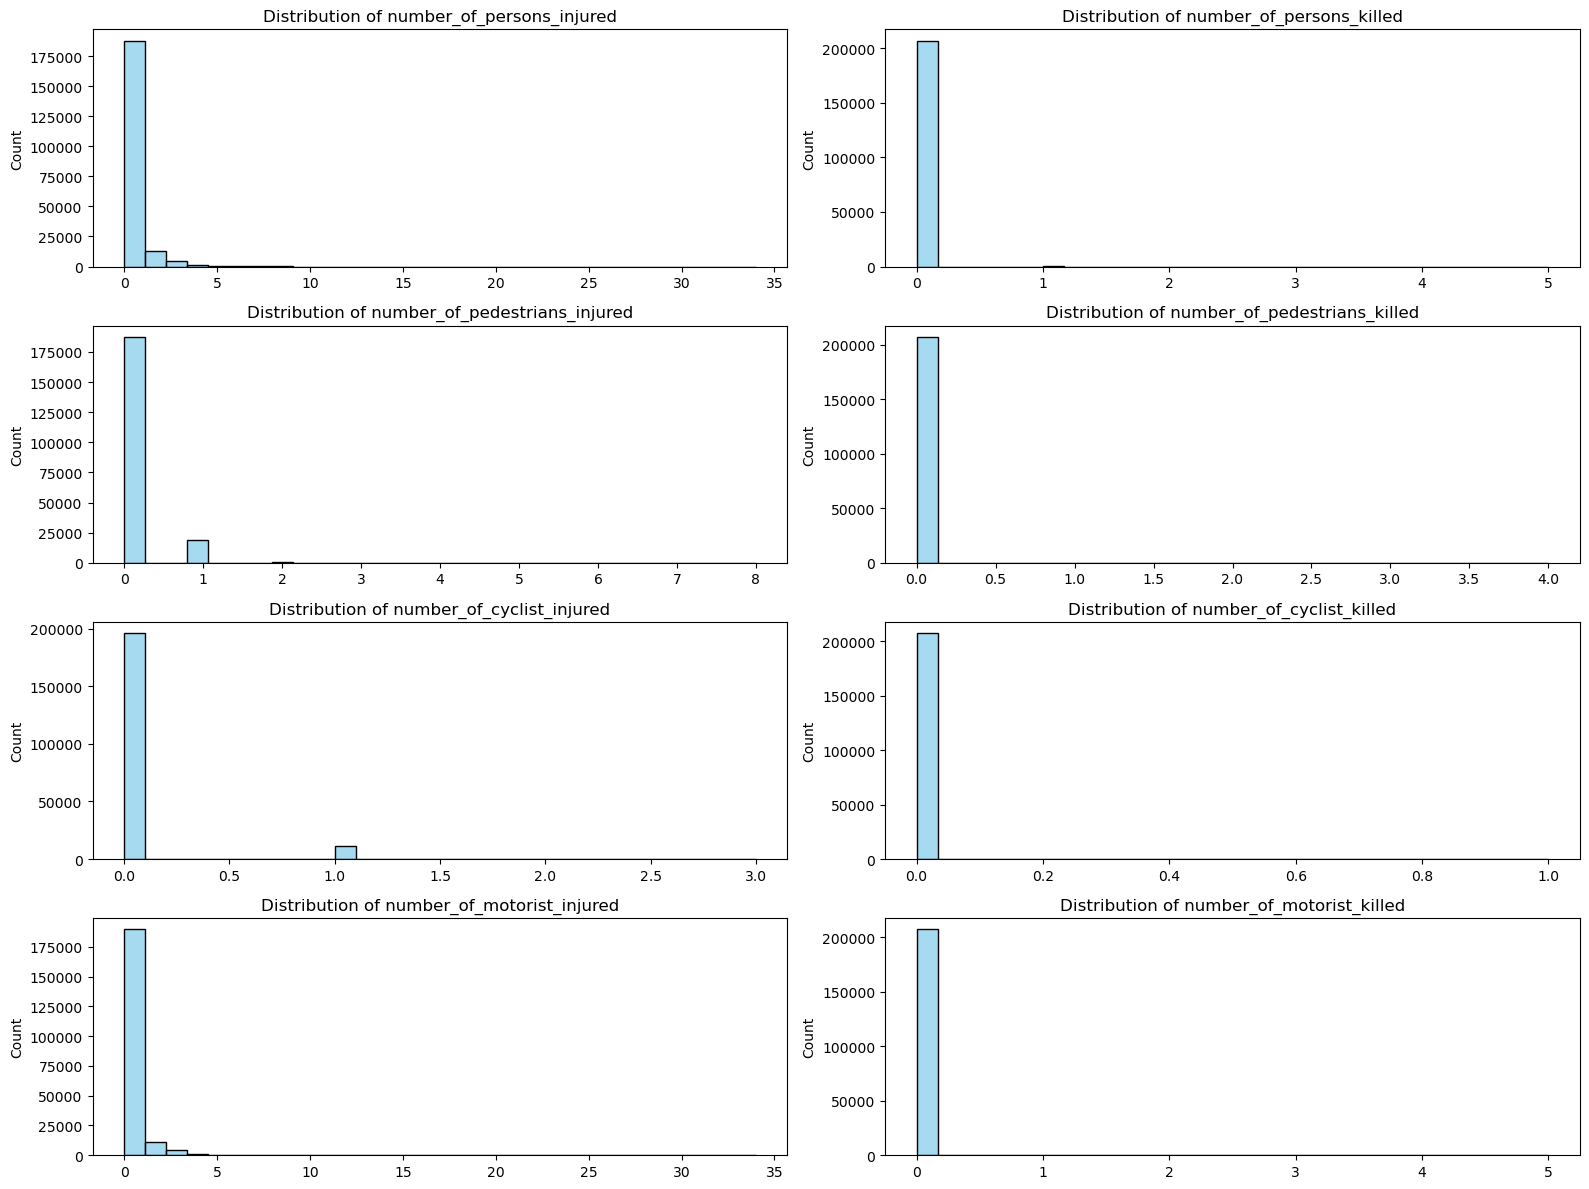

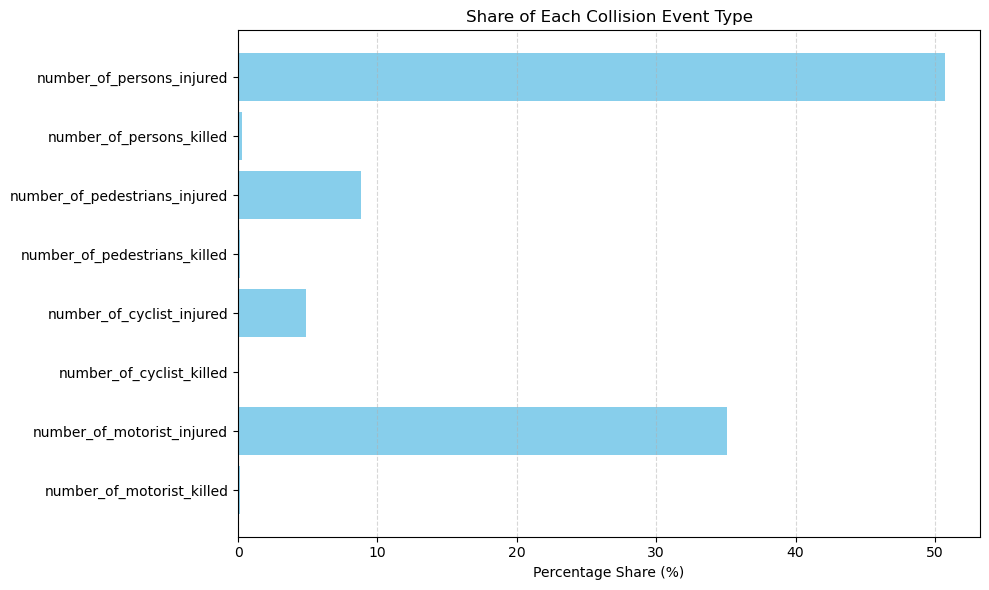

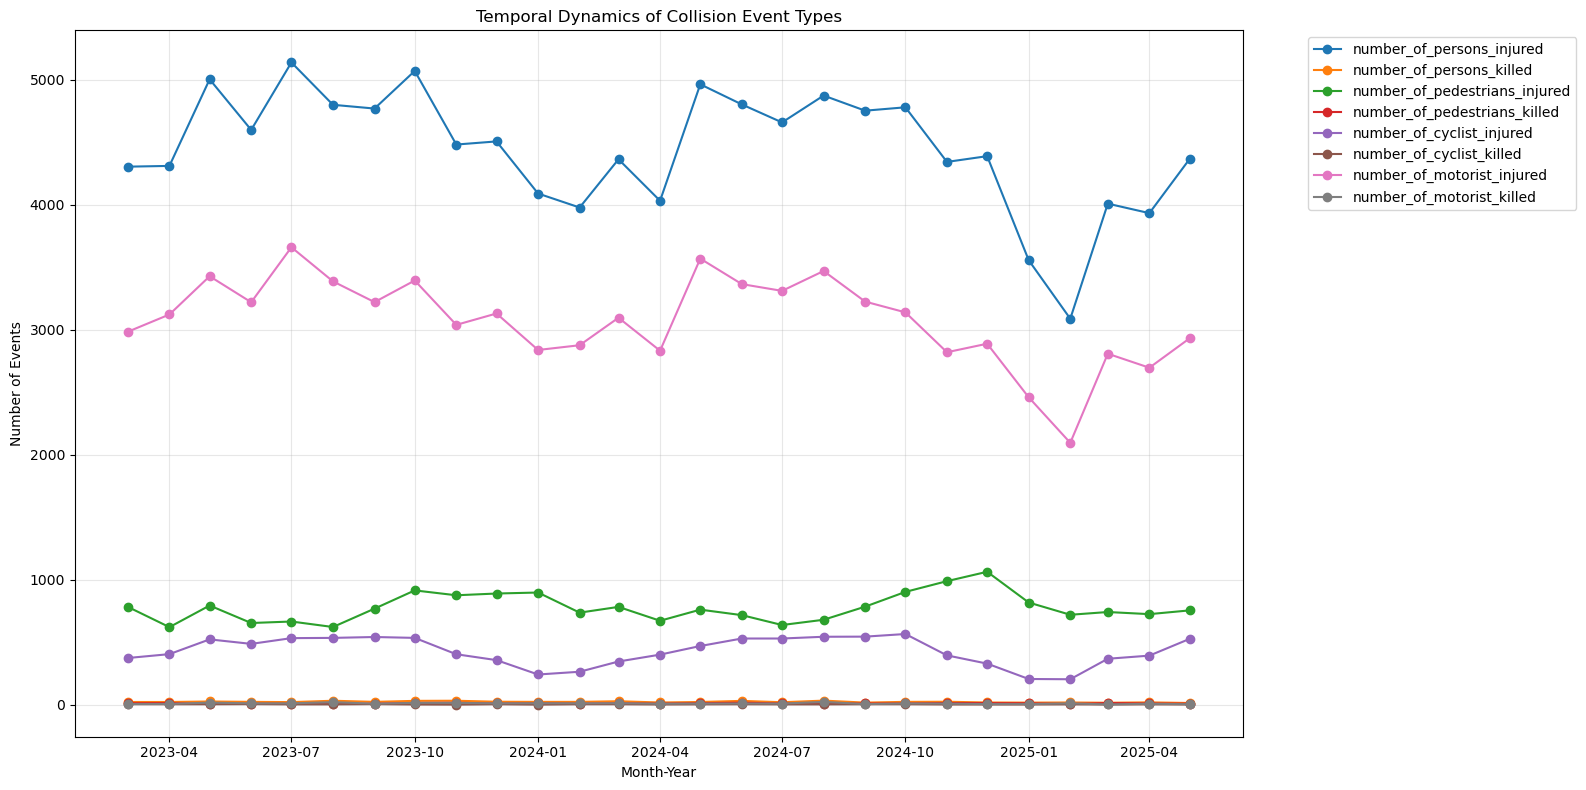

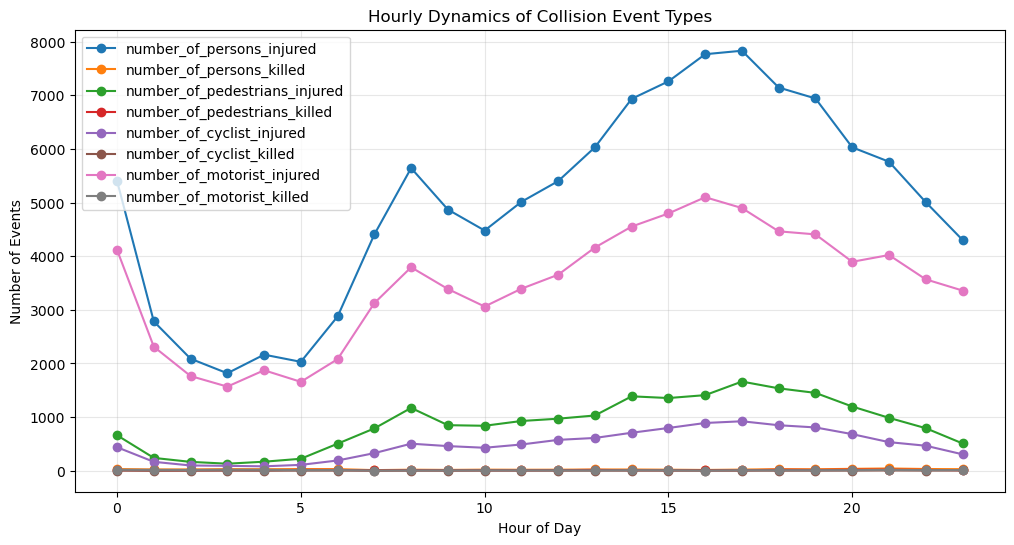

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Columns of interest: injury/killed counts
event_cols = [
    'number_of_persons_injured',
    'number_of_persons_killed',
    'number_of_pedestrians_injured',
    'number_of_pedestrians_killed',
    'number_of_cyclist_injured',
    'number_of_cyclist_killed',
    'number_of_motorist_injured',
    'number_of_motorist_killed'
]

# ==========================================
# Distribution plots for each column
# ==========================================
plt.figure(figsize=(16, 12))
for i, col in enumerate(event_cols, 1):
    plt.subplot(4, 2, i)
    sns.histplot(collisions_df[col], bins=30, kde=False, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ==========================================
# Share percentage plots (relative impact)
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd

# Prepare share data
share_percent = collisions_df[event_cols].sum() / collisions_df[event_cols].sum().sum() * 100

plt.figure(figsize=(10,6))
plt.barh(share_percent.index, share_percent.values, color='skyblue')
plt.xlabel('Percentage Share (%)')
plt.title('Share of Each Collision Event Type')
plt.gca().invert_yaxis()  # largest on top
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# Temporal dynamics (monthly) for all event types
# ==========================================
# Group by month-year
collisions_df['month_year'] = collisions_df['crash_datetime'].dt.to_period('M')
temporal_df = collisions_df.groupby('month_year')[event_cols].sum().reset_index()
temporal_df['month_year'] = temporal_df['month_year'].dt.to_timestamp()

plt.figure(figsize=(16,8))
for col in event_cols:
    plt.plot(temporal_df['month_year'], temporal_df[col], marker='o', label=col)

plt.xlabel('Month-Year')
plt.ylabel('Number of Events')
plt.title('Temporal Dynamics of Collision Event Types')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# Hourly temporal dynamic
# ==========================================
hourly_df = collisions_df.groupby('hour')[event_cols].sum()
hourly_df.plot(kind='line', figsize=(12,6), marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Events')
plt.title('Hourly Dynamics of Collision Event Types')
plt.grid(alpha=0.3)
plt.show()

### Stochstic Models for the Data (Negative Binomial)

In [69]:
import patsy
from statsmodels.discrete.discrete_model import NegativeBinomial


# Create time-of-day features
crash_stochas_data['hour'] = crash_stochas_data['crash_datetime'].dt.hour
crash_stochas_data['minute'] = crash_stochas_data['crash_datetime'].dt.minute

# Optional: bin crash_time into periods (e.g., 0-5, 6-11, 12-17, 18-23)
crash_stochas_data['time_period'] = pd.cut(
    crash_stochas_data['hour'],
    bins=[-1,5,11,17,23],
    labels=['Night','Morning','Afternoon','Evening']
)

# ===============================
# Design matrices for Negative Binomial
# ===============================
# Model total_vehicles as a function of hour or time_period
y, X = patsy.dmatrices(
    "total_incidents ~ C(time_period)",
    data=crash_stochas_data,
    return_type='dataframe'
)

# Fit Negative Binomial
nb_model_time = NegativeBinomial(y, X).fit()
print(nb_model_time.summary())

Optimization terminated successfully.
         Current function value: 1.004624
         Iterations: 7
         Function evaluations: 9
         Gradient evaluations: 9
                     NegativeBinomial Regression Results                      
Dep. Variable:        total_incidents   No. Observations:               207627
Model:               NegativeBinomial   Df Residuals:                   207623
Method:                           MLE   Df Model:                            3
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                0.001650
Time:                        17:27:04   Log-Likelihood:            -2.0859e+05
converged:                       True   LL-Null:                   -2.0893e+05
Covariance Type:            nonrobust   LLR p-value:                4.026e-149
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Interce

General Negative Binomial Scheme

In [70]:
# Negative Binomial regression with formula interface
nb_model = smf.glm(
    formula="total_incidents ~ C(time_period)",
    data=crash_stochas_data,
    family=sm.families.NegativeBinomial(alpha=0.3858) 
).fit() # it's likely if reducing value, Pseudo R-squ. improves

print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        total_incidents   No. Observations:               207627
Model:                            GLM   Df Residuals:                   207623
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.0859e+05
Date:                Thu, 12 Mar 2026   Deviance:                   1.9462e+05
Time:                        17:27:06   Pearson chi2:                 2.27e+05
No. Iterations:                     4   Pseudo R-squ. (CS):           0.003321
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

It's possible to model with granularity. An example:

In [71]:
# Model total_vehicles as a function of hour or time_period
y, X = patsy.dmatrices(
    "number_of_motorist_injured ~ C(time_period)",
    data=crash_stochas_data,
    return_type='dataframe'
)

# Fit Negative Binomial
nb_model_time = NegativeBinomial(y, X).fit()
print(nb_model_time.summary())

Optimization terminated successfully.
         Current function value: 0.830854
         Iterations: 5
         Function evaluations: 7
         Gradient evaluations: 7
                         NegativeBinomial Regression Results                          
Dep. Variable:     number_of_motorist_injured   No. Observations:               207627
Model:                       NegativeBinomial   Df Residuals:                   207623
Method:                                   MLE   Df Model:                            3
Date:                        Thu, 12 Mar 2026   Pseudo R-squ.:               0.0009746
Time:                                17:27:15   Log-Likelihood:            -1.7251e+05
converged:                               True   LL-Null:                   -1.7268e+05
Covariance Type:                    nonrobust   LLR p-value:                 1.205e-72
                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------

In [72]:
# Negative Binomial regression with formula interface
nb_model = smf.glm(
    formula="number_of_motorist_injured ~ C(time_period)",
    data=crash_stochas_data,
    family=sm.families.NegativeBinomial(alpha=1.7745) 
).fit() # it's likely if reducing value, Pseudo R-squ. improves

print(nb_model.summary())

                     Generalized Linear Model Regression Results                      
Dep. Variable:     number_of_motorist_injured   No. Observations:               207627
Model:                                    GLM   Df Residuals:                   207623
Model Family:                NegativeBinomial   Df Model:                            3
Link Function:                            Log   Scale:                          1.0000
Method:                                  IRLS   Log-Likelihood:            -1.7251e+05
Date:                        Thu, 12 Mar 2026   Deviance:                   1.4482e+05
Time:                                17:27:17   Pearson chi2:                 2.16e+05
No. Iterations:                             6   Pseudo R-squ. (CS):           0.001622
Covariance Type:                    nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

From the models' results the graphical exhibitions reveal much about the randomness of occurences. 

### Clustering Exhibition

#### Mini-Batch K-Means Clustering Overview

**Mini-Batch K-Means** (Pedregosa, 2011) is a variation of the standard K-Means algorithm designed to reduce the computational cost of clustering on large datasets by using random subsets (mini-batches) of data.

**The Core Objective:**

While the objective remains the minimization of inertia, the algorithm updates the centroids $M$ iteratively using a subset of the data $b \subset X$ in each step:

$$J_{batch} = \sum_{x \in b} \| x - \mu_{c(x)} \|^2$$

Where $c(x)$ is the index of the closest centroid to point $x$.

**The Algorithm Steps:**

1. Initialization: Select $k$ initial centroids $\mu_1, \dots, \mu_k$ (often using k-means++).

2. Sampling: Extract a random mini-batch $b$ of size $m$ from the dataset.

3. Assignment: For each $x \in b$, find the nearest centroid:

$$i = \text{argmin}_{j} \| x - \mu_j \|^2$$

4. Update: For each point $x$ in the batch, update its assigned centroid using a per-center count $v_i$ (the number of points assigned to center $i$ so far):

$$\eta = \frac{1}{v_i}$$

$$\mu_i \leftarrow (1 - \eta)\mu_i + \eta x$$

5. Repeat: Continue until convergence or a maximum number of iterations is reached.

Organising the data structure to meet needs:

In [73]:
from sklearn.cluster import KMeans
import pandas as pd

# Filter only rows where incidents occurred
incident_cols = [
    'number_of_persons_injured',
    'number_of_persons_killed',
    'number_of_pedestrians_injured',
    'number_of_pedestrians_killed',
    'number_of_cyclist_injured',
    'number_of_cyclist_killed',
    'number_of_motorist_injured',
    'number_of_motorist_killed'
]

df_clusters = crash_stochas_data[['latitude', 'longitude'] + incident_cols].copy()
df_melted = df_clusters.melt(
    id_vars=['latitude', 'longitude'], 
    value_vars=incident_cols, 
    var_name='incident_type', 
    value_name='count'
)

# Keep only incidents > 0
df_melted = df_melted[df_melted['count'] > 0]
df_melted.reset_index(drop=True, inplace=True)

df_melted = df_melted.dropna()
df_melted.head(20)

,latitude,longitude,incident_type,count
0,40.624990,-74.144030,number_of_persons_injured,1
1,40.746080,-73.974945,number_of_persons_injured,2
3,40.728474,-73.882614,number_of_persons_injured,1
5,40.814266,-73.912964,number_of_persons_injured,1
6,40.828114,-73.931070,number_of_persons_injured,3
7,40.707220,-73.789570,number_of_persons_injured,1
9,40.718052,-73.920715,number_of_persons_injured,1
10,40.742160,-73.804436,number_of_persons_injured,1
11,40.640015,-73.925750,number_of_persons_injured,1
12,40.582977,-73.980420,number_of_persons_injured,1


Determining optimal clusters using Elbow + Silhouette:

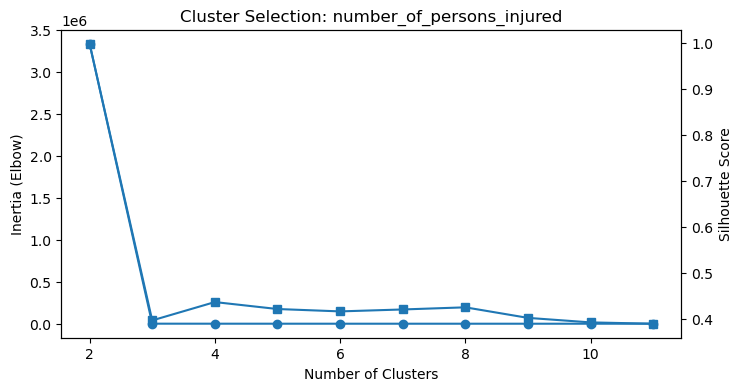

number_of_persons_injured optimal clusters = 2


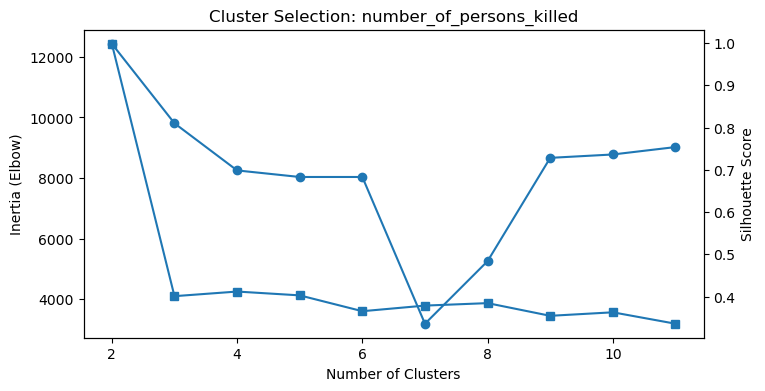

number_of_persons_killed optimal clusters = 2


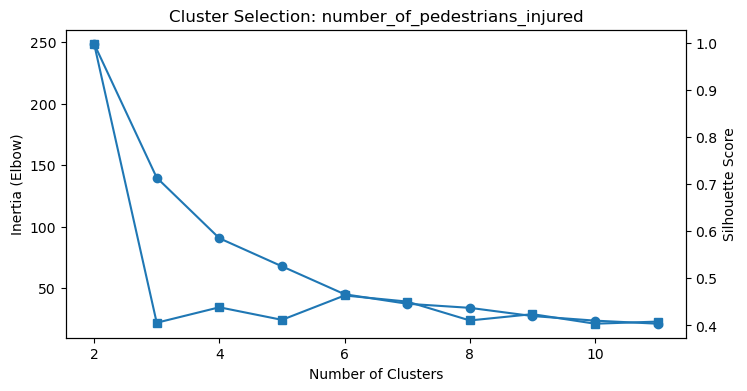

number_of_pedestrians_injured optimal clusters = 2


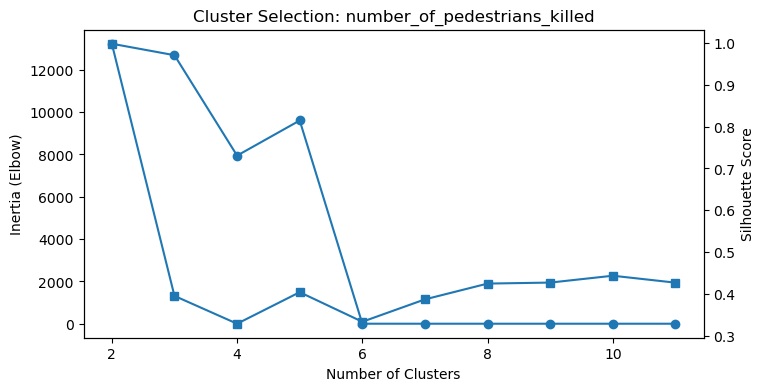

number_of_pedestrians_killed optimal clusters = 2


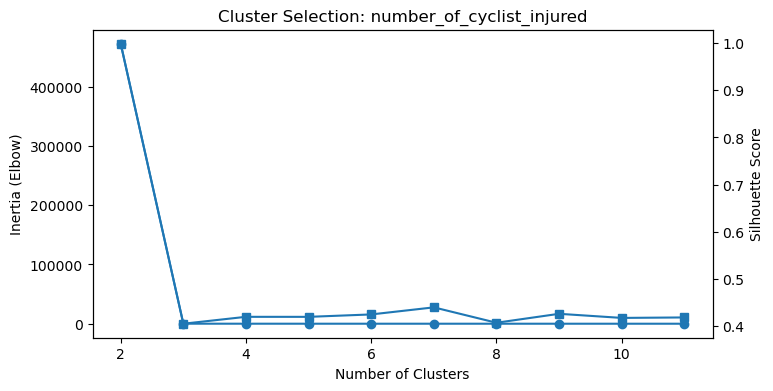

number_of_cyclist_injured optimal clusters = 2


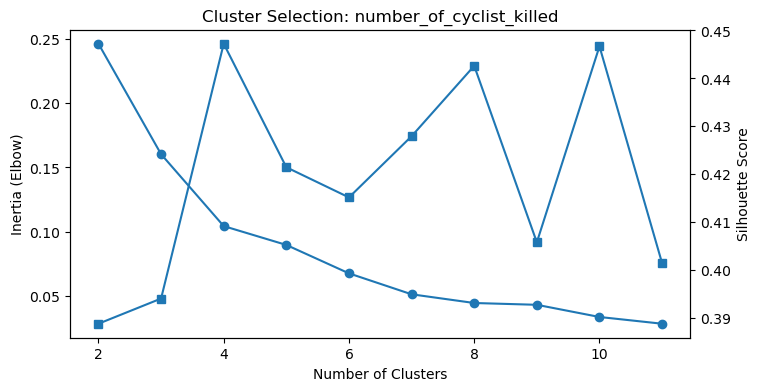

number_of_cyclist_killed optimal clusters = 4


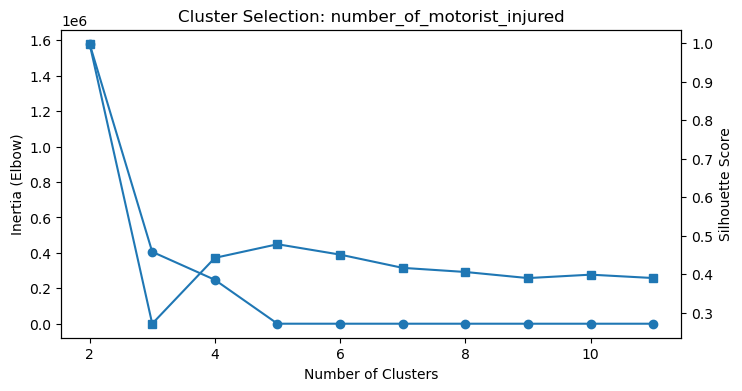

number_of_motorist_injured optimal clusters = 2


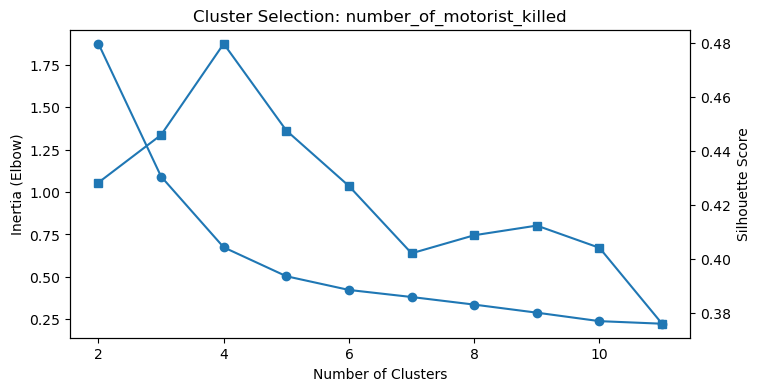

number_of_motorist_killed optimal clusters = 4


In [74]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

incident_types = df_melted['incident_type'].unique()

optimal_clusters = {}

for incident in incident_types:
    
    group = df_melted[df_melted['incident_type'] == incident]
    coords = group[['latitude','longitude']].dropna().values
    
    distortions = []
    silhouettes = []
    
    K = range(2,12)

    for k in K:

        model = MiniBatchKMeans(
            n_clusters=k,
            batch_size=10000,
            random_state=42
        )

        labels = model.fit_predict(coords)

        distortions.append(model.inertia_)

        silhouettes.append(
            silhouette_score(coords, labels, sample_size=10000)
        )

    # Plot elbow + silhouette
    fig, ax1 = plt.subplots(figsize=(8,4))

    ax1.plot(K, distortions, marker='o')
    ax1.set_xlabel("Number of Clusters")
    ax1.set_ylabel("Inertia (Elbow)")

    ax2 = ax1.twinx()
    ax2.plot(K, silhouettes, marker='s')
    ax2.set_ylabel("Silhouette Score")

    plt.title(f"Cluster Selection: {incident}")
    plt.show()

    best_k = K[np.argmax(silhouettes)]
    optimal_clusters[incident] = best_k

    print(f"{incident} optimal clusters = {best_k}")

Fitting Mini-Bach KMeans with the optimal cluster numbers for models:

In [75]:
clustered_results = []

for incident, k in optimal_clusters.items():

    group = df_melted[df_melted['incident_type'] == incident]

    coords = group[['latitude','longitude']].dropna().values

    model = MiniBatchKMeans(
        n_clusters=k,
        batch_size=10000,
        random_state=42
    )

    labels = model.fit_predict(coords)

    group = group.copy()
    group['cluster'] = labels

    centers = model.cluster_centers_

    group['center_lat'] = [centers[i][0] for i in labels]
    group['center_lon'] = [centers[i][1] for i in labels]

    clustered_results.append(group)

df_clustered = pd.concat(clustered_results)

 **Exhibition with Folium**

Key stability improvements:

1. Adaptive sampling

2. Max ~8000 points per layer

3. Cluster centers added separately

Acquiring an interactive crash-cluster map where:

1. Different incident types are color-coded

2. Optimal clusters are chosen automatically

3. Cluster centers show crash hotspots

4. Map loads without crashing the browser

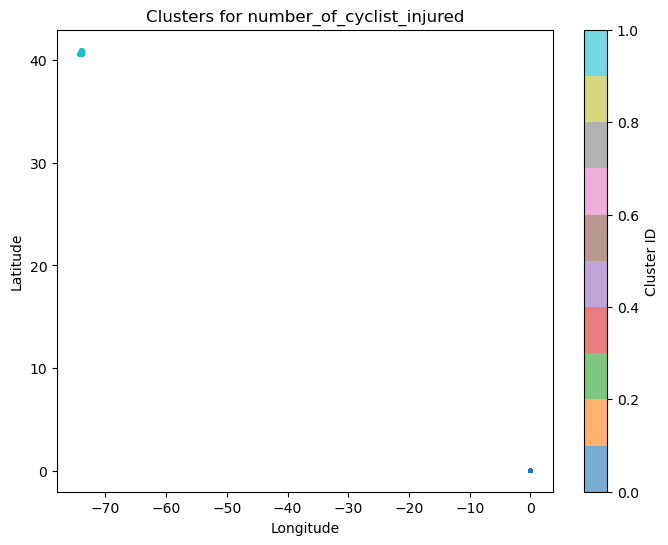

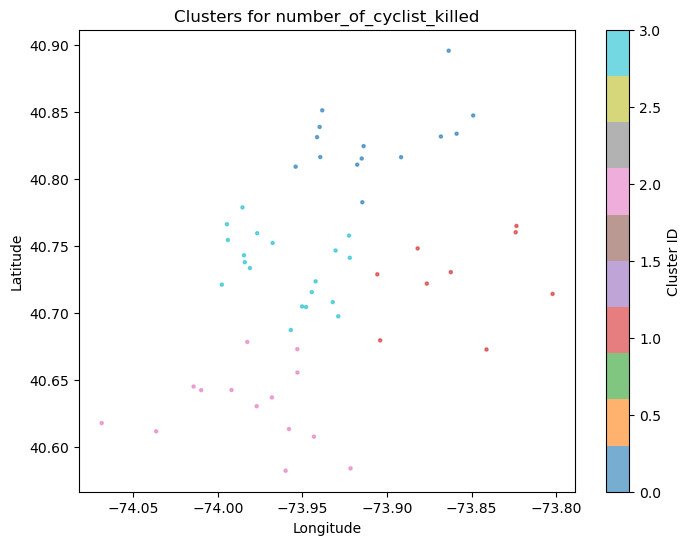

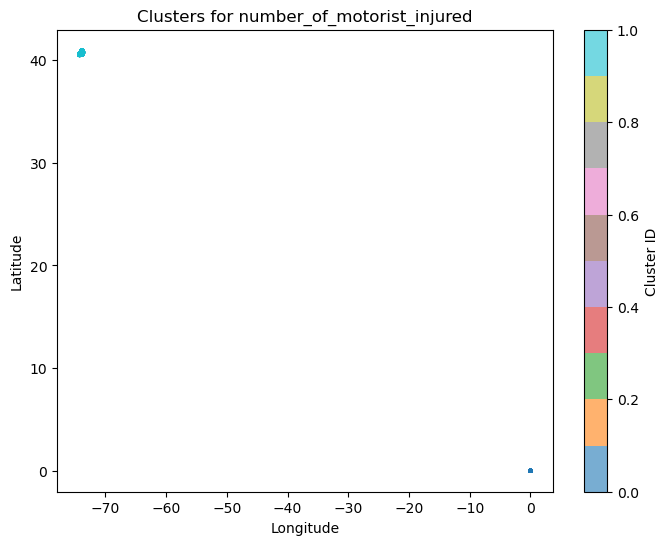

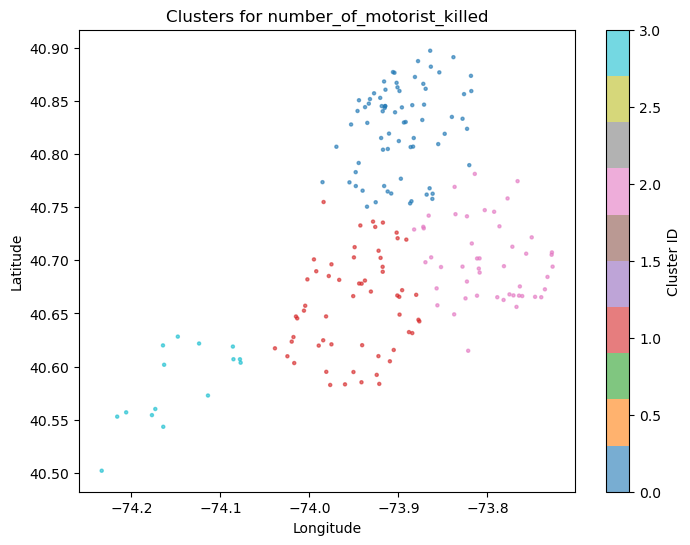

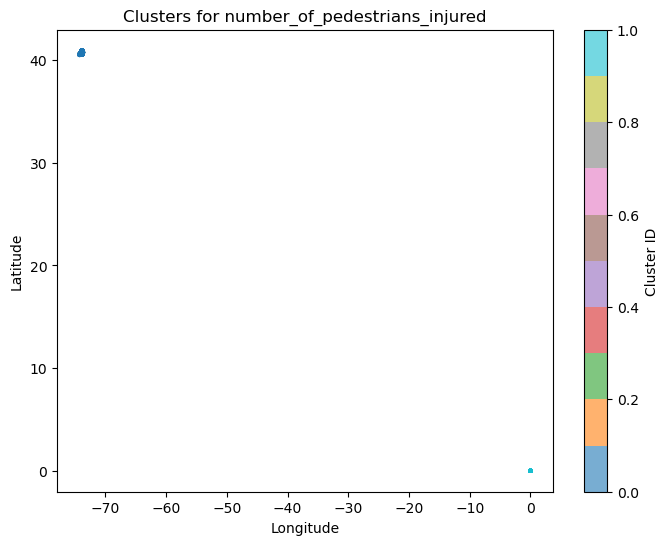

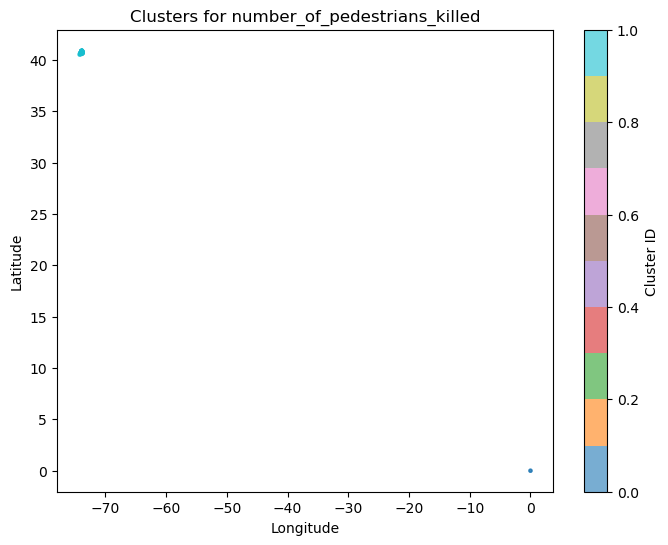

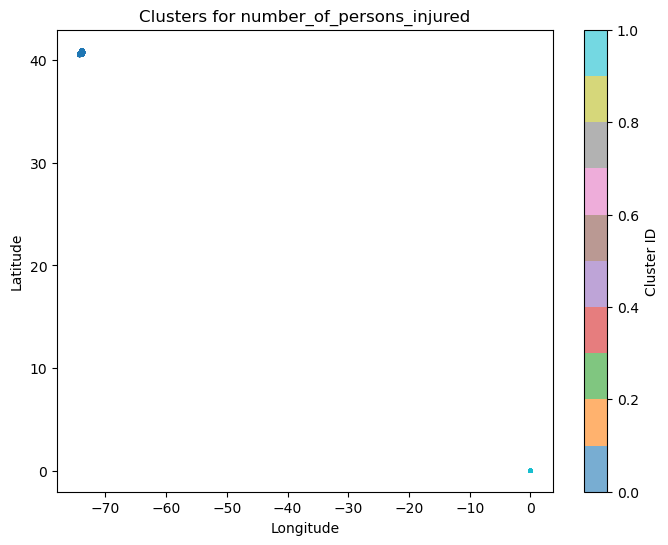

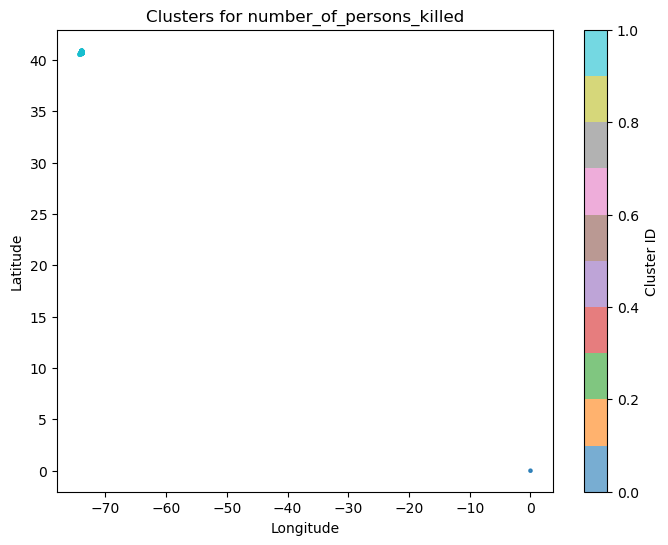

In [76]:
import folium
from folium.plugins import MarkerCluster

for incident, group in df_clustered.groupby('incident_type'):

    plt.figure(figsize=(8,6))

    plt.scatter(
        group['longitude'],
        group['latitude'],
        c=group['cluster'],
        cmap='tab10',
        s=5,
        alpha=0.6
    )


    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    plt.title(f"Clusters for {incident}")

    plt.colorbar(label="Cluster ID")

    plt.show()

## Trying to Relate Vehicle Collision - Crashes to Traffic Anomalies 

A collision **doesn't necessarily trigger an anomaly at the exact same timestamp**. In traffic systems there is usually a **temporal** lag before the system registers abnormal traffic behaviour (congestion buildup, shockwaves, rerouting, etc.).

So **rather than** exact date matching, to implement a **time window matching approach**.

To be concerned with only **future traffic anomalies** for matching to make sense. Namely, a 'causal' structure pursuit. 

......YET KEEP IN MIND THAT VEHICLE COLLISIONS ARE NOT THE ONLY ACCIDENTS......

.......YET KEEP IN MIND THAT VEHICLE FAILURES ARE NOT CONSIDERED ACCIDENTS, CAN BE CULPRITS.....WHERE DATA FOR SUCH CAN BE ELUSIVE.......

Total collisions: 207627
Collisions triggering anomalies: 1062
Share: 0.005114941698334032
count    1062.000000
mean       34.847458
std        18.278846
min         1.000000
25%        20.000000
50%        35.000000
75%        51.000000
max        60.000000
Name: anomaly_lag_minutes, dtype: float64


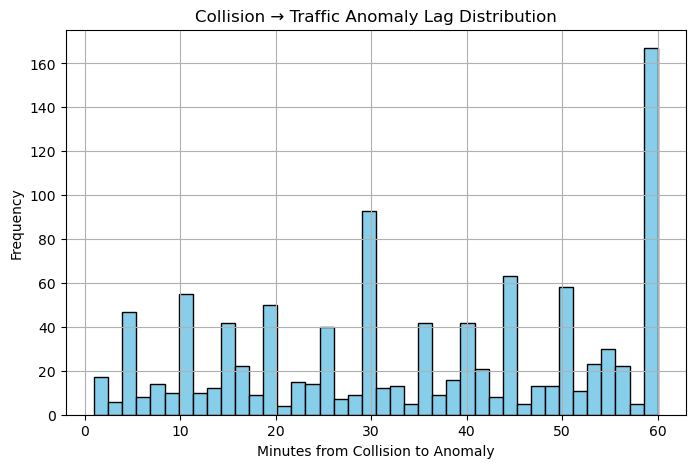

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1️⃣ Ensure datetime formats
# ==========================================
facility_df['date'] = pd.to_datetime(facility_df['date'])
collisions_df['crash_datetime'] = pd.to_datetime(collisions_df['crash_datetime'])

# ==========================================
# 2️⃣ Extract future anomaly timestamps
# ==========================================
anomaly_times = np.array(
    sorted(facility_df.loc[facility_df['anomaly'] == True, 'date'])
)

# ==========================================
# 3️⃣ Prepare collisions dataset
# ==========================================
collisions_df = collisions_df.sort_values('crash_datetime')
collisions_df['collision_event'] = 1  # explicit flag

# ==========================================
# 4️⃣ Define maximum future window
# ==========================================
window = pd.Timedelta("60min")

# ==========================================
# 5️⃣ Function to find next future anomaly within window
# ==========================================
def get_next_anomaly(crash_time, window=window):
    # future anomalies only
    future_anoms = anomaly_times[anomaly_times > crash_time]
    if len(future_anoms) == 0:
        return pd.NaT
    next_anom = future_anoms[0]
    if next_anom - crash_time <= window:
        return next_anom
    return pd.NaT

# ==========================================
# 6️⃣ Apply function to collisions
# ==========================================
collisions_df['anomaly_time'] = collisions_df['crash_datetime'].apply(get_next_anomaly)
collisions_df['collision_triggered_anomaly'] = collisions_df['anomaly_time'].notna().astype(int)
collisions_df['anomaly_lag_minutes'] = (
    (collisions_df['anomaly_time'] - collisions_df['crash_datetime']).dt.total_seconds() / 60
)

# ==========================================
# 7️⃣ Summary statistics
# ==========================================
total_collisions = len(collisions_df)
matches = collisions_df['collision_triggered_anomaly'].sum()

print("Total collisions:", total_collisions)
print("Collisions triggering anomalies:", matches)
print("Share:", matches / total_collisions)

# ==========================================
# 8️⃣ Lag distribution & plot
# ==========================================
lag_dist = collisions_df.loc[
    collisions_df['collision_triggered_anomaly'] == 1,
    'anomaly_lag_minutes'
]

print(lag_dist.describe())

plt.figure(figsize=(8,5))
lag_dist.hist(bins=40, color='skyblue', edgecolor='black')
plt.xlabel("Minutes from Collision to Anomaly")
plt.ylabel("Frequency")
plt.title("Collision → Traffic Anomaly Lag Distribution")
plt.show()

**Observations from the lag distribution:**

Total collisions: 207,627

Collisions triggering anomalies: 1,062 (~ 0.51%)

Lag statistics (minutes from collision to anomaly):

    Mean: ~ 35 min

    Median: 35 min

    25th percentile: 20 min

    75th percentile: 51 min

    Max: 60 min (matches your window)

Interpretation:

1. Only a small fraction of collisions (~ 0.51%) are associated with measurable traffic anomalies.

2. When anomalies occur, the typical lag is ~20–51 minutes, with an average around 35 minutes.

3. The histogram shows a right-skewed distribution, with spikes near 30–60 minutes — suggesting some collisions trigger delayed effects on traffic (e.g., secondary congestion downstream).

**Insights:**

Future anomalies matter:

    Focusing on future traffic anomalies ensures causal interpretation: collisions precede congestion or abnormal traffic flow.

Temporal windows:

    Most impactful collisions cause anomalies 20–50 minutes afterward. This can inform traffic management response windows.

Low overall share:

    Only ~ 0.51% of collisions trigger measurable anomalies — suggests that most collisions are minor or quickly absorbed by the network.

Lag pattern spikes:

    Peaks around 30–35 and 60 minutes may correspond to specific locations, congestion-prone corridors, or peak-hour interactions.

**NOTE:** this development only concerns facility 30.

<h2>Conclusion</h2>

<p>
This study provides a comprehensive analysis of urban traffic dynamics across New York City's major bridges and tunnels, leveraging the <strong>MTA Bridges & Tunnels Hourly Traffic Rates dataset</strong> along with supplemental motor vehicle collision and weather data. By integrating stochastic modelling, statistical analysis, and machine learning approaches, we have characterised traffic arrival patterns, identified temporal and spatial congestion trends, and highlighted the probabilistic structure of urban vehicle flows.
</p>

<h3>Key Findings</h3>
<ul>
    <li>Traffic arrivals exhibit clear stochastic patterns, which can be effectively modelled using Negative Binomial and Markov processes, capturing both variability and over-dispersion in vehicle counts.</li>
    <li>Strong daily, weekly, and seasonal cycles are evident in the data, with predictable peaks during morning and evening commutes and variations across weekdays and weekends.</li>
    <li>Machine learning-based anomaly detection successfully identified unusual traffic events, often linked to collisions, extreme weather, or infrastructure disruptions, allowing quantification of their temporal impact on traffic flows.</li>
    <li>Spatial analysis revealed differences in congestion intensity across toll facilities and directions, providing actionable insight into which bridges or tunnels experience higher traffic volatility and concentration.</li>
</ul>

<h3>Implications for Policy and Planning</h3>
<p>
These results demonstrate that integrating multiple analytical perspectives — stochastic, statistical, and machine learning — provides a robust framework for understanding urban mobility. The methodology allows policymakers and transportation authorities to:
</p>
<ul>
    <li>Forecast congestion and plan for peak traffic periods more effectively.</li>
    <li>Evaluate the impact of incidents or policy interventions on traffic flows in near real-time.</li>
    <li>Support data-driven decisions regarding toll management, congestion pricing, and infrastructure investments.</li>
</ul>

<p>
Overall, the study highlights the value of high-resolution traffic data in combination with collision and environmental information for building predictive and explanatory models of metropolitan transportation systems. The approach and findings from this research can inform both operational traffic management and long-term urban transportation planning, ultimately contributing to more efficient, resilient, and safe urban mobility networks.
</p>

## References

Free weather API. Open. (n.d.). https://open-meteo.com/ 

Hirschman, A. O. (1945). National Power and the Structure of Foreign Trade. *University of California Press*.

Metropolitan Transit Authority. Catalog. State of New York. (n.d.). MTA Bridges & Tunnels Hourly Traffic Rates: 2010 - 2025
https://data.ny.gov/Transportation/MTA-Bridges-Tunnels-Hourly-Traffic-Rates-2010-2025/qzve-kjga/about_data 

New York City Police Department. (2026, March 11). Motor Vehicle Collisions - Crashes: NYC Open Data. Motor Vehicle Collisions - Crashes | NYC Open Data. https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/about_data 

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825-2830.

Rabiner, L. R. (1989). A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition. *Proceedings of the IEEE*, 77(2), 257–286. doi.org

Ross, S. (2012). A First in Probability. *Pearson*, 480 pages

Ross, S. (2019). Introduction to Probability Models. *Academic Press*

Vetter, E. (2023, November 6). When is Veterans Day 2023 Observed? What to Know About the Federal Holiday Honouring Vets. *USA Today*. https://www.usatoday.com/story/news/nation/2023/11/06/when-is-veterans-day-2023/71476053007/ 
